### <span style = "color:orange">1. Introduction<span>

#### <span style="color:green">1.1. Project purpose</span>

Xây dựng và đánh giá tập hợp các mô hình dự báo chuỗi thời gian để dự đoán nhiệt độ cực đại hàng ngày tại các khu vực đô thị và ven biển Việt Nam. Dự án áp dụng cả thuật toán Machine Learning truyền thống và Deep Learning hiện đại nhằm cải thiện độ chính xác dự báo so với các phương pháp thống kê thông thường.

<b>Nguồn dữ liệu</b>: Bộ dữ liệu ERA5 (ECMWF) với các bản ghi nhiệt độ từ 1990 đến 2024, được xử lý và biến đổi để huấn luyện các mô hình như Random Forest, XGBoost, LSTM, Transformer, TFT, và N-BEATS.

<b>Kết quả</b>: Đánh giá hiệu năng giữa các mô hình qua nhiều kịch bản thực nghiệm và đề xuất hệ thống cảnh báo nhiệt độ sớm ứng dụng thực tế.

#### <span style="color:green">1.2. Data source and description</span>

<h4>Thông tin dữ liệu trong đề tài:</h4>

<ul>
<li><b>Thời gian thu thập:</b> từ năm <b>1990 đến 2024</b></li>
<li><b>Định dạng ban đầu:</b> .grib, sau đó chuyển đổi sang .csv để xử lý</li>
</ul>

<h4>Các biến số chính trong tập dữ liệu:</h4>

<table>
<thead>
<tr>
<th>Tên cột dữ liệu</th>
<th>Ý nghĩa</th>
<th>Đơn vị đo</th>
</tr>
</thead>
<tbody>
<tr><td><code>NAME</code></td><td>Tên tỉnh/thành phố nơi thu thập dữ liệu</td><td>-</td></tr>
<tr><td><code>LATITUDE</code></td><td>Vĩ độ địa lý của điểm đo</td><td>Độ</td></tr>
<tr><td><code>LONGITUDE</code></td><td>Kinh độ địa lý của điểm đo</td><td>Độ</td></tr>
<tr><td><code>YMD</code></td><td>Ngày/tháng/năm đo đạc</td><td>dd/mm/yyyy</td></tr>
<tr><td><code>YEAR</code></td><td>Năm đo đạc</td><td>Năm</td></tr>
<tr><td><code>MONTH</code></td><td>Tháng đo đạc</td><td>Tháng</td></tr>
<tr><td><code>DAY</code></td><td>Ngày đo đạc</td><td>Ngày</td></tr>
<tr><td><code>TEMP_max</code></td><td>Nhiệt độ không khí cực đại trong ngày</td><td>°C</td></tr>
<tr><td><code>TEMP_ave</code></td><td>Nhiệt độ trung bình trong ngày</td><td>°C</td></tr>
<tr><td><code>DEW_ave</code></td><td>Điểm sương trung bình trong ngày</td><td>°C</td></tr>
<tr><td><code>DEW_max</code></td><td>Điểm sương cao nhất trong ngày</td><td>°C</td></tr>
<tr><td><code>RH_ave</code></td><td>Độ ẩm tương đối trung bình trong ngày</td><td>%</td></tr>
<tr><td><code>RH_max</code></td><td>Độ ẩm tương đối cực đại trong ngày</td><td>%</td></tr>
<tr><td><code>AT_ave</code></td><td>Nhiệt độ cảm nhận trung bình trong ngày (Apparent Temp.)</td><td>°C</td></tr>
<tr><td><code>AT_max</code></td><td>Nhiệt độ cảm nhận cao nhất trong ngày</td><td>°C</td></tr>
<tr><td><code>SP_ave</code></td><td>Áp suất bề mặt trung bình trong ngày (Surface Pressure)</td><td>hPa</td></tr>
<tr><td><code>TCC_avg</code></td><td>Lượng mây che phủ trung bình trong ngày (Total Cloud Cover)</td><td>%</td></tr>
<tr><td><code>TP_sum</code></td><td>Lượng mưa tích lũy trong ngày (Total Precipitation)</td><td>mm</td></tr>
<tr><td><code>WIND_speed_avg</code></td><td>Tốc độ gió trung bình trong ngày</td><td>m/s</td></tr>
<tr><td><code>WIND_direction_deg_avg</code></td><td>Hướng gió trung bình trong ngày</td><td>Độ (0°–360°)</td></tr>
</tbody>
</table>


<p><b>Biến mục tiêu chính:</b></p>
<ul>
<li><code>TEMP_max</code> — Nhiệt độ không khí cực đại hàng ngày (°C)</li>
</ul>

<p><b>Lưu ý:</b> Dữ liệu gốc của ERA5 có thể chứa giá trị thiếu, giá trị ngoại lai và một số dị bản khí tượng đặc thù. Do đó, quá trình làm sạch dữ liệu, xử lý giá trị thiếu, phát hiện ngoại lệ và chuẩn hóa dữ liệu là các bước bắt buộc trước khi tiến hành huấn luyện và dự báo.</p>

In [1]:
match_type = {
    'NAME'       : 'Categorical',  # Tên tỉnh/thành phố (chuỗi)
    'LATITUDE'   : 'Numerical',    # Vĩ độ (°)
    'LONGITUDE'  : 'Numerical',    # Kinh độ (°)
    'YMD'        : 'Datetime',     # Ngày/tháng/năm (dd/mm/yyyy)
    'YEAR'       : 'Numerical',    # Năm (năm)
    'MONTH'      : 'Numerical',    # Tháng (1-12)
    'DAY'        : 'Numerical',    # Ngày (1-31)

    'TEMP_max'   : 'Numerical',    # Nhiệt độ cực đại trong ngày (°C)
    'TEMP_ave'   : 'Numerical',    # Nhiệt độ trung bình trong ngày (°C)
    'DEW_ave'    : 'Numerical',    # Điểm sương trung bình trong ngày (°C)
    'DEW_max'    : 'Numerical',    # Điểm sương cực đại trong ngày (°C)
    'RH_ave'     : 'Numerical',    # Độ ẩm tương đối trung bình trong ngày (%)
    'RH_max'     : 'Numerical',    # Độ ẩm tương đối cực đại trong ngày (%)
    'AT_ave'     : 'Numerical',    # Nhiệt độ cảm nhận trung bình trong ngày (°C)
    'AT_max'     : 'Numerical',    # Nhiệt độ cảm nhận cực đại trong ngày (°C)

    'SP_ave'              : 'Numerical',  # Áp suất bề mặt trung bình trong ngày (kPa)
    'TCC_avg'             : 'Numerical',  # Lượng mây che phủ trung bình trong ngày (%)
    'TP_sum'              : 'Numerical',  # Lượng mưa tích lũy trong ngày (mm)
    'WIND_speed_avg'      : 'Numerical',  # Tốc độ gió trung bình trong ngày (m/s)
    'WIND_direction_deg_avg' : 'Numerical'  # Hướng gió trung bình trong ngày (0°–360°)
}

#### <span style="color:green">1.3. Goals</span>

<img src="../../image/Ảnh chụp màn hình 2025-06-24 210616.png">

### <span style="color:orange">2. Import Libraries</span>

#### <span style="color:green">2.1. Configuration and display settings</span>

In [2]:
import sys
sys.path.append("../../")  # đường dẫn đến thư mục chứa src

from src.utilities import(config, 
                          dataset, 
                          features, 
                          plots)

from src.models import(anomaly_models,
                       forecasting_models,
                       model_utils)

from scripts import(evaluate_model,
                    run_forecast,
                    train_model)

In [3]:
PROJ_SEED  = config.getSeed()
model_path = "../../models/trained_models/ML/XGBOOST/"

#### <span style="color:green">2.2. Required Python packages</span>

In [4]:
import numpy             as np
import pandas            as pd
import matplotlib.pyplot as plt
import seaborn           as sns
import os

from copy import deepcopy

from sklearn.preprocessing import OneHotEncoder  # Encode feature
from sklearn.preprocessing import OrdinalEncoder # Encode feature
from sklearn.preprocessing import MinMaxScaler   # Scale feature
from sklearn.preprocessing import StandardScaler # Scale feature
from sklearn.preprocessing import LabelEncoder   # Encode target
# from scipy.stats import boxcox # Normalized feature

# from sklearn.feature_selection import mutual_info_classif # PCA
from sklearn.model_selection   import train_test_split
from sklearn.model_selection   import RepeatedKFold
from sklearn.model_selection   import GridSearchCV
from sklearn.model_selection   import validation_curve
from sklearn.model_selection   import learning_curve
from sklearn.model_selection   import TimeSeriesSplit


from sklearn.ensemble     import RandomForestRegressor
import xgboost
from xgboost              import XGBRegressor

# %pip install tensorflow
import tensorflow as tf
from tensorflow                 import keras
from tensorflow.keras           import layers
from tensorflow.keras.callbacks import EarlyStopping

import joblib
import random
import shap


# Classification
# from sklearn.metrics import accuracy_score
# from sklearn.metrics import matthews_corrcoef
# from sklearn.metrics import confusion_matrix
# from sklearn.metrics import roc_auc_score
# from sklearn.metrics import roc_curve
# from sklearn.metrics import classification_report

# Regression
from sklearn.metrics import r2_score
from sklearn.metrics import mean_absolute_error
from sklearn.metrics import mean_squared_error
from sklearn.metrics import mean_squared_log_error
from sklearn.metrics import mean_absolute_percentage_error
# from sklearn.metrics import median_absolute_error
# from sklearn.metrics import max_error
# from sklearn.metrics import PredictionErrorDisplay

from sklearn.inspection import permutation_importance
from sklearn.tree import plot_tree

f:\NCKH\.venv\lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


### <span style="color:orange">3. Data Loading</span>

In [5]:
src = dict({"CaMau" : "../../data/processed/datasets/CaMau_90.24_cleaned.csv",
            "DH"    : "../../data/processed/datasets/DH_90.24_cleaned.csv",
            "NB"    : "../../data/processed/datasets/NB_90.24_cleaned.csv",
            "QN"    : "../../data/processed/datasets/QN_90.24_cleaned.csv",
            "TH"    : "../../data/processed/datasets/TH_90.24_cleaned.csv",
            "TSN"   : "../../data/processed/datasets/TSN_90.24_cleaned.csv"})

src_name = dict({"CaMau" : "CA MAU",
                 "DH"    : "DONG HOI",
                 "NB"    : "NOI BAI",
                 "QN"    : "QUY NHON",
                 "TH"    : "THANH HOA",
                 "TSN"   : "TSN"})

#### <span style="color:green">3.1. Loading the dataset</span>

In [6]:
nrows = None # None -> Not provided -> All

In [7]:
station = dict()

for name, link in src.items():
    station[name] = pd.read_csv(filepath_or_buffer = link,
                                nrows              = nrows,
                                parse_dates        = True,
                                index_col= 'time'
                                )

In [8]:
df = station["CaMau"]

for name in list(station.keys())[1:]:
    df = pd.concat([df, station[name]])

In [9]:
df["NAME"].value_counts()

NAME
CA MAU       12785
DONG HOI     12785
NOI BAI      12785
QUY NHON     12785
THANH HOA    12785
TSN          12785
Name: count, dtype: int64

#### <span style="color:green">3.2. Displaying first few rows</span>

In [10]:
df.head()

,NAME,LATITUDE,LONGITUDE,DEW_ave,TEMP_ave,RH_ave,AT_ave,DEW_max,TEMP_max,RH_max,AT_max,sp_ave,tcc_ave,tp_sum,wind_speed_ave,wind_direction_deg_ave
time,,,,,,,,,,,,,,,,
1990-01-01,CA MAU,9.183333,105.15,21.76,24.46,85.71,28.91,22.2,28.3,92.95,32.42,101.080992,0.963329,6.691313e-04,3.038102,81.611026
1990-01-02,CA MAU,9.183333,105.15,21.76,24.46,85.71,28.91,22.2,28.3,92.95,32.42,101.126695,0.717658,1.756653e-05,3.751254,95.887684
1990-01-03,CA MAU,9.183333,105.15,21.53,23.78,87.31,28.07,21.7,24.9,91.82,29.30,101.225232,0.105999,2.860647e-07,4.373832,91.720210
1990-01-04,CA MAU,9.183333,105.15,20.90,23.68,84.61,27.57,21.5,25.3,91.27,29.57,101.261555,0.692104,3.038970e-04,4.438863,83.439938
1990-01-05,CA MAU,9.183333,105.15,22.16,25.70,81.55,30.41,23.0,29.0,94.68,33.25,101.322520,0.721015,0.000000e+00,2.595582,83.001394


In [11]:
df.tail()

,NAME,LATITUDE,LONGITUDE,DEW_ave,TEMP_ave,RH_ave,AT_ave,DEW_max,TEMP_max,RH_max,AT_max,sp_ave,tcc_ave,tp_sum,wind_speed_ave,wind_direction_deg_ave
time,,,,,,,,,,,,,,,,
2024-12-28,TSN,10.818797,106.651856,22.791667,26.916667,79.162100,32.084942,25.0,32.0,100.000000,37.9678,101.179802,0.788628,1.011907e-02,1.527386,0.314178
2024-12-29,TSN,10.818797,106.651856,20.208333,27.000000,67.583448,30.462463,23.0,32.0,83.550261,35.2750,101.129503,0.672280,5.340588e-07,1.527386,0.314178
2024-12-30,TSN,10.818797,106.651856,22.041667,27.437500,73.500435,32.082450,24.0,32.0,94.185344,35.9023,101.111917,0.544640,8.584292e-06,1.527386,0.314178
2024-12-31,TSN,10.818797,106.651856,21.291667,27.479167,69.556134,31.638729,24.0,31.0,88.748236,36.2547,101.011929,0.817102,2.140334e-05,1.527386,0.314178
2025-01-01,TSN,10.818797,106.651856,21.291667,27.479167,69.556134,31.638729,24.0,31.0,88.748236,36.2547,100.902162,1.000000,5.722939e-07,1.527386,0.314178


#### <span style="color:green">3.3. Data summary</span>

In [12]:
for name in station.keys():
    print(f"🔸 Trạm: {name}")
    print(df.shape)
    print()

🔸 Trạm: CaMau
(76710, 16)

🔸 Trạm: DH
(76710, 16)

🔸 Trạm: NB
(76710, 16)

🔸 Trạm: QN
(76710, 16)

🔸 Trạm: TH
(76710, 16)

🔸 Trạm: TSN
(76710, 16)



In [13]:
for name in station.keys():
    print(f"🔸 Trạm: {name}")
    print(df.info())

🔸 Trạm: CaMau
<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 76710 entries, 1990-01-01 to 2025-01-01
Data columns (total 16 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   NAME                    76710 non-null  object 
 1   LATITUDE                76710 non-null  float64
 2   LONGITUDE               76710 non-null  float64
 3   DEW_ave                 76710 non-null  float64
 4   TEMP_ave                76710 non-null  float64
 5   RH_ave                  76710 non-null  float64
 6   AT_ave                  76710 non-null  float64
 7   DEW_max                 76710 non-null  float64
 8   TEMP_max                76710 non-null  float64
 9   RH_max                  76710 non-null  float64
 10  AT_max                  76710 non-null  float64
 11  sp_ave                  76710 non-null  float64
 12  tcc_ave                 76710 non-null  float64
 13  tp_sum                  76710 non-null  float64
 14  wind_sp

In [14]:
for name in station.keys():
    print(f"🔸 Trạm: {name}")
    print(df.describe())

🔸 Trạm: CaMau
           LATITUDE     LONGITUDE       DEW_ave      TEMP_ave        RH_ave  \
count  76710.000000  76710.000000  76710.000000  76710.000000  76710.000000   
mean      15.370498    106.534839     22.178763     26.131471     80.239653   
std        4.461804      1.305265      3.912276      4.058455      9.135566   
min        9.183333    105.150000      1.087500      7.050000     27.350000   
25%       10.818797    105.783333     20.810000     24.450000     74.780000   
50%       15.624833    106.203589     23.510000     27.117261     81.208640   
75%       19.750000    106.651856     24.762500     28.800000     86.966203   
max       21.221192    109.216667     28.700000     36.320000    107.330000   

             AT_ave       DEW_max      TEMP_max        RH_max        AT_max  \
count  76710.000000  76710.000000  76710.000000  76710.000000  76710.000000   
mean      31.098408     23.535639     29.382039     92.278782     34.387730   
std        6.090245      3.779538    

### <span style="color:orange">4. Data Preparation</span>

In [15]:
for name in station.keys():
    print(f"🔸 Trạm: {name}")
    print(df.columns)
    print()

🔸 Trạm: CaMau
Index(['NAME', 'LATITUDE', 'LONGITUDE', 'DEW_ave', 'TEMP_ave', 'RH_ave',
       'AT_ave', 'DEW_max', 'TEMP_max', 'RH_max', 'AT_max', 'sp_ave',
       'tcc_ave', 'tp_sum', 'wind_speed_ave', 'wind_direction_deg_ave'],
      dtype='object')

🔸 Trạm: DH
Index(['NAME', 'LATITUDE', 'LONGITUDE', 'DEW_ave', 'TEMP_ave', 'RH_ave',
       'AT_ave', 'DEW_max', 'TEMP_max', 'RH_max', 'AT_max', 'sp_ave',
       'tcc_ave', 'tp_sum', 'wind_speed_ave', 'wind_direction_deg_ave'],
      dtype='object')

🔸 Trạm: NB
Index(['NAME', 'LATITUDE', 'LONGITUDE', 'DEW_ave', 'TEMP_ave', 'RH_ave',
       'AT_ave', 'DEW_max', 'TEMP_max', 'RH_max', 'AT_max', 'sp_ave',
       'tcc_ave', 'tp_sum', 'wind_speed_ave', 'wind_direction_deg_ave'],
      dtype='object')

🔸 Trạm: QN
Index(['NAME', 'LATITUDE', 'LONGITUDE', 'DEW_ave', 'TEMP_ave', 'RH_ave',
       'AT_ave', 'DEW_max', 'TEMP_max', 'RH_max', 'AT_max', 'sp_ave',
       'tcc_ave', 'tp_sum', 'wind_speed_ave', 'wind_direction_deg_ave'],
      dtype='object'

In [16]:
lower_bound = pd.to_datetime("1990-01-01 00:00:00")
upper_bound = pd.to_datetime("2024-12-31 00:00:00")
# WINDOW_SIZE = 7
# HORIZON     = 1

In [17]:
lower_bound, upper_bound

(Timestamp('1990-01-01 00:00:00'), Timestamp('2024-12-31 00:00:00'))

#### <span style="color:green">4.1. Feature Selection</span>

##### <span style="color:tomato">Train/Validation/Test</span>

Theo thứ tự thời gian (không shuffle <~> shuffle tăng dần)

In [18]:
df = df.sort_index()
df

,NAME,LATITUDE,LONGITUDE,DEW_ave,TEMP_ave,RH_ave,AT_ave,DEW_max,TEMP_max,RH_max,AT_max,sp_ave,tcc_ave,tp_sum,wind_speed_ave,wind_direction_deg_ave
time,,,,,,,,,,,,,,,,
1990-01-01,CA MAU,9.183333,105.150000,21.760000,24.460000,85.710000,28.910000,22.2,28.3,92.950000,32.420000,101.080992,0.963329,6.691313e-04,3.038102,81.611026
1990-01-01,QUY NHON,13.766667,109.216667,20.920000,23.800000,84.435950,27.706273,21.4,27.3,92.279648,31.230500,99.714036,0.400093,4.253905e-04,2.383495,164.361671
1990-01-01,DONG HOI,17.483000,106.600000,18.750000,20.280000,90.940000,22.890000,19.5,21.3,94.570000,24.040000,100.064575,0.796282,5.114702e-04,1.422625,158.100468
1990-01-01,THANH HOA,19.750000,105.783333,20.400000,22.000000,90.641837,25.582248,20.4,22.0,90.641837,25.582248,101.251524,0.999033,4.567676e-04,2.537301,174.652701
1990-01-01,TSN,10.818797,106.651856,21.175758,27.027273,71.463133,31.087169,23.0,32.0,88.507803,35.566200,100.972871,0.499631,3.357503e-05,1.601291,150.244327
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2025-01-01,QUY NHON,13.766667,109.216667,17.212500,22.025000,74.352567,23.792805,19.4,22.2,85.713112,24.873908,99.766187,0.999439,3.674245e-03,7.170556,351.018326
2025-01-01,DONG HOI,17.483000,106.600000,17.630000,19.180000,90.930000,21.180000,19.3,22.0,97.520000,24.340000,100.474205,0.838605,6.550445e-05,4.215039,338.014567
2025-01-01,CA MAU,9.183333,105.150000,24.200000,27.010000,85.080000,33.190000,26.2,29.6,95.950000,35.580000,101.012573,0.997857,2.136861e-06,2.361484,347.759965


In [19]:
df = df.loc[(df.index>=lower_bound) & (df.index<=upper_bound)]
targets  = df[['NAME','TEMP_max']]
features = df.drop(columns=['TEMP_max'])

In [20]:
# for i in range(WINDOW_SIZE):
#     features[f"{targets.name}_{i+1}"] = targets.shift(periods=i+1)
# features = features.dropna().drop(targets.name,axis=1)
features

,NAME,LATITUDE,LONGITUDE,DEW_ave,TEMP_ave,RH_ave,AT_ave,DEW_max,RH_max,AT_max,sp_ave,tcc_ave,tp_sum,wind_speed_ave,wind_direction_deg_ave
time,,,,,,,,,,,,,,,
1990-01-01,CA MAU,9.183333,105.150000,21.760000,24.460000,85.710000,28.910000,22.2,92.950000,32.420000,101.080992,0.963329,0.000669,3.038102,81.611026
1990-01-01,QUY NHON,13.766667,109.216667,20.920000,23.800000,84.435950,27.706273,21.4,92.279648,31.230500,99.714036,0.400093,0.000425,2.383495,164.361671
1990-01-01,DONG HOI,17.483000,106.600000,18.750000,20.280000,90.940000,22.890000,19.5,94.570000,24.040000,100.064575,0.796282,0.000511,1.422625,158.100468
1990-01-01,THANH HOA,19.750000,105.783333,20.400000,22.000000,90.641837,25.582248,20.4,90.641837,25.582248,101.251524,0.999033,0.000457,2.537301,174.652701
1990-01-01,TSN,10.818797,106.651856,21.175758,27.027273,71.463133,31.087169,23.0,88.507803,35.566200,100.972871,0.499631,0.000034,1.601291,150.244327
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2024-12-31,NOI BAI,21.221192,105.807178,11.620000,16.640000,74.290000,15.990000,14.0,100.000000,20.230000,101.780498,0.607103,0.000068,2.114598,178.763194
2024-12-31,TSN,10.818797,106.651856,21.291667,27.479167,69.556134,31.638729,24.0,88.748236,36.254700,101.011929,0.817102,0.000021,1.527386,0.314178
2024-12-31,CA MAU,9.183333,105.150000,24.200000,27.010000,85.080000,33.190000,26.2,95.950000,35.580000,101.134755,0.988316,0.000016,1.709888,323.390110


In [21]:
# targets = df.loc[features.index][['NAME','TEMP_max']] # DUPLICATE INDEX
targets

,NAME,TEMP_max
time,,
1990-01-01,CA MAU,28.3
1990-01-01,QUY NHON,27.3
1990-01-01,DONG HOI,21.3
1990-01-01,THANH HOA,22.0
1990-01-01,TSN,32.0
...,...,...
2024-12-31,NOI BAI,21.0
2024-12-31,TSN,31.0
2024-12-31,CA MAU,29.6


In [22]:
# Aproach1
# le = LabelEncoder()
# targets_encoded = le.fit_transform(targets)


# # Aproach2
# targets_encoded = targets_encoded.replace({'e': 0, 'p': 1})

# # Aproach3
targets_encoded = targets.replace({'e': 0, 'p': 1})

In [23]:
# # y_train
targets

,NAME,TEMP_max
time,,
1990-01-01,CA MAU,28.3
1990-01-01,QUY NHON,27.3
1990-01-01,DONG HOI,21.3
1990-01-01,THANH HOA,22.0
1990-01-01,TSN,32.0
...,...,...
2024-12-31,NOI BAI,21.0
2024-12-31,TSN,31.0
2024-12-31,CA MAU,29.6


In [24]:
targets_encoded

,NAME,TEMP_max
time,,
1990-01-01,CA MAU,28.3
1990-01-01,QUY NHON,27.3
1990-01-01,DONG HOI,21.3
1990-01-01,THANH HOA,22.0
1990-01-01,TSN,32.0
...,...,...
2024-12-31,NOI BAI,21.0
2024-12-31,TSN,31.0
2024-12-31,CA MAU,29.6


#### <span style="color:green">4.2. Dimensionality Reducing</span>

In [25]:
features.columns

Index(['NAME', 'LATITUDE', 'LONGITUDE', 'DEW_ave', 'TEMP_ave', 'RH_ave',
       'AT_ave', 'DEW_max', 'RH_max', 'AT_max', 'sp_ave', 'tcc_ave', 'tp_sum',
       'wind_speed_ave', 'wind_direction_deg_ave'],
      dtype='object')

In [26]:
feature_col = list(['DEW_ave', 'TEMP_ave', 'RH_ave', 'AT_ave', 'DEW_max', 'RH_max', 'AT_max', 
                    'sp_ave', 'tcc_ave', 'tp_sum','wind_speed_ave', 'wind_direction_deg_ave',
                    # 'TEMP_max_1', 'TEMP_max_2', 'TEMP_max_3', 'TEMP_max_4', 'TEMP_max_5', 'TEMP_max_6', 'TEMP_max_7'
                    ])

##### <span style="color:tomato">MI (Mutual Information)</span>

In [27]:
features

,NAME,LATITUDE,LONGITUDE,DEW_ave,TEMP_ave,RH_ave,AT_ave,DEW_max,RH_max,AT_max,sp_ave,tcc_ave,tp_sum,wind_speed_ave,wind_direction_deg_ave
time,,,,,,,,,,,,,,,
1990-01-01,CA MAU,9.183333,105.150000,21.760000,24.460000,85.710000,28.910000,22.2,92.950000,32.420000,101.080992,0.963329,0.000669,3.038102,81.611026
1990-01-01,QUY NHON,13.766667,109.216667,20.920000,23.800000,84.435950,27.706273,21.4,92.279648,31.230500,99.714036,0.400093,0.000425,2.383495,164.361671
1990-01-01,DONG HOI,17.483000,106.600000,18.750000,20.280000,90.940000,22.890000,19.5,94.570000,24.040000,100.064575,0.796282,0.000511,1.422625,158.100468
1990-01-01,THANH HOA,19.750000,105.783333,20.400000,22.000000,90.641837,25.582248,20.4,90.641837,25.582248,101.251524,0.999033,0.000457,2.537301,174.652701
1990-01-01,TSN,10.818797,106.651856,21.175758,27.027273,71.463133,31.087169,23.0,88.507803,35.566200,100.972871,0.499631,0.000034,1.601291,150.244327
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2024-12-31,NOI BAI,21.221192,105.807178,11.620000,16.640000,74.290000,15.990000,14.0,100.000000,20.230000,101.780498,0.607103,0.000068,2.114598,178.763194
2024-12-31,TSN,10.818797,106.651856,21.291667,27.479167,69.556134,31.638729,24.0,88.748236,36.254700,101.011929,0.817102,0.000021,1.527386,0.314178
2024-12-31,CA MAU,9.183333,105.150000,24.200000,27.010000,85.080000,33.190000,26.2,95.950000,35.580000,101.134755,0.988316,0.000016,1.709888,323.390110


In [28]:
features.loc[features["NAME"] == "TSN"][feature_col]

,DEW_ave,TEMP_ave,RH_ave,AT_ave,DEW_max,RH_max,AT_max,sp_ave,tcc_ave,tp_sum,wind_speed_ave,wind_direction_deg_ave
time,,,,,,,,,,,,
1990-01-01,21.175758,27.027273,71.463133,31.087169,23.0,88.507803,35.566200,100.972871,0.499631,3.357503e-05,1.601291,150.244327
1990-01-02,19.515000,27.145000,65.539086,30.197284,22.0,94.668338,33.684300,101.016523,0.704073,3.395266e-06,2.618384,116.663174
1990-01-03,20.490000,27.190000,68.425228,30.808729,22.0,94.056959,35.902300,101.105812,0.231625,1.876645e-05,1.864199,110.632995
1990-01-04,19.705128,27.220513,65.136605,30.359322,21.0,94.056959,34.678300,101.141451,0.250717,2.465927e-05,1.531392,110.614183
1990-01-05,20.373529,26.944118,69.367005,30.499144,23.0,94.056959,34.496992,101.221821,0.730716,0.000000e+00,1.071434,289.255014
...,...,...,...,...,...,...,...,...,...,...,...,...
2024-12-27,24.104167,26.562500,87.305371,32.642931,26.0,100.000000,37.967800,101.170890,0.945103,2.379478e-02,1.527386,0.314178
2024-12-28,22.791667,26.916667,79.162100,32.084942,25.0,100.000000,37.967800,101.179802,0.788628,1.011907e-02,1.527386,0.314178
2024-12-29,20.208333,27.000000,67.583448,30.462463,23.0,83.550261,35.275000,101.129503,0.672280,5.340588e-07,1.527386,0.314178


🔸 Trạm: CA MAU
AT_max                    1.670671
TEMP_ave                  0.764554
AT_ave                    0.502107
RH_ave                    0.258436
RH_max                    0.217157
DEW_max                   0.163394
DEW_ave                   0.138397
wind_direction_deg_ave    0.100675
tcc_ave                   0.081202
tp_sum                    0.055046
wind_speed_ave            0.045300
sp_ave                    0.040727
Name: MI Scores, dtype: float64


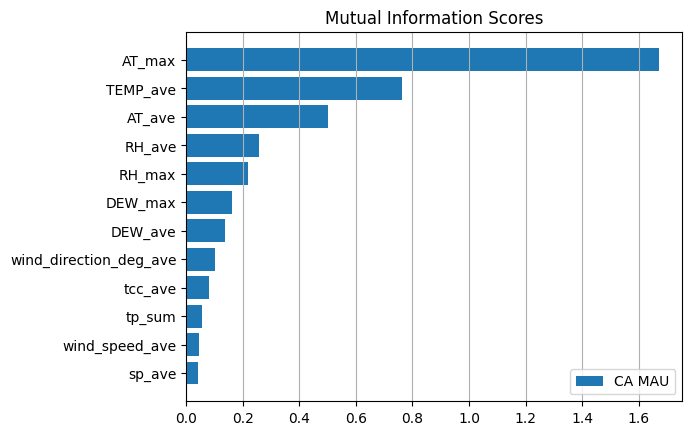

🔸 Trạm: QUY NHON
AT_max                    1.945598
TEMP_ave                  1.237875
AT_ave                    0.923867
DEW_max                   0.511384
sp_ave                    0.456635
DEW_ave                   0.382319
wind_direction_deg_ave    0.348790
wind_speed_ave            0.284262
RH_ave                    0.266590
RH_max                    0.258687
tp_sum                    0.080495
tcc_ave                   0.052913
Name: MI Scores, dtype: float64


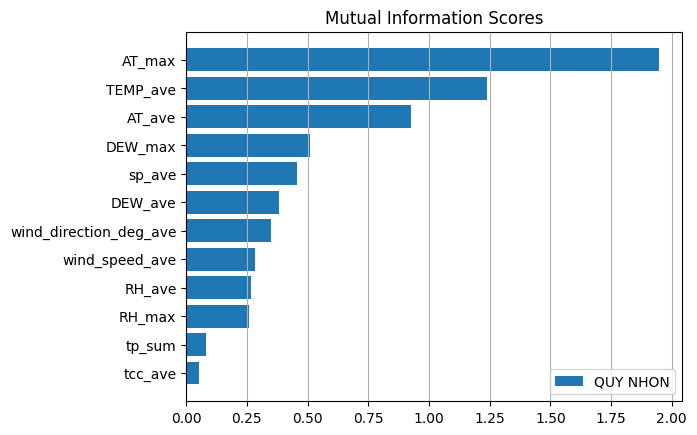

🔸 Trạm: DONG HOI
AT_max                    2.170436
TEMP_ave                  1.685584
AT_ave                    1.446109
DEW_max                   0.827893
DEW_ave                   0.763465
sp_ave                    0.649497
RH_max                    0.581192
RH_ave                    0.464430
wind_direction_deg_ave    0.378271
tp_sum                    0.206375
wind_speed_ave            0.149908
tcc_ave                   0.122400
Name: MI Scores, dtype: float64


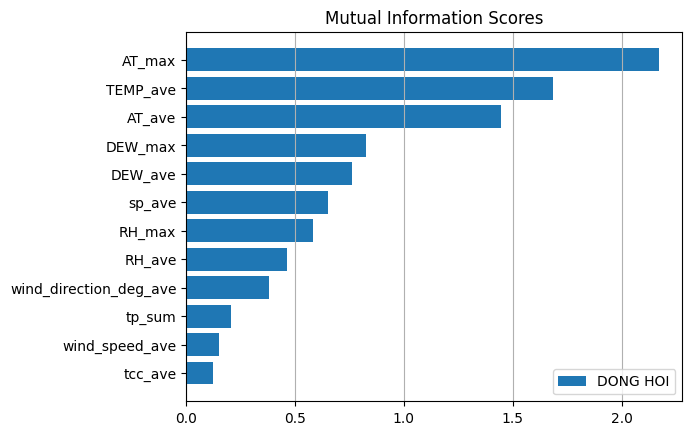

🔸 Trạm: THANH HOA
AT_max                    2.143143
TEMP_ave                  1.660161
AT_ave                    1.404179
DEW_max                   1.110925
DEW_ave                   0.975680
RH_max                    0.675183
sp_ave                    0.554008
RH_ave                    0.393442
wind_direction_deg_ave    0.162129
wind_speed_ave            0.103838
tp_sum                    0.086554
tcc_ave                   0.059977
Name: MI Scores, dtype: float64


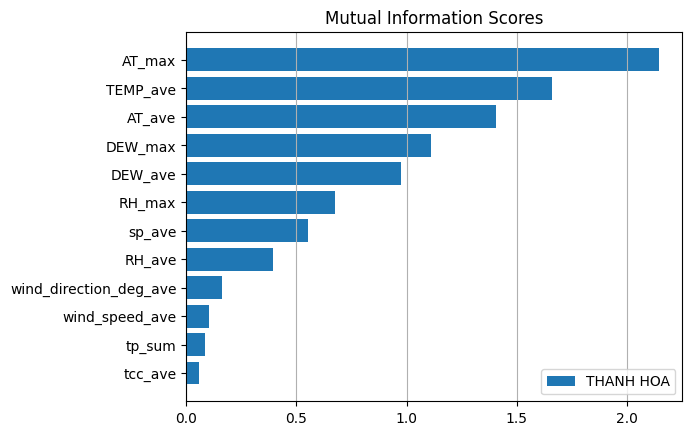

🔸 Trạm: TSN
AT_max                    1.466095
TEMP_ave                  0.627694
AT_ave                    0.258012
RH_ave                    0.198170
RH_max                    0.147115
tcc_ave                   0.115499
wind_direction_deg_ave    0.084884
tp_sum                    0.074768
DEW_ave                   0.054770
wind_speed_ave            0.045141
DEW_max                   0.030941
sp_ave                    0.021559
Name: MI Scores, dtype: float64


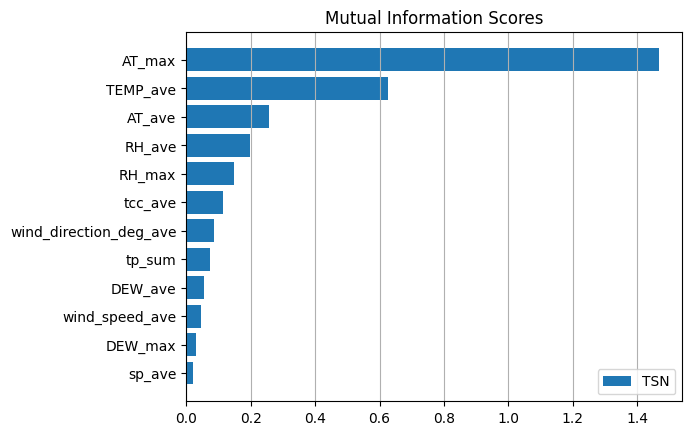

🔸 Trạm: NOI BAI
AT_max                    2.400927
TEMP_ave                  1.504855
AT_ave                    1.155997
DEW_max                   0.791646
DEW_ave                   0.679779
sp_ave                    0.566180
RH_max                    0.415668
wind_direction_deg_ave    0.187605
RH_ave                    0.171177
tp_sum                    0.103228
tcc_ave                   0.065378
wind_speed_ave            0.043767
Name: MI Scores, dtype: float64


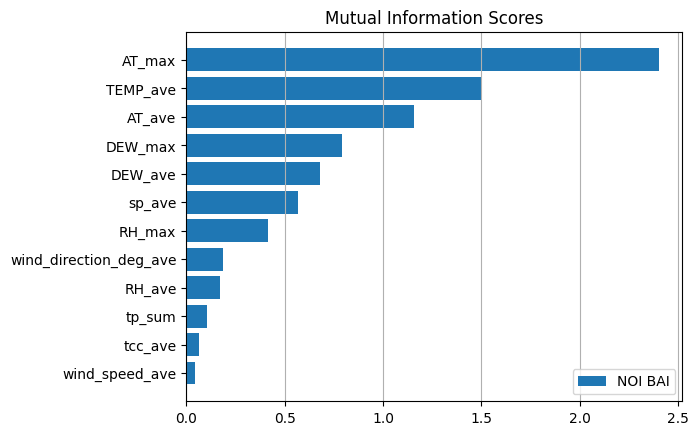

In [29]:
for name in features["NAME"].value_counts().index:
    print(f"🔸 Trạm: {name}")
    mi_scores = plots.make_mi_scores(features     = features.loc[features["NAME"] == name][feature_col], 
                                     target       = targets.loc[targets["NAME"] == name]["TEMP_max"],
                                     type         = "regression",
                                     random_state = PROJ_SEED)

    print(mi_scores)
    plots.plot_mi_scores(mi_scores,label=name)
    plt.show()

In [30]:
# # # Lấy số lượng cột cần giữ lại (17 số cột có điểm MI cao nhất)
# num_columns_to_keep = 17

# # Lấy danh sách các cột cần giữ lại
# columns_to_keep = mi_scores.nlargest(num_columns_to_keep).index

# # Cập nhật X_train_encoded và X_test_encoded chỉ với các cột được giữ lại
# features = features[columns_to_keep]

# # Hiển thị các cột còn lại
# print(f"Các cột được giữ lại:\n{features.columns}")

#### <span style="color:green">4.3. Feature Engineering</span>

In [31]:
features.info()

<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 76704 entries, 1990-01-01 to 2024-12-31
Data columns (total 15 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   NAME                    76704 non-null  object 
 1   LATITUDE                76704 non-null  float64
 2   LONGITUDE               76704 non-null  float64
 3   DEW_ave                 76704 non-null  float64
 4   TEMP_ave                76704 non-null  float64
 5   RH_ave                  76704 non-null  float64
 6   AT_ave                  76704 non-null  float64
 7   DEW_max                 76704 non-null  float64
 8   RH_max                  76704 non-null  float64
 9   AT_max                  76704 non-null  float64
 10  sp_ave                  76704 non-null  float64
 11  tcc_ave                 76704 non-null  float64
 12  tp_sum                  76704 non-null  float64
 13  wind_speed_ave          76704 non-null  float64
 14  wind_direction_deg_av

In [32]:
categorical_features = features.select_dtypes(exclude='number').columns
categorical_features

Index(['NAME'], dtype='object')

In [33]:
numerical_features = features.select_dtypes(include='number').columns
numerical_features

Index(['LATITUDE', 'LONGITUDE', 'DEW_ave', 'TEMP_ave', 'RH_ave', 'AT_ave',
       'DEW_max', 'RH_max', 'AT_max', 'sp_ave', 'tcc_ave', 'tp_sum',
       'wind_speed_ave', 'wind_direction_deg_ave'],
      dtype='object')

##### <span style="color:tomato">Encode categorical feature</span>

In [34]:
categorical_features

Index(['NAME'], dtype='object')

In [35]:
features[categorical_features]

,NAME
time,
1990-01-01,CA MAU
1990-01-01,QUY NHON
1990-01-01,DONG HOI
1990-01-01,THANH HOA
1990-01-01,TSN
...,...
2024-12-31,NOI BAI
2024-12-31,TSN
2024-12-31,CA MAU


In [36]:
# categories = [match_type[col] for col in categorical_features]
# # encoder = OrdinalEncoder(
# #     categories = categories,
# #     handle_unknown = 'use_encoded_value', 
# #     unknown_value  = -1
# # )
# encoder = OneHotEncoder(categories     = categories,
#                         sparse_output  = False,
#                         handle_unknown = "ignore")

features_encoded  = deepcopy(features)

# # # Encode
# # features_cat_encoded  = encoder.fit_transform(features[categorical_features])

# # Kiểm tra số cột
# # print("Số cột của dữ liệu đã mã hóa: ", features_cat_encoded.shape[1])

# # Loại bỏ các cột trong `categorical` khỏi features_encoded
# features_encoded  = features_encoded.drop(columns=categorical_features)

# # Thêm các cột đã mã hóa vào features_encoded
# # encoded_columns = encoder.get_feature_names_out(categorical_features)

# # Tạo DataFrame từ các cột đã mã hóa và gán lại tên cột
# # features_encoded  = pd.DataFrame(features_cat_encoded, columns=encoded_columns, index=features.index)

# # Kết hợp lại với các cột còn lại trong features_encoded
# # features_encoded  = pd.concat([features_encoded, features.drop(columns=categorical_features)], axis=1)
# features_encoded  = features

In [37]:
features_encoded

,NAME,LATITUDE,LONGITUDE,DEW_ave,TEMP_ave,RH_ave,AT_ave,DEW_max,RH_max,AT_max,sp_ave,tcc_ave,tp_sum,wind_speed_ave,wind_direction_deg_ave
time,,,,,,,,,,,,,,,
1990-01-01,CA MAU,9.183333,105.150000,21.760000,24.460000,85.710000,28.910000,22.2,92.950000,32.420000,101.080992,0.963329,0.000669,3.038102,81.611026
1990-01-01,QUY NHON,13.766667,109.216667,20.920000,23.800000,84.435950,27.706273,21.4,92.279648,31.230500,99.714036,0.400093,0.000425,2.383495,164.361671
1990-01-01,DONG HOI,17.483000,106.600000,18.750000,20.280000,90.940000,22.890000,19.5,94.570000,24.040000,100.064575,0.796282,0.000511,1.422625,158.100468
1990-01-01,THANH HOA,19.750000,105.783333,20.400000,22.000000,90.641837,25.582248,20.4,90.641837,25.582248,101.251524,0.999033,0.000457,2.537301,174.652701
1990-01-01,TSN,10.818797,106.651856,21.175758,27.027273,71.463133,31.087169,23.0,88.507803,35.566200,100.972871,0.499631,0.000034,1.601291,150.244327
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2024-12-31,NOI BAI,21.221192,105.807178,11.620000,16.640000,74.290000,15.990000,14.0,100.000000,20.230000,101.780498,0.607103,0.000068,2.114598,178.763194
2024-12-31,TSN,10.818797,106.651856,21.291667,27.479167,69.556134,31.638729,24.0,88.748236,36.254700,101.011929,0.817102,0.000021,1.527386,0.314178
2024-12-31,CA MAU,9.183333,105.150000,24.200000,27.010000,85.080000,33.190000,26.2,95.950000,35.580000,101.134755,0.988316,0.000016,1.709888,323.390110


#### <span style="color:green">4.4. Feature Scaling</span>

In [38]:
# features_encoded[numerical_features]
features_encoded.columns

Index(['NAME', 'LATITUDE', 'LONGITUDE', 'DEW_ave', 'TEMP_ave', 'RH_ave',
       'AT_ave', 'DEW_max', 'RH_max', 'AT_max', 'sp_ave', 'tcc_ave', 'tp_sum',
       'wind_speed_ave', 'wind_direction_deg_ave'],
      dtype='object')

In [39]:
# plots.plot_Outlier(data      = features_encoded,
#                    data_cols = feature_col,
#                    target    = "NAME")

In [40]:
features_encoded[feature_col]

,DEW_ave,TEMP_ave,RH_ave,AT_ave,DEW_max,RH_max,AT_max,sp_ave,tcc_ave,tp_sum,wind_speed_ave,wind_direction_deg_ave
time,,,,,,,,,,,,
1990-01-01,21.760000,24.460000,85.710000,28.910000,22.2,92.950000,32.420000,101.080992,0.963329,0.000669,3.038102,81.611026
1990-01-01,20.920000,23.800000,84.435950,27.706273,21.4,92.279648,31.230500,99.714036,0.400093,0.000425,2.383495,164.361671
1990-01-01,18.750000,20.280000,90.940000,22.890000,19.5,94.570000,24.040000,100.064575,0.796282,0.000511,1.422625,158.100468
1990-01-01,20.400000,22.000000,90.641837,25.582248,20.4,90.641837,25.582248,101.251524,0.999033,0.000457,2.537301,174.652701
1990-01-01,21.175758,27.027273,71.463133,31.087169,23.0,88.507803,35.566200,100.972871,0.499631,0.000034,1.601291,150.244327
...,...,...,...,...,...,...,...,...,...,...,...,...
2024-12-31,11.620000,16.640000,74.290000,15.990000,14.0,100.000000,20.230000,101.780498,0.607103,0.000068,2.114598,178.763194
2024-12-31,21.291667,27.479167,69.556134,31.638729,24.0,88.748236,36.254700,101.011929,0.817102,0.000021,1.527386,0.314178
2024-12-31,24.200000,27.010000,85.080000,33.190000,26.2,95.950000,35.580000,101.134755,0.988316,0.000016,1.709888,323.390110


##### <span style="color:tomato">Handling abnormal <~> outlier values</span>

In [41]:
df_temp = df.copy()

🔸 Trạm: CaMau
🔹 LATITUDE (IQR, k=1.5): 0 outliers ~ 0.00%
~> Outlier detected: 12784 outliers ~ 100.00%
Khong co outlier, skip!!!
🔹 LONGITUDE (IQR, k=1.5): 0 outliers ~ 0.00%
~> Outlier detected: 12784 outliers ~ 100.00%
Khong co outlier, skip!!!
🔹 DEW_ave (IQR, k=1.5): 390 outliers ~ 3.05%
~> Outlier detected: 390 outliers ~ 3.05%
🔹 TEMP_ave (IQR, k=1.5): 99 outliers ~ 0.77%
~> Outlier detected: 99 outliers ~ 0.77%
🔹 RH_ave (IQR, k=1.5): 30 outliers ~ 0.23%
~> Outlier detected: 30 outliers ~ 0.23%
🔹 AT_ave (IQR, k=1.5): 154 outliers ~ 1.20%
~> Outlier detected: 154 outliers ~ 1.20%
🔹 DEW_max (IQR, k=1.5): 296 outliers ~ 2.32%
~> Outlier detected: 296 outliers ~ 2.32%
🔹 RH_max (IQR, k=1.5): 276 outliers ~ 2.16%
~> Outlier detected: 276 outliers ~ 2.16%
🔹 AT_max (IQR, k=1.5): 176 outliers ~ 1.38%
~> Outlier detected: 176 outliers ~ 1.38%
🔹 sp_ave (IQR, k=1.5): 82 outliers ~ 0.64%
~> Outlier detected: 82 outliers ~ 0.64%
🔹 tcc_ave (IQR, k=1.5): 10 outliers ~ 0.08%
~> Outlier detected: 10

C:\Users\tanda\AppData\Local\Temp\ipykernel_5624\366027161.py:29: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df[df['NAME'] == src_name[name]] = station_temp


🔹 LONGITUDE (IQR, k=1.5): 0 outliers ~ 0.00%
~> Outlier detected: 12784 outliers ~ 100.00%
Khong co outlier, skip!!!
🔹 DEW_ave (IQR, k=1.5): 374 outliers ~ 2.93%
~> Outlier detected: 374 outliers ~ 2.93%
🔹 TEMP_ave (IQR, k=1.5): 6 outliers ~ 0.05%
~> Outlier detected: 6 outliers ~ 0.05%
🔹 RH_ave (IQR, k=1.5): 112 outliers ~ 0.88%
~> Outlier detected: 112 outliers ~ 0.88%
🔹 AT_ave (IQR, k=1.5): 6 outliers ~ 0.05%
~> Outlier detected: 6 outliers ~ 0.05%
🔹 DEW_max (IQR, k=1.5): 366 outliers ~ 2.86%
~> Outlier detected: 366 outliers ~ 2.86%
🔹 RH_max (IQR, k=1.5): 1229 outliers ~ 9.61%
~> Outlier detected: 1229 outliers ~ 9.61%
🔹 AT_max (IQR, k=1.5): 9 outliers ~ 0.07%
~> Outlier detected: 9 outliers ~ 0.07%
🔹 sp_ave (IQR, k=1.5): 0 outliers ~ 0.00%
~> Outlier detected: 12784 outliers ~ 100.00%
Khong co outlier, skip!!!
🔹 tcc_ave (IQR, k=1.5): 0 outliers ~ 0.00%
~> Outlier detected: 12784 outliers ~ 100.00%
Khong co outlier, skip!!!
🔹 tp_sum (IQR, k=1.5): 1387 outliers ~ 10.85%
~> Outlier d

C:\Users\tanda\AppData\Local\Temp\ipykernel_5624\366027161.py:29: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df[df['NAME'] == src_name[name]] = station_temp


🔹 DEW_ave (IQR, k=1.5): 82 outliers ~ 0.64%
~> Outlier detected: 82 outliers ~ 0.64%
🔹 TEMP_ave (IQR, k=1.5): 5 outliers ~ 0.04%
~> Outlier detected: 5 outliers ~ 0.04%
🔹 RH_ave (IQR, k=1.5): 197 outliers ~ 1.54%
~> Outlier detected: 197 outliers ~ 1.54%
🔹 AT_ave (IQR, k=1.5): 0 outliers ~ 0.00%
~> Outlier detected: 12784 outliers ~ 100.00%
Khong co outlier, skip!!!
🔹 DEW_max (IQR, k=1.5): 71 outliers ~ 0.56%
~> Outlier detected: 71 outliers ~ 0.56%
🔹 RH_max (IQR, k=1.5): 1063 outliers ~ 8.32%
~> Outlier detected: 1063 outliers ~ 8.32%
🔹 AT_max (IQR, k=1.5): 0 outliers ~ 0.00%
~> Outlier detected: 12784 outliers ~ 100.00%
Khong co outlier, skip!!!
🔹 sp_ave (IQR, k=1.5): 0 outliers ~ 0.00%
~> Outlier detected: 12784 outliers ~ 100.00%
Khong co outlier, skip!!!
🔹 tcc_ave (IQR, k=1.5): 62 outliers ~ 0.48%
~> Outlier detected: 62 outliers ~ 0.48%
🔹 tp_sum (IQR, k=1.5): 1395 outliers ~ 10.91%
~> Outlier detected: 1395 outliers ~ 10.91%
Khong co outlier, skip!!!
🔹 wind_speed_ave (IQR, k=1.5)

C:\Users\tanda\AppData\Local\Temp\ipykernel_5624\366027161.py:29: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df[df['NAME'] == src_name[name]] = station_temp


🔸 Trạm: QN
🔹 LATITUDE (IQR, k=1.5): 0 outliers ~ 0.00%
~> Outlier detected: 12784 outliers ~ 100.00%
Khong co outlier, skip!!!
🔹 LONGITUDE (IQR, k=1.5): 0 outliers ~ 0.00%
~> Outlier detected: 12784 outliers ~ 100.00%
Khong co outlier, skip!!!
🔹 DEW_ave (IQR, k=1.5): 288 outliers ~ 2.25%
~> Outlier detected: 288 outliers ~ 2.25%
🔹 TEMP_ave (IQR, k=1.5): 7 outliers ~ 0.05%
~> Outlier detected: 7 outliers ~ 0.05%
🔹 RH_ave (IQR, k=1.5): 555 outliers ~ 4.34%
~> Outlier detected: 555 outliers ~ 4.34%
🔹 AT_ave (IQR, k=1.5): 41 outliers ~ 0.32%
~> Outlier detected: 41 outliers ~ 0.32%
🔹 DEW_max (IQR, k=1.5): 195 outliers ~ 1.53%
~> Outlier detected: 195 outliers ~ 1.53%
🔹 RH_max (IQR, k=1.5): 704 outliers ~ 5.51%
~> Outlier detected: 704 outliers ~ 5.51%
🔹 AT_max (IQR, k=1.5): 10 outliers ~ 0.08%
~> Outlier detected: 10 outliers ~ 0.08%
🔹 sp_ave (IQR, k=1.5): 0 outliers ~ 0.00%
~> Outlier detected: 12784 outliers ~ 100.00%
Khong co outlier, skip!!!
🔹 tcc_ave (IQR, k=1.5): 0 outliers ~ 0.00%
~

C:\Users\tanda\AppData\Local\Temp\ipykernel_5624\366027161.py:29: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df[df['NAME'] == src_name[name]] = station_temp
f:\NCKH\TSF_Github\Drafts\Temp Prediction\notebooks\3.1. ML_model\../..\src\utilities\dataset.py:715: RuntimeWarning: More than 20 figures have been opened. Figures created through the pyplot interface (`matplotlib.pyplot.figure`) are retained until explicitly closed and may consume too much memory. (To control this warning, see the rcParam `figure.max_open_warning`). Consider using `matplotlib.pyplot.close()`.
  fig, axes = plt.subplots(2, 2, figsize=(20, 10))


🔹 LATITUDE (IQR, k=1.5): 0 outliers ~ 0.00%
~> Outlier detected: 12784 outliers ~ 100.00%
Khong co outlier, skip!!!
🔹 LONGITUDE (IQR, k=1.5): 0 outliers ~ 0.00%
~> Outlier detected: 12784 outliers ~ 100.00%
Khong co outlier, skip!!!
🔹 DEW_ave (IQR, k=1.5): 245 outliers ~ 1.92%
~> Outlier detected: 245 outliers ~ 1.92%
🔹 TEMP_ave (IQR, k=1.5): 10 outliers ~ 0.08%
~> Outlier detected: 10 outliers ~ 0.08%
🔹 RH_ave (IQR, k=1.5): 258 outliers ~ 2.02%
~> Outlier detected: 258 outliers ~ 2.02%
🔹 AT_ave (IQR, k=1.5): 1 outliers ~ 0.01%
~> Outlier detected: 1 outliers ~ 0.01%
🔹 DEW_max (IQR, k=1.5): 185 outliers ~ 1.45%
~> Outlier detected: 185 outliers ~ 1.45%
🔹 RH_max (IQR, k=1.5): 1086 outliers ~ 8.49%
~> Outlier detected: 1086 outliers ~ 8.49%
🔹 AT_max (IQR, k=1.5): 3 outliers ~ 0.02%
~> Outlier detected: 3 outliers ~ 0.02%
🔹 sp_ave (IQR, k=1.5): 0 outliers ~ 0.00%
~> Outlier detected: 12784 outliers ~ 100.00%
Khong co outlier, skip!!!
🔹 tcc_ave (IQR, k=1.5): 0 outliers ~ 0.00%
~> Outlier d

C:\Users\tanda\AppData\Local\Temp\ipykernel_5624\366027161.py:29: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df[df['NAME'] == src_name[name]] = station_temp


🔹 LONGITUDE (IQR, k=1.5): 0 outliers ~ 0.00%
~> Outlier detected: 12784 outliers ~ 100.00%
Khong co outlier, skip!!!
🔹 DEW_ave (IQR, k=1.5): 418 outliers ~ 3.27%
~> Outlier detected: 418 outliers ~ 3.27%
🔹 TEMP_ave (IQR, k=1.5): 112 outliers ~ 0.88%
~> Outlier detected: 112 outliers ~ 0.88%
🔹 RH_ave (IQR, k=1.5): 10 outliers ~ 0.08%
~> Outlier detected: 10 outliers ~ 0.08%
🔹 AT_ave (IQR, k=1.5): 299 outliers ~ 2.34%
~> Outlier detected: 299 outliers ~ 2.34%
🔹 DEW_max (IQR, k=1.5): 342 outliers ~ 2.68%
~> Outlier detected: 342 outliers ~ 2.68%
🔹 RH_max (IQR, k=1.5): 432 outliers ~ 3.38%
~> Outlier detected: 432 outliers ~ 3.38%
🔹 AT_max (IQR, k=1.5): 256 outliers ~ 2.00%
~> Outlier detected: 256 outliers ~ 2.00%
🔹 sp_ave (IQR, k=1.5): 50 outliers ~ 0.39%
~> Outlier detected: 50 outliers ~ 0.39%
🔹 tcc_ave (IQR, k=1.5): 0 outliers ~ 0.00%
~> Outlier detected: 12784 outliers ~ 100.00%
Khong co outlier, skip!!!
🔹 tp_sum (IQR, k=1.5): 399 outliers ~ 3.12%
~> Outlier detected: 399 outliers ~ 

C:\Users\tanda\AppData\Local\Temp\ipykernel_5624\366027161.py:29: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df[df['NAME'] == src_name[name]] = station_temp


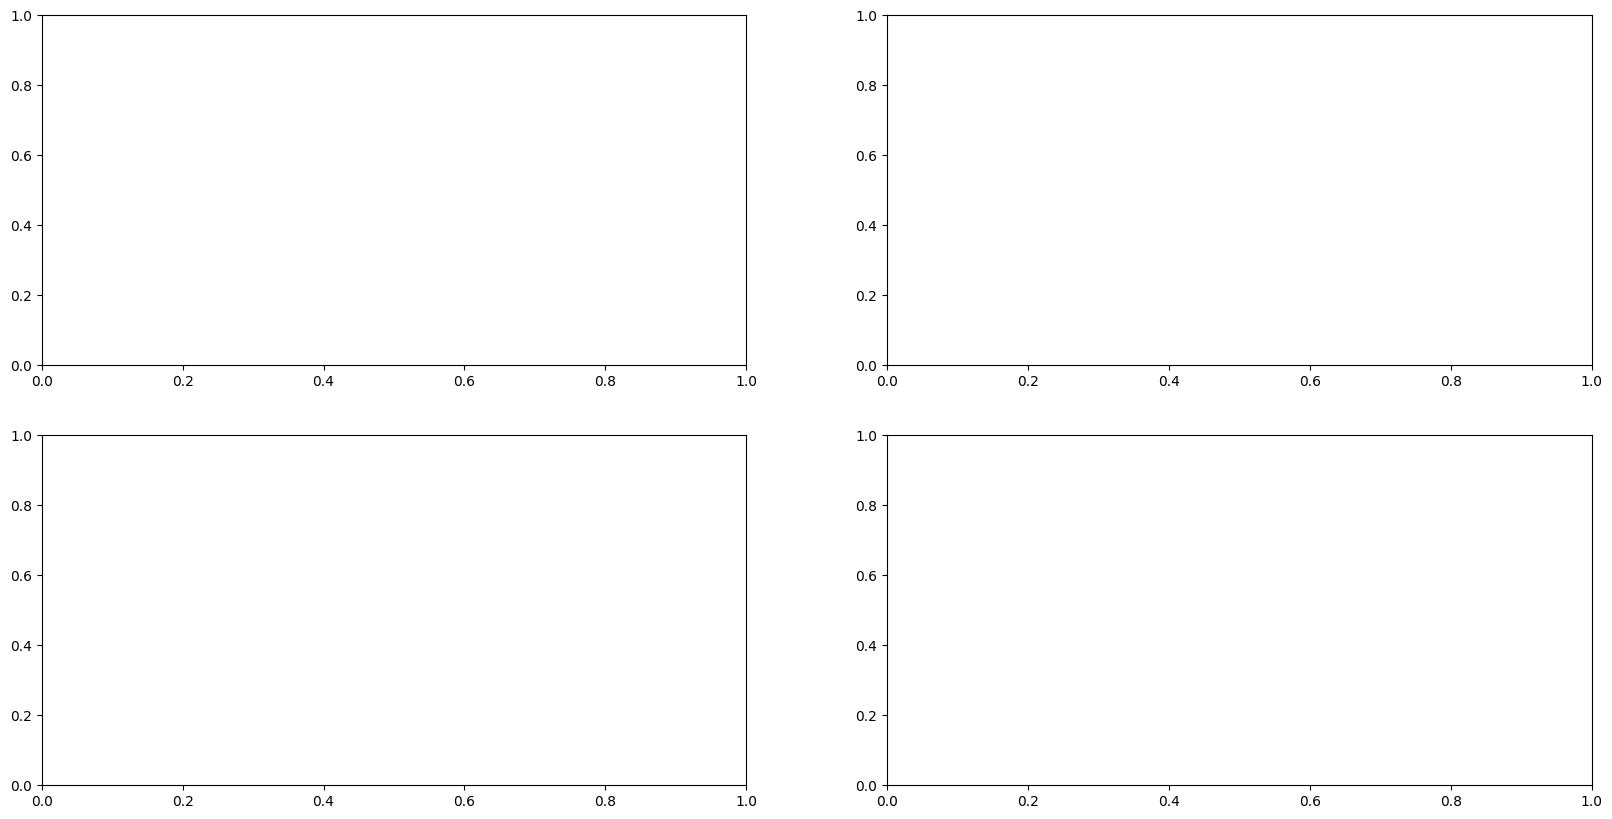

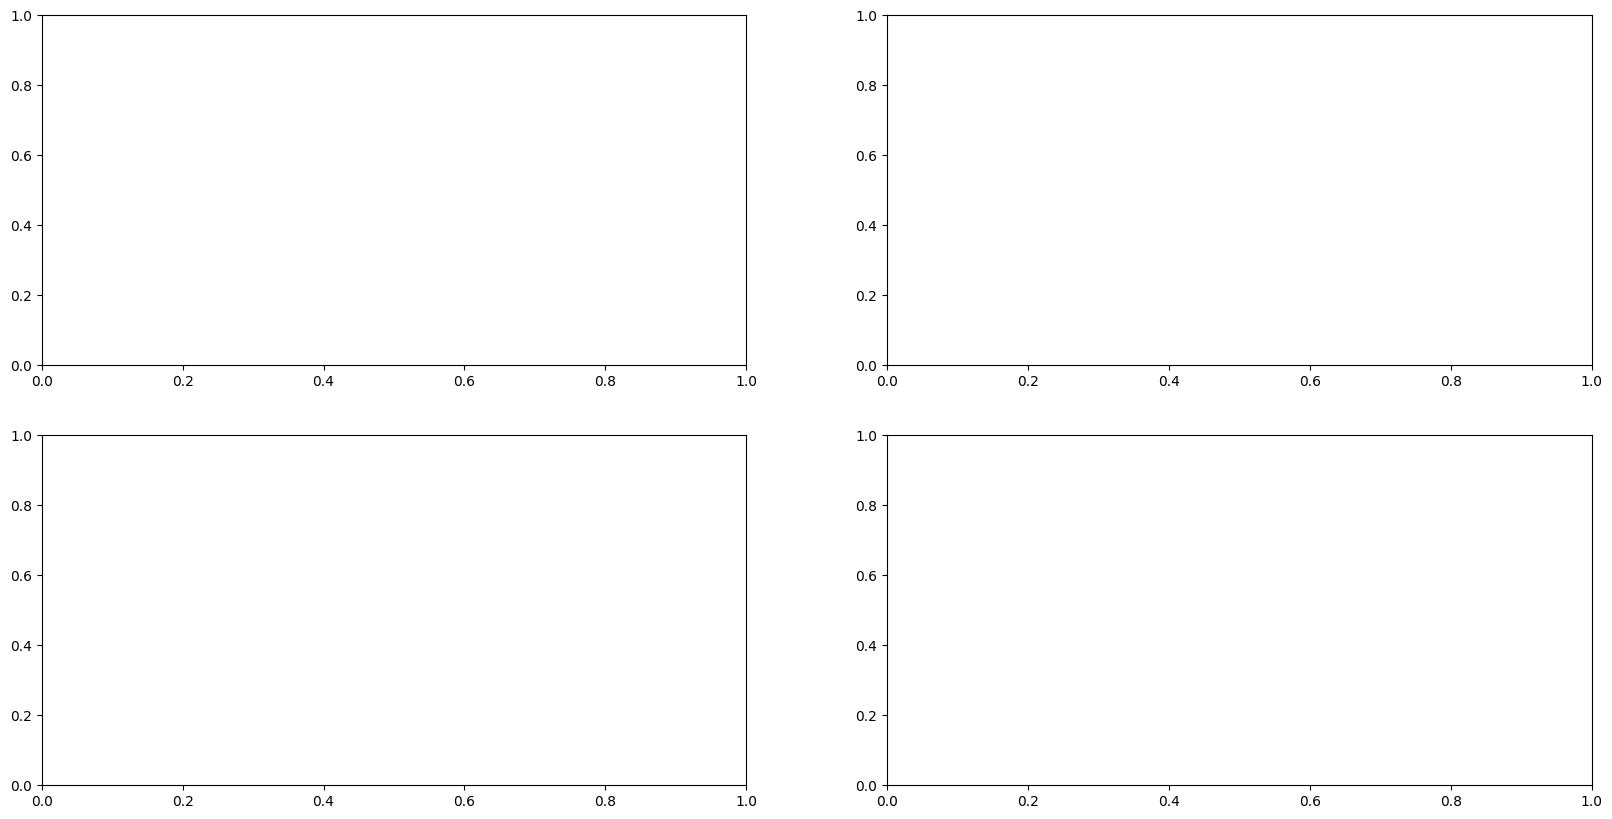

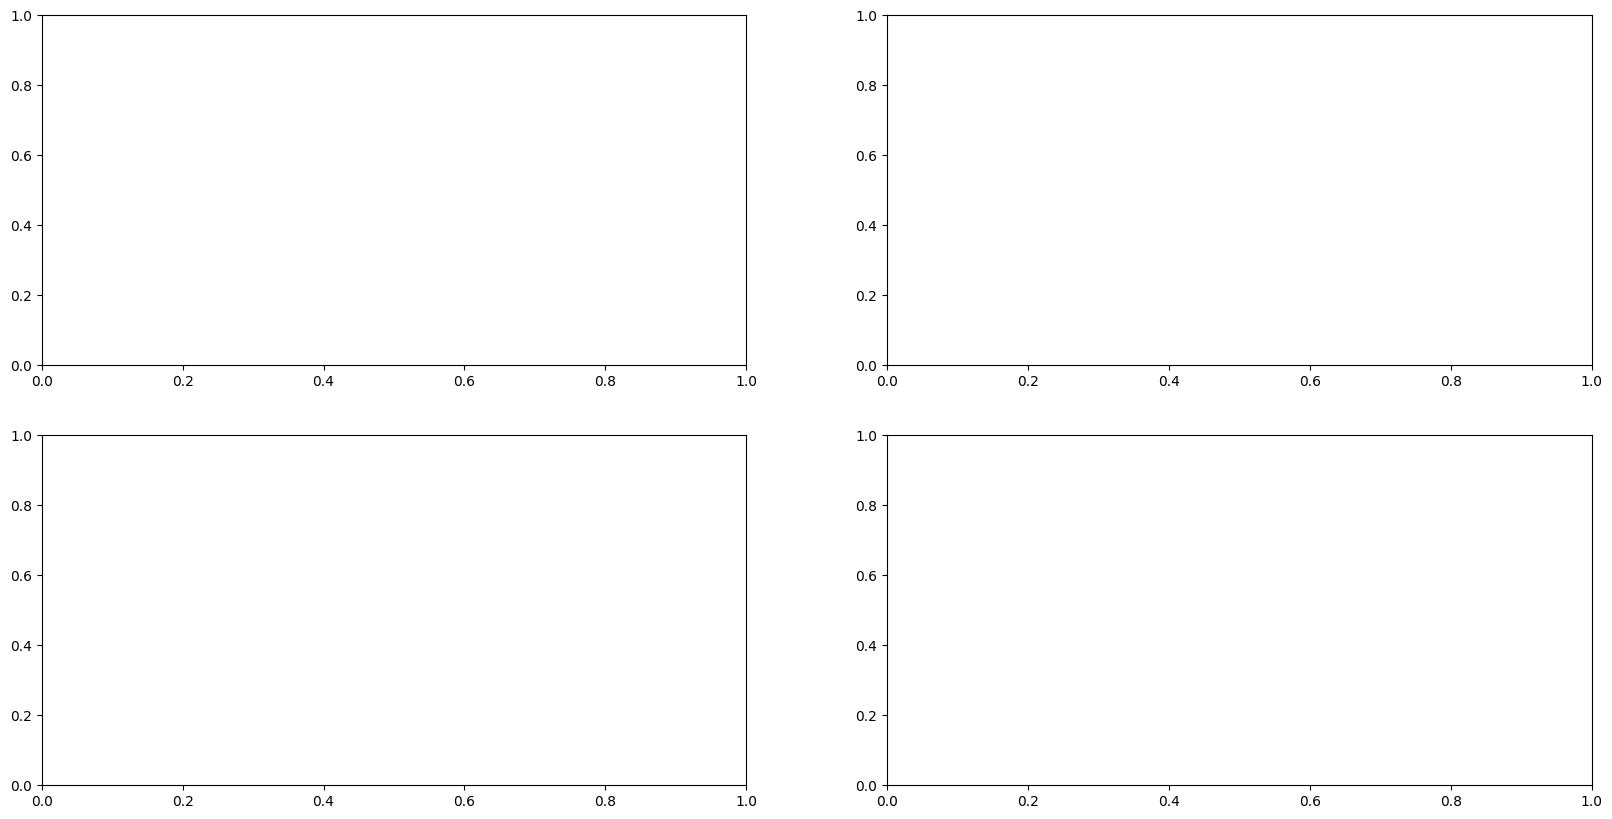

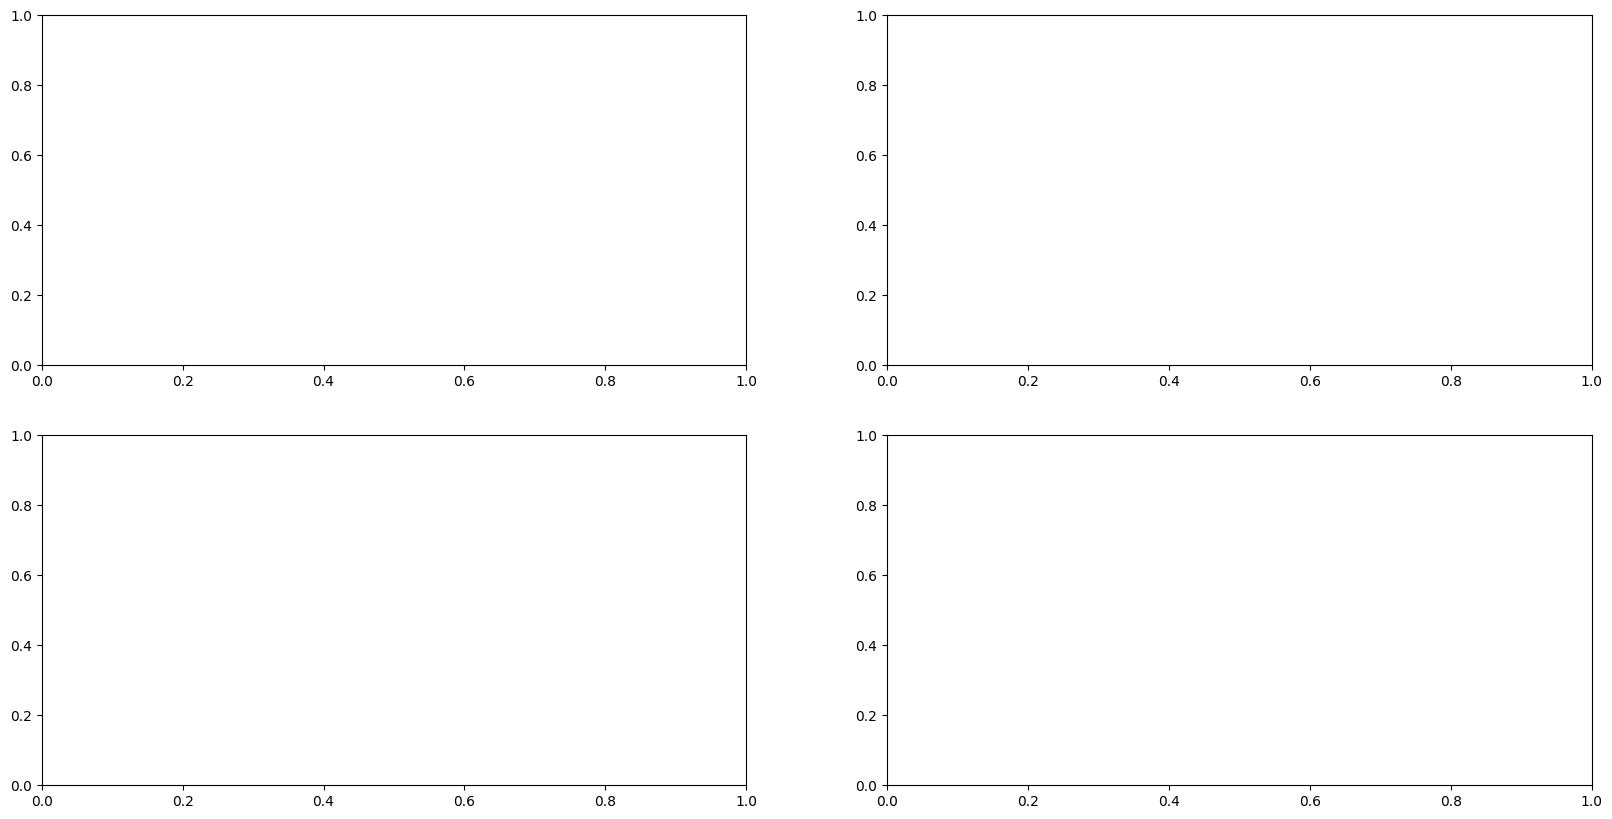

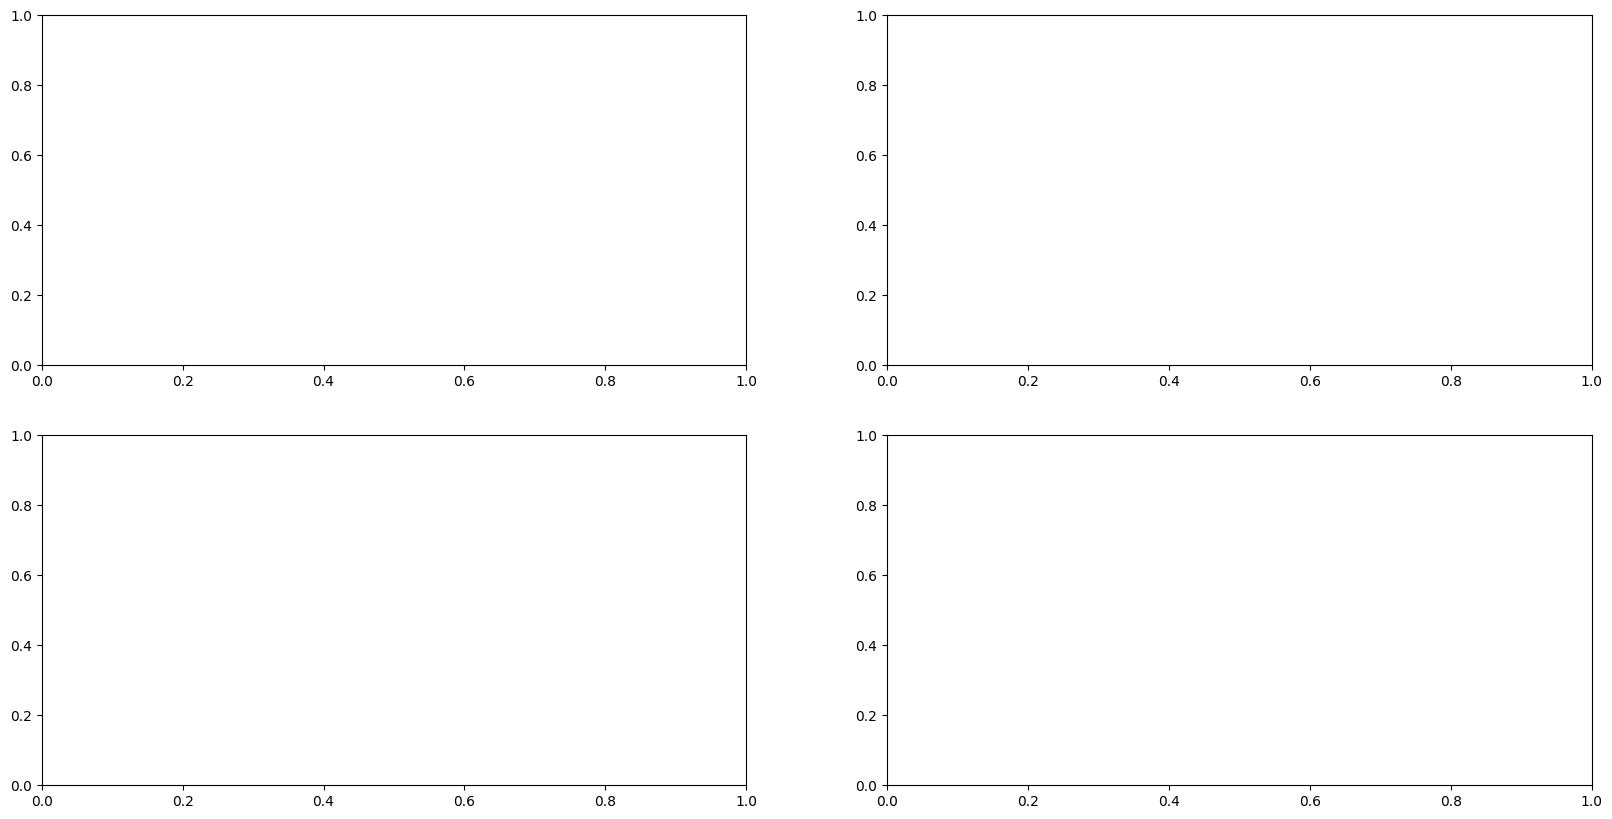

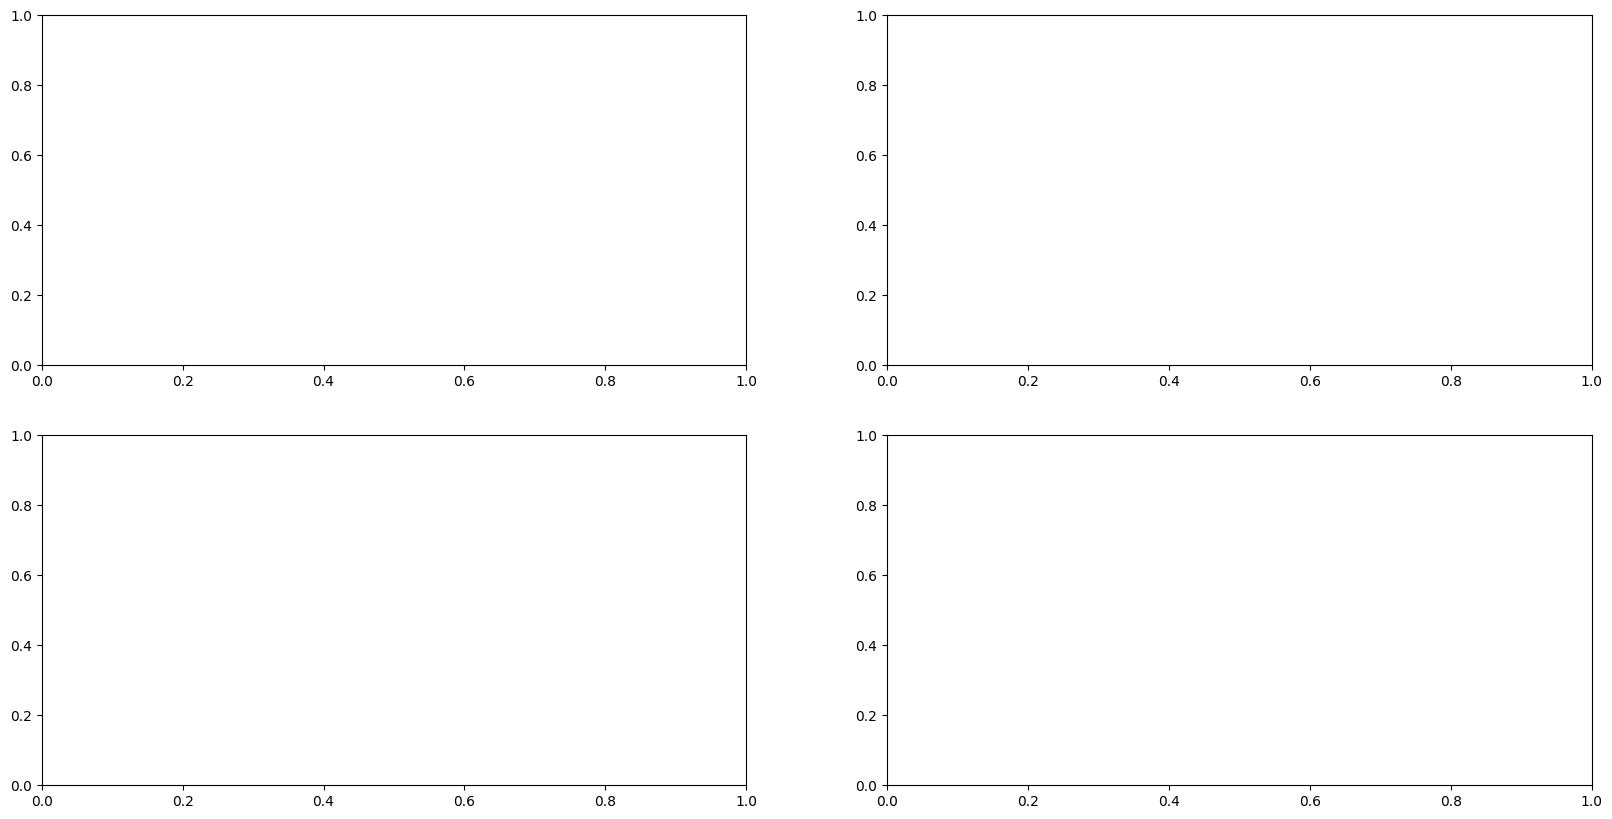

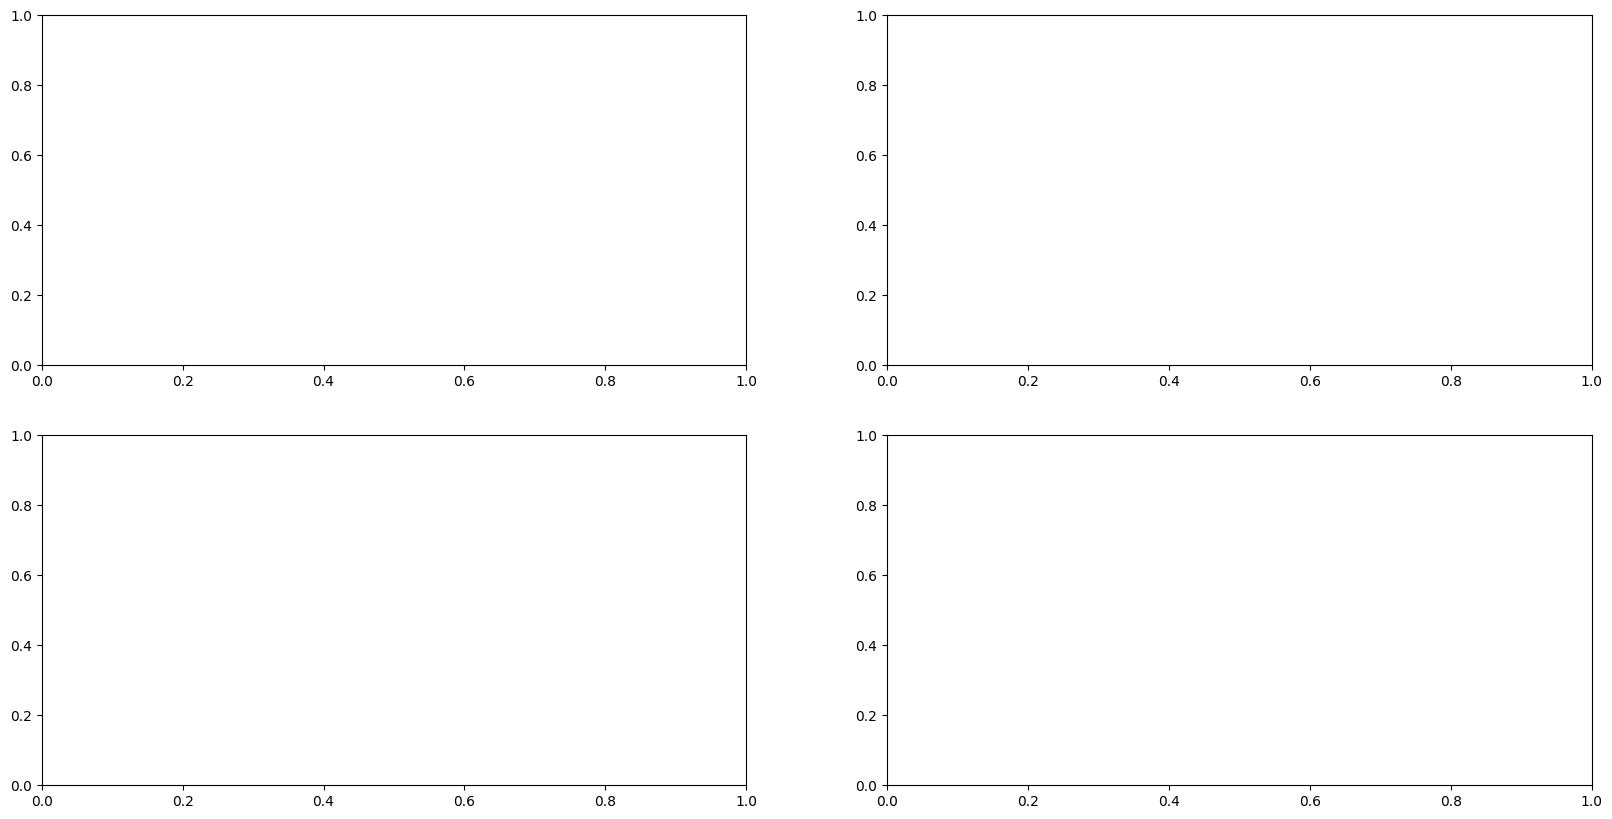

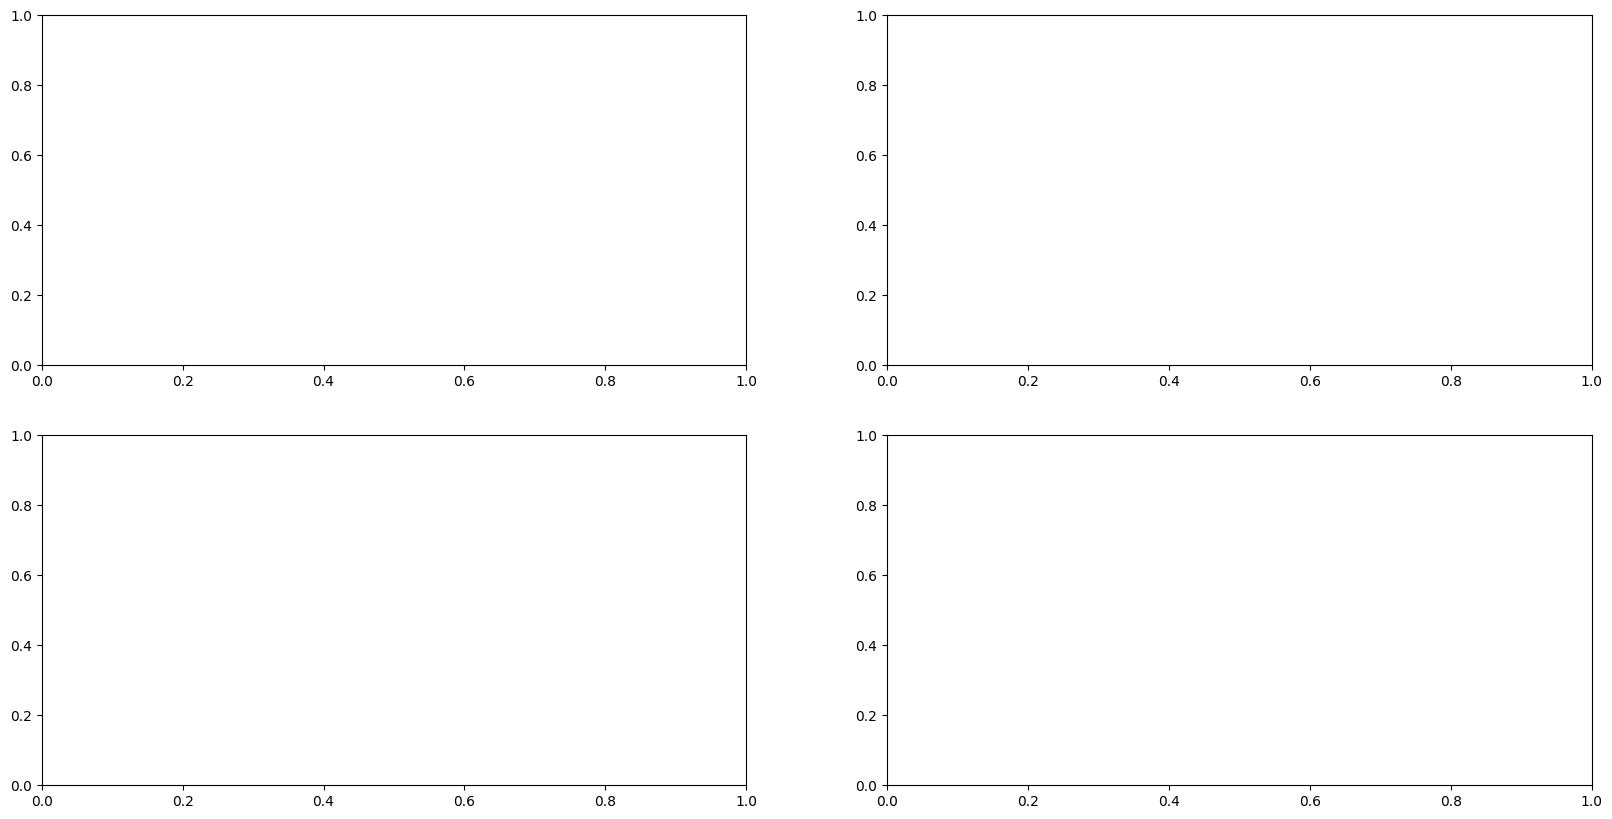

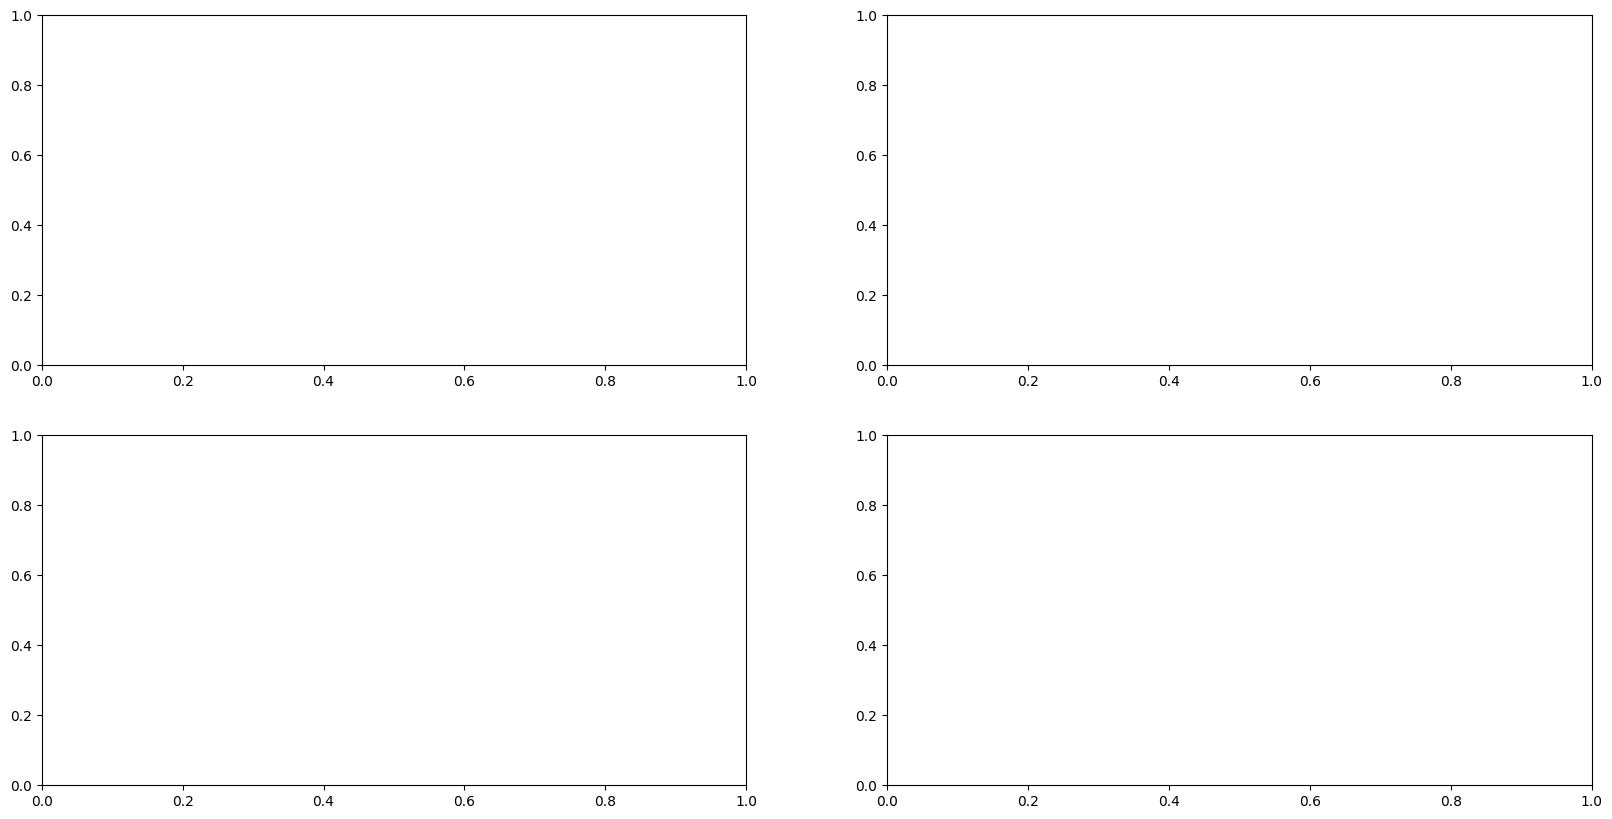

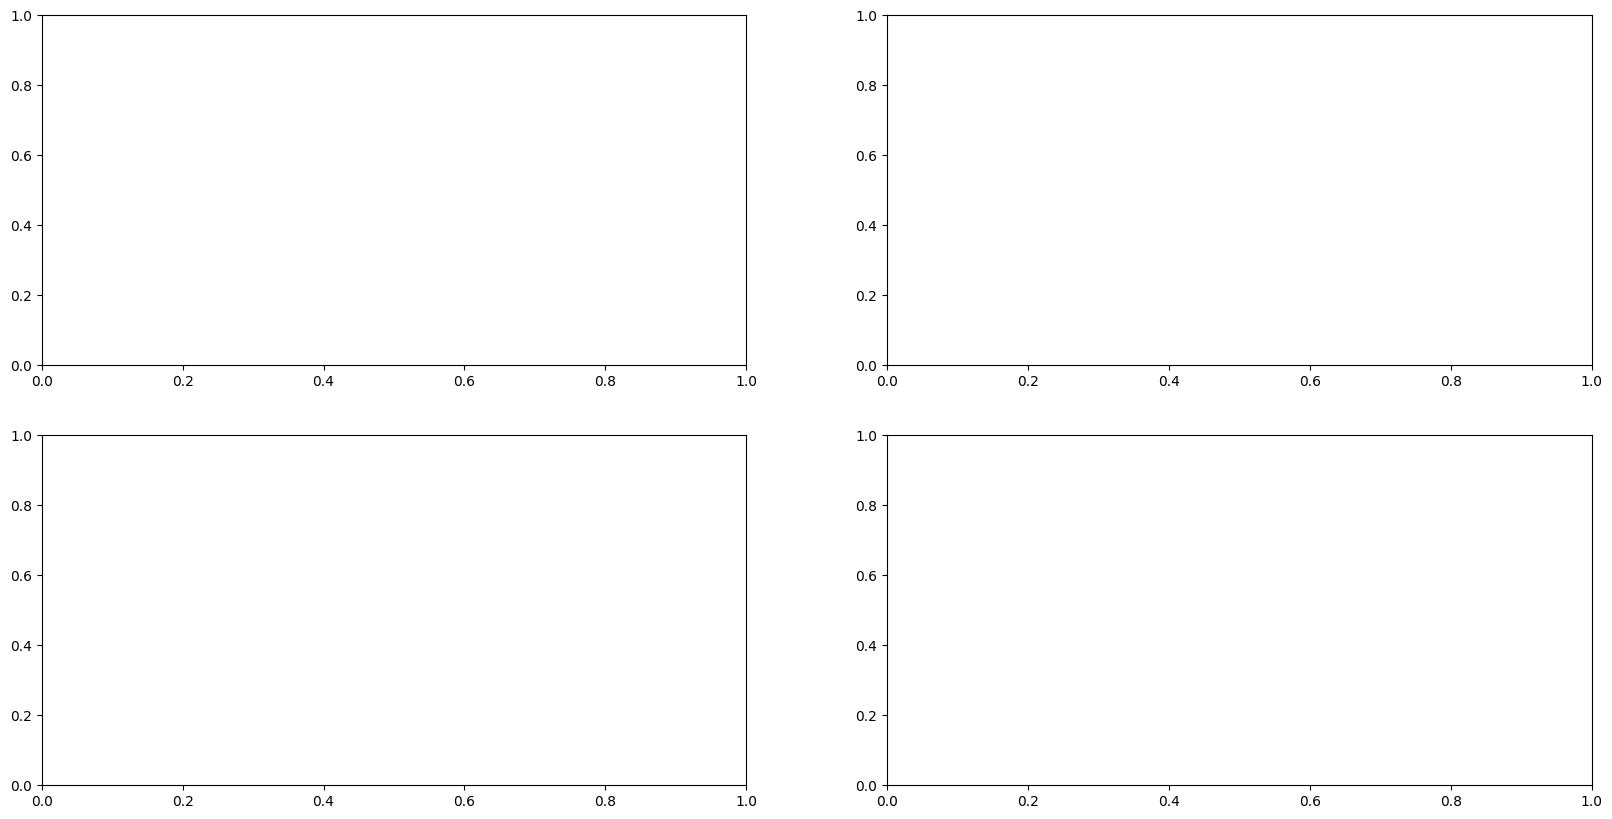

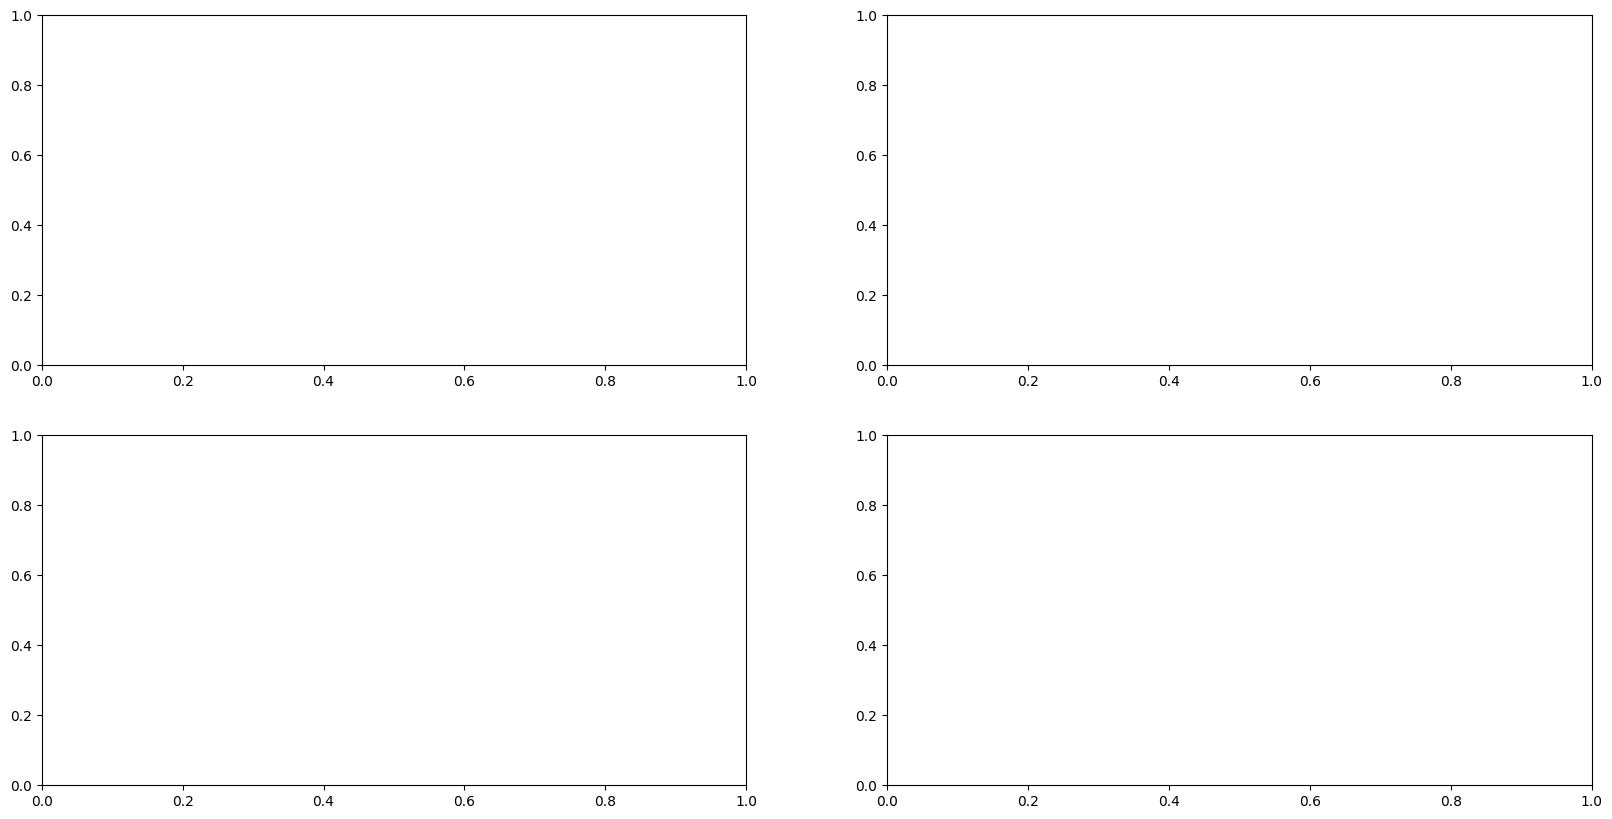

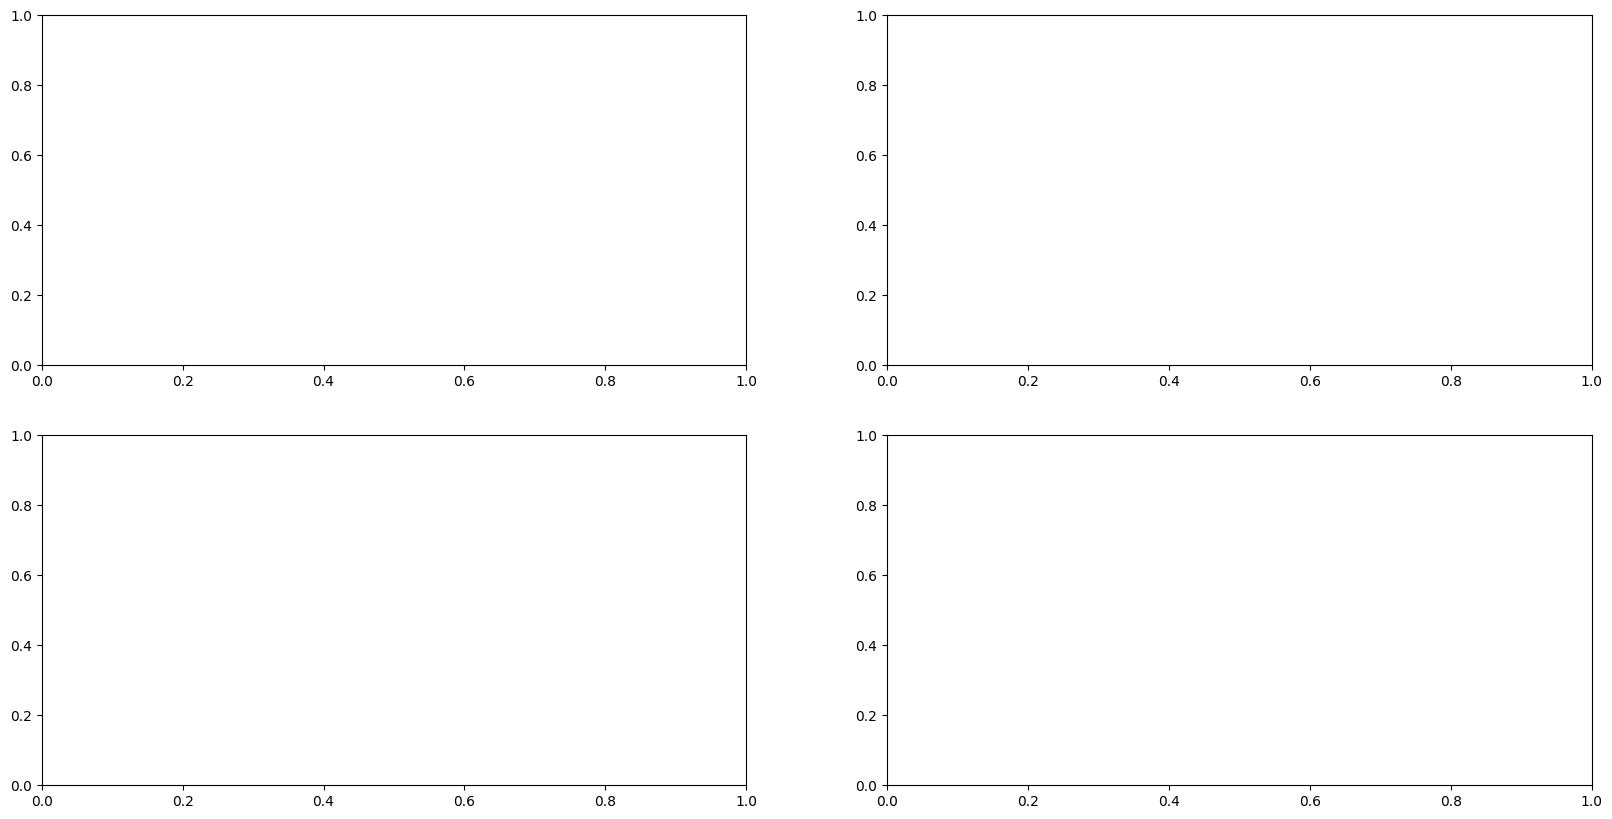

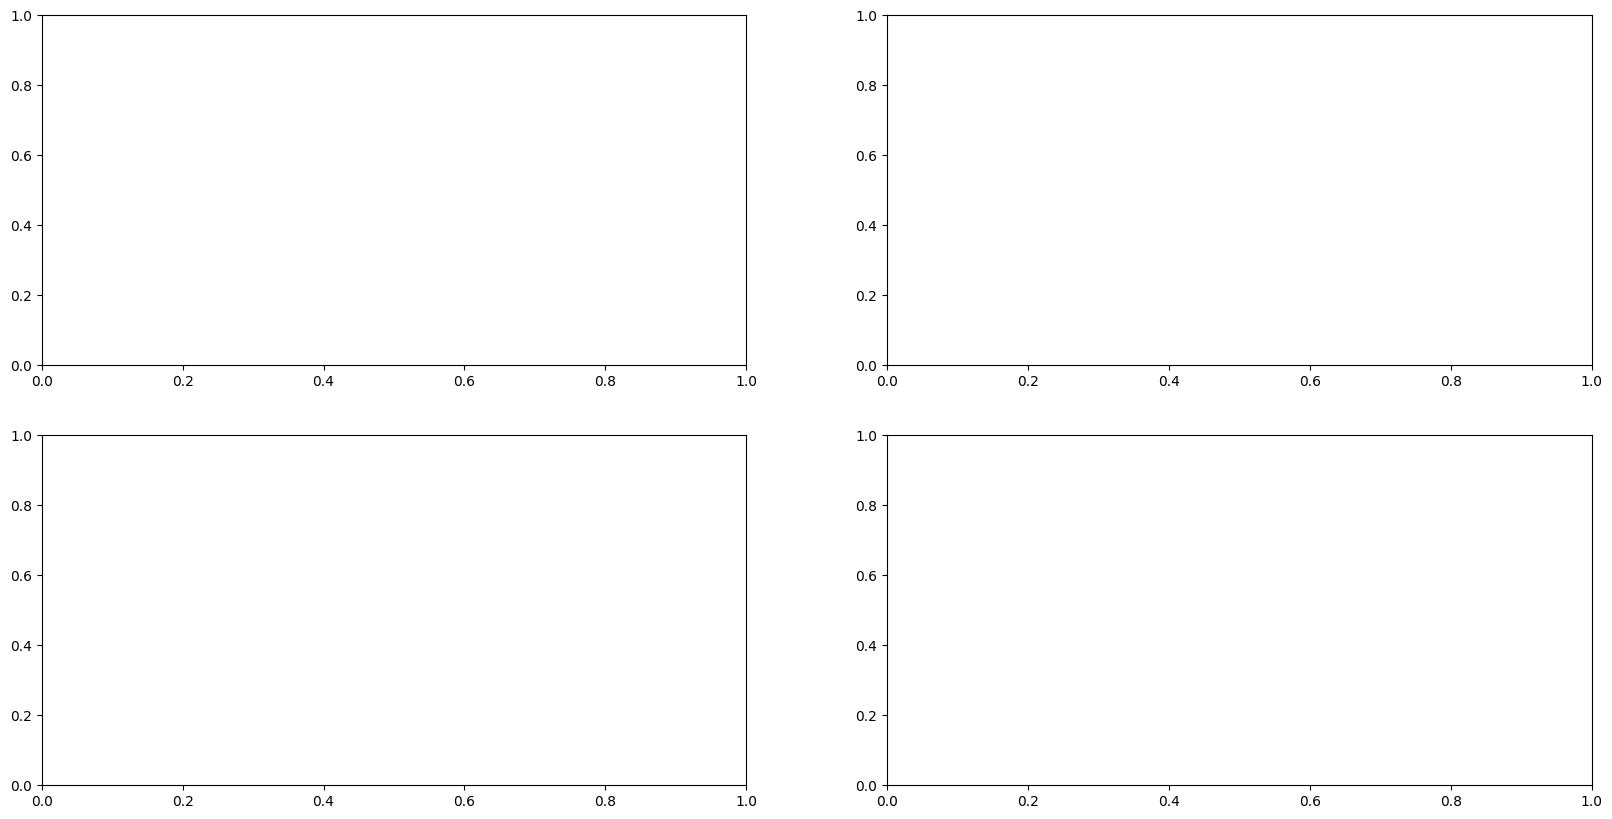

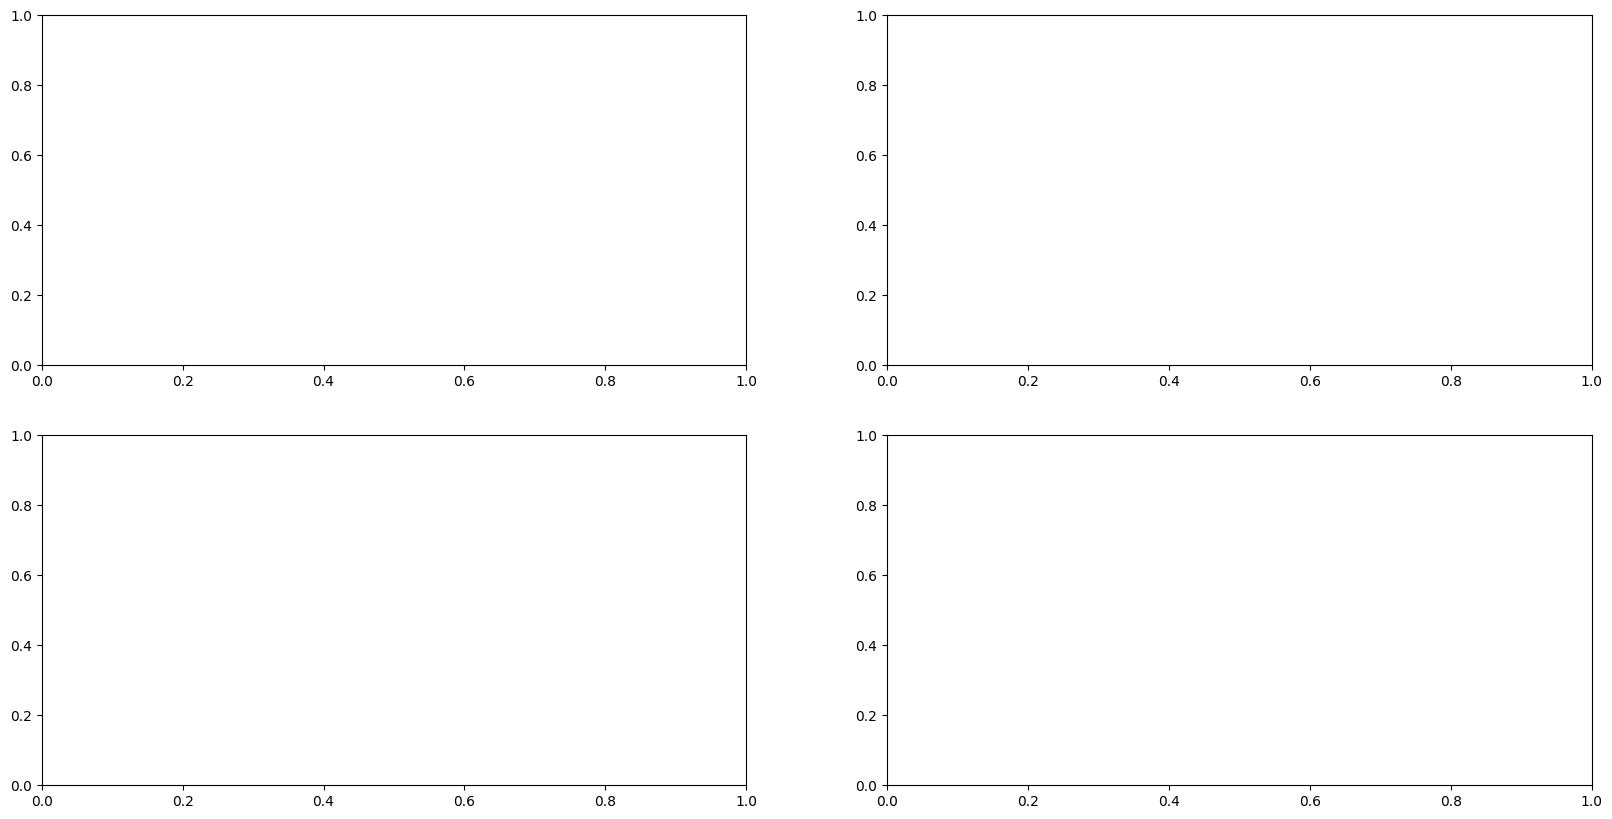

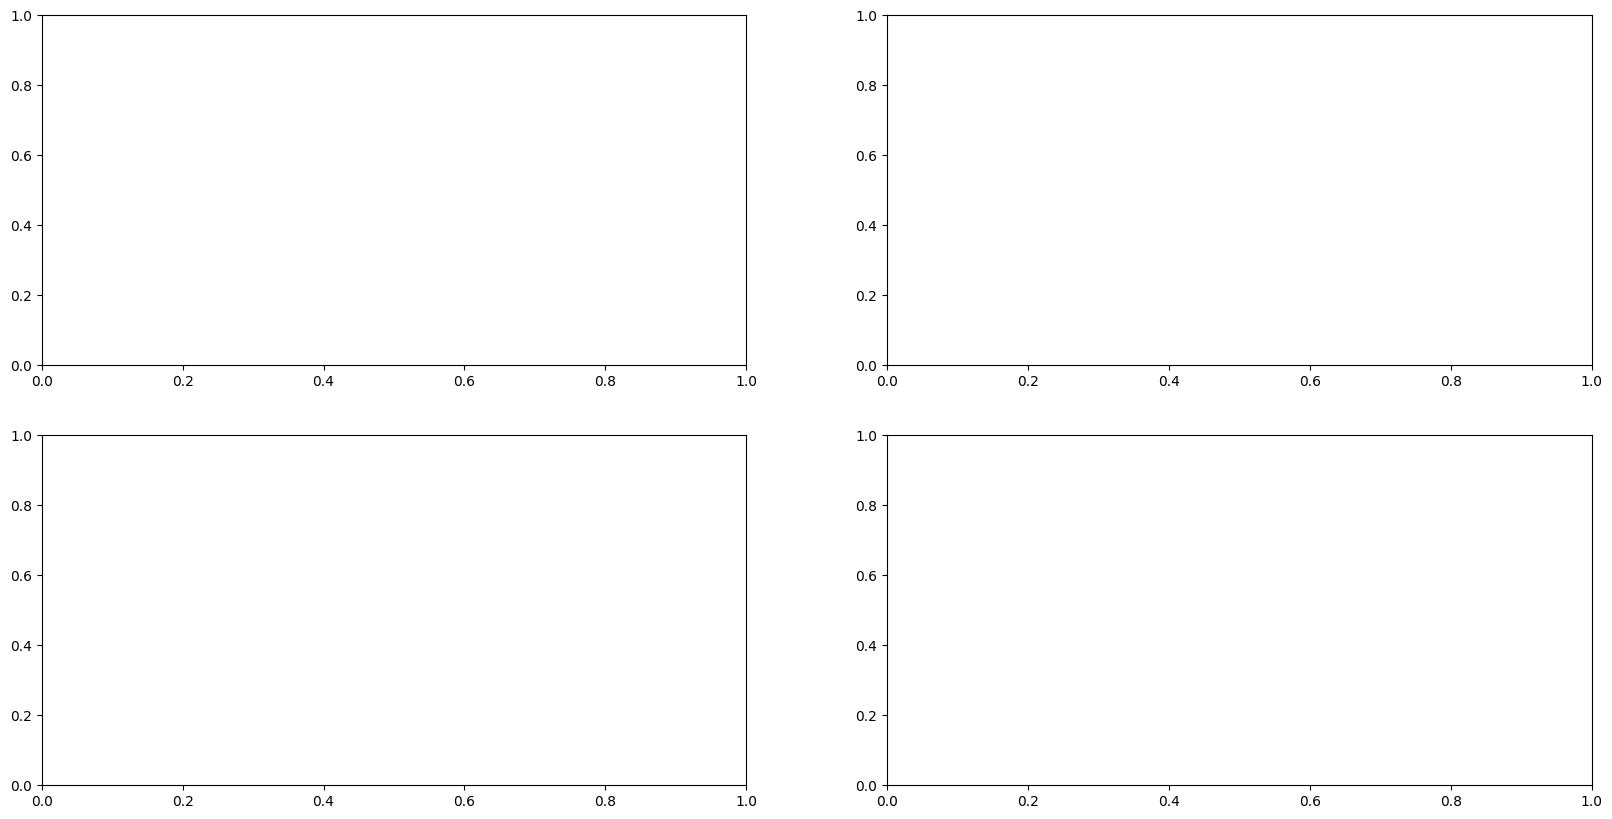

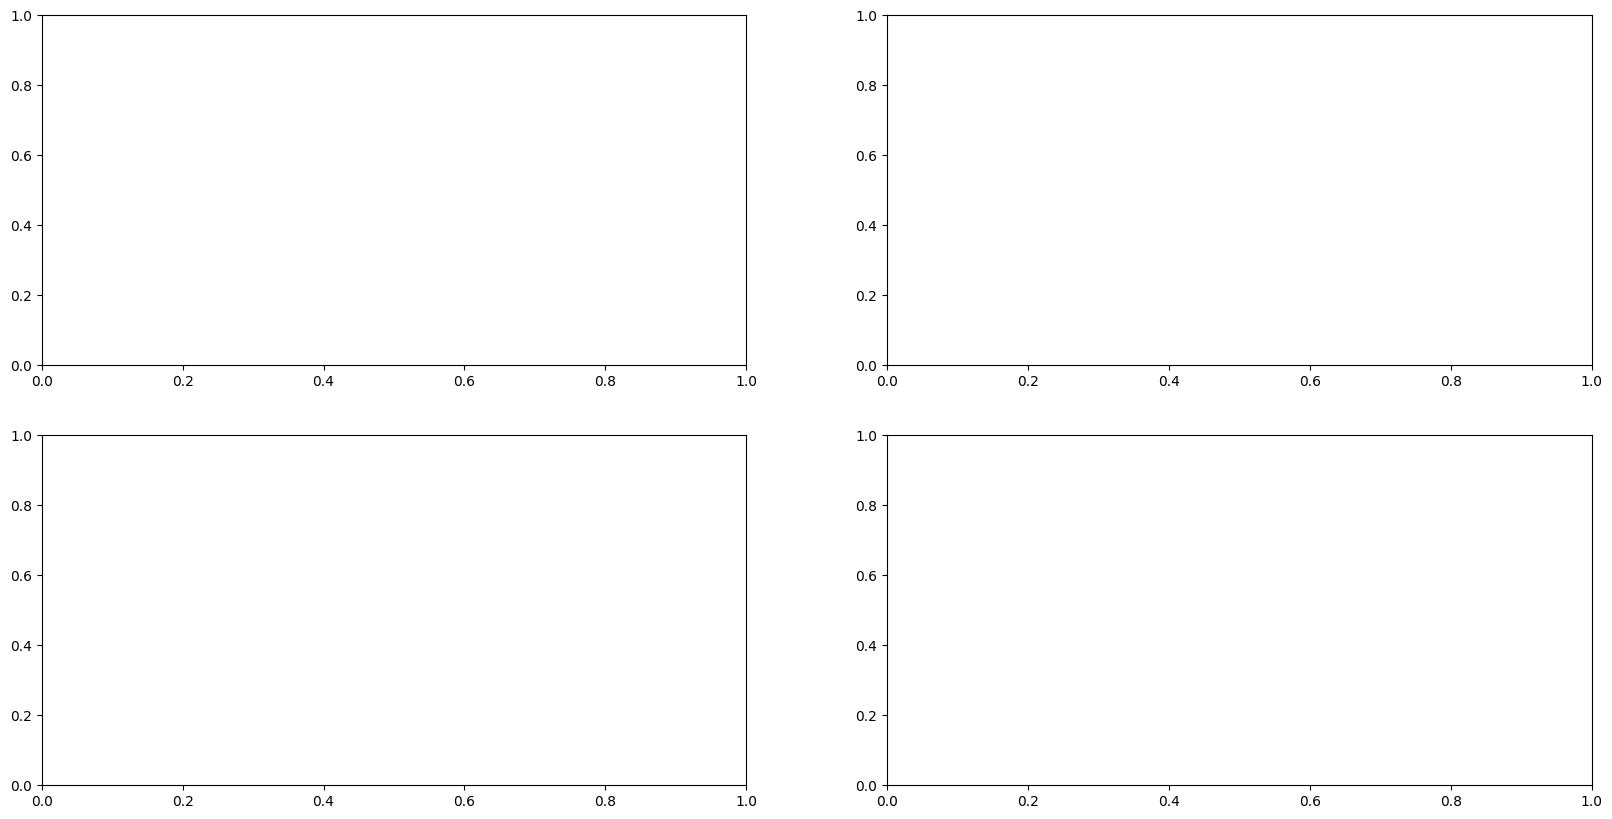

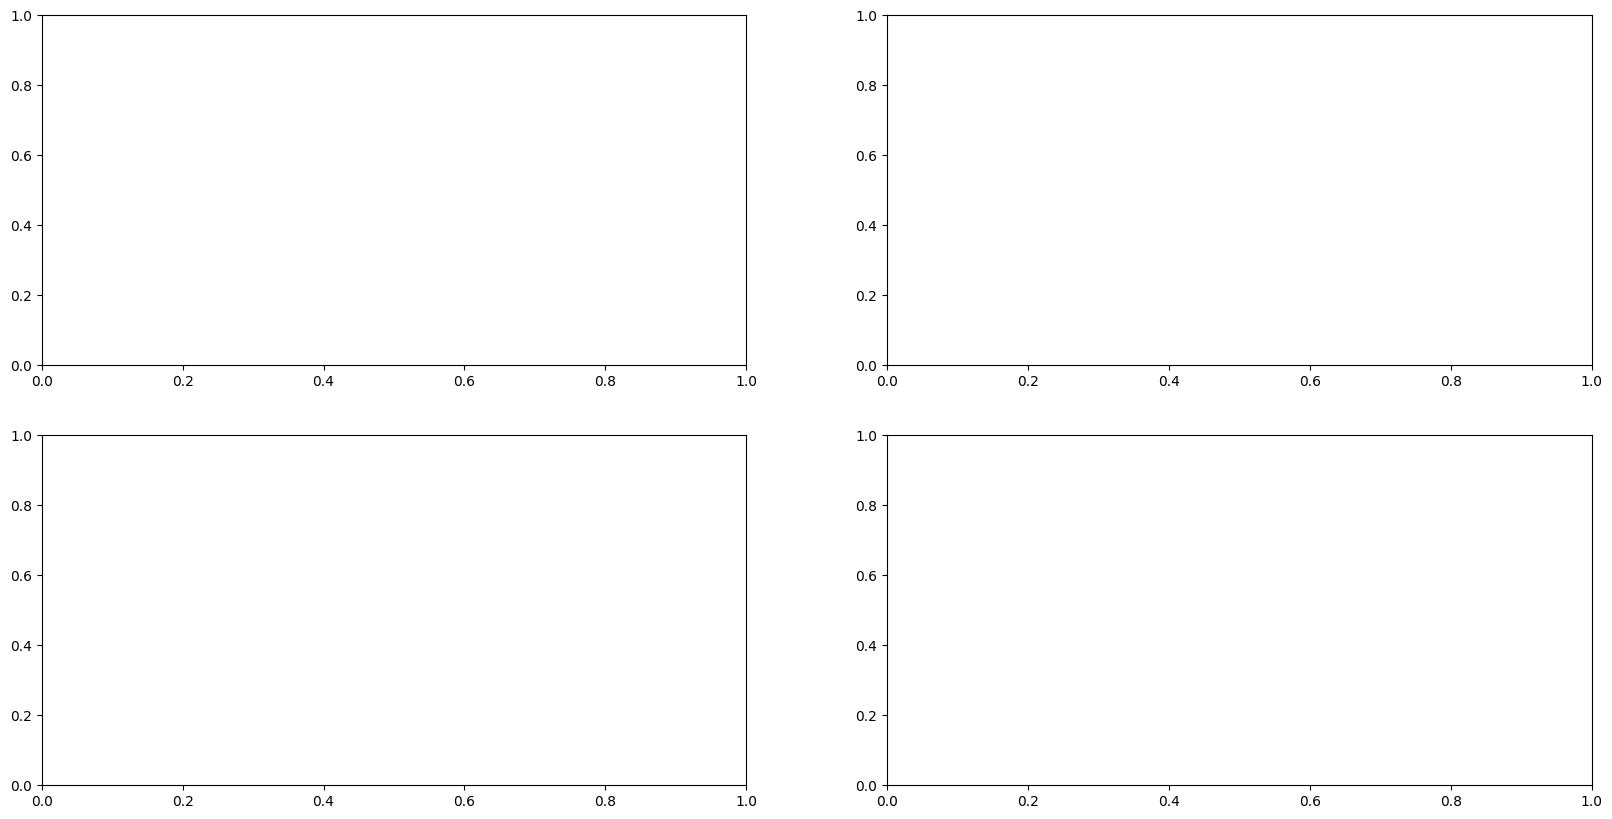

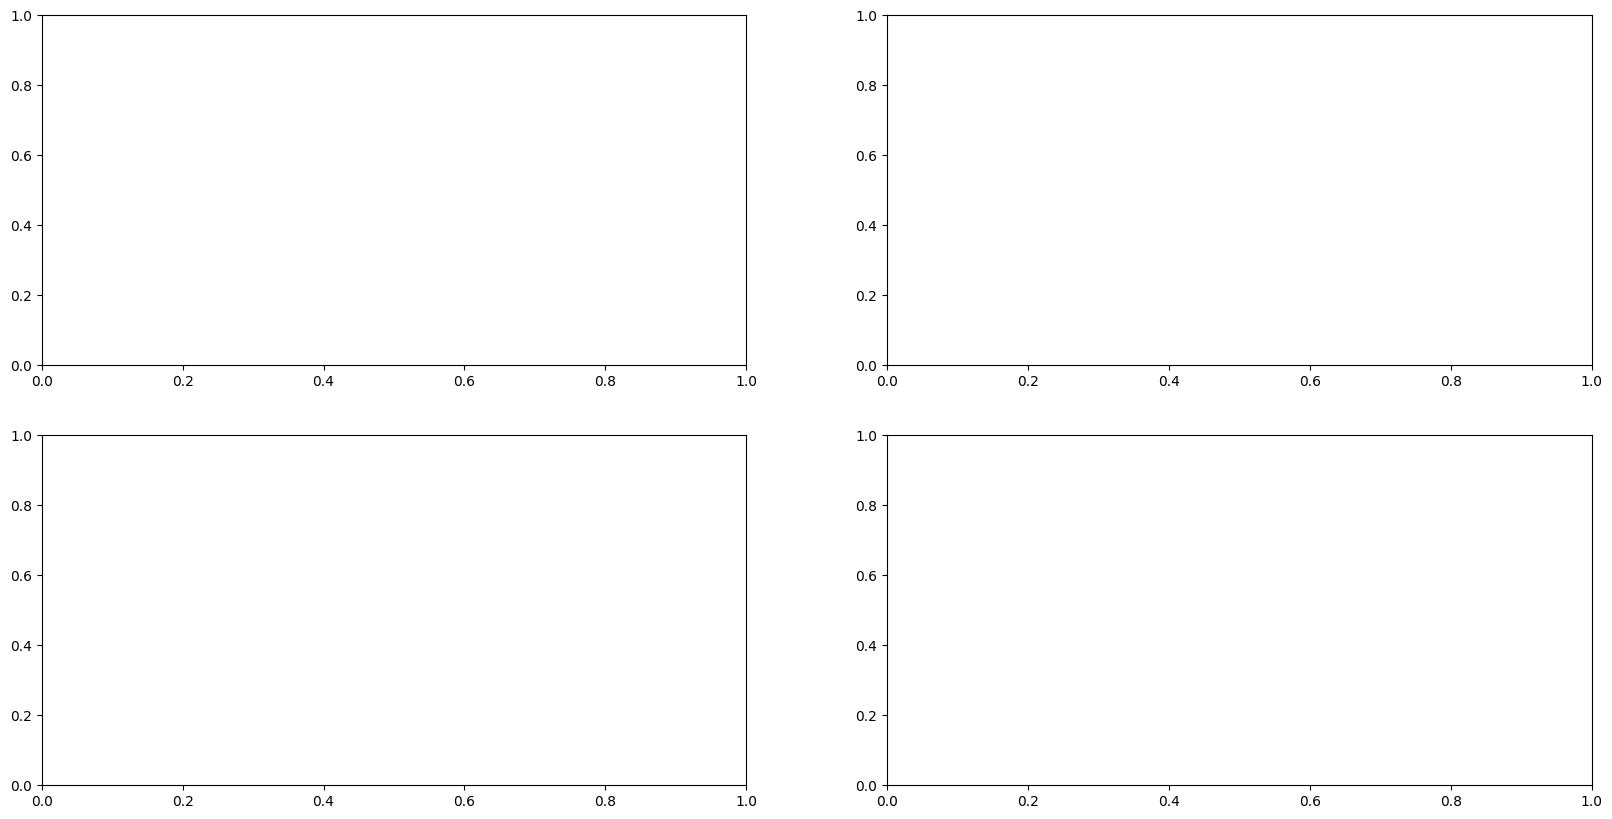

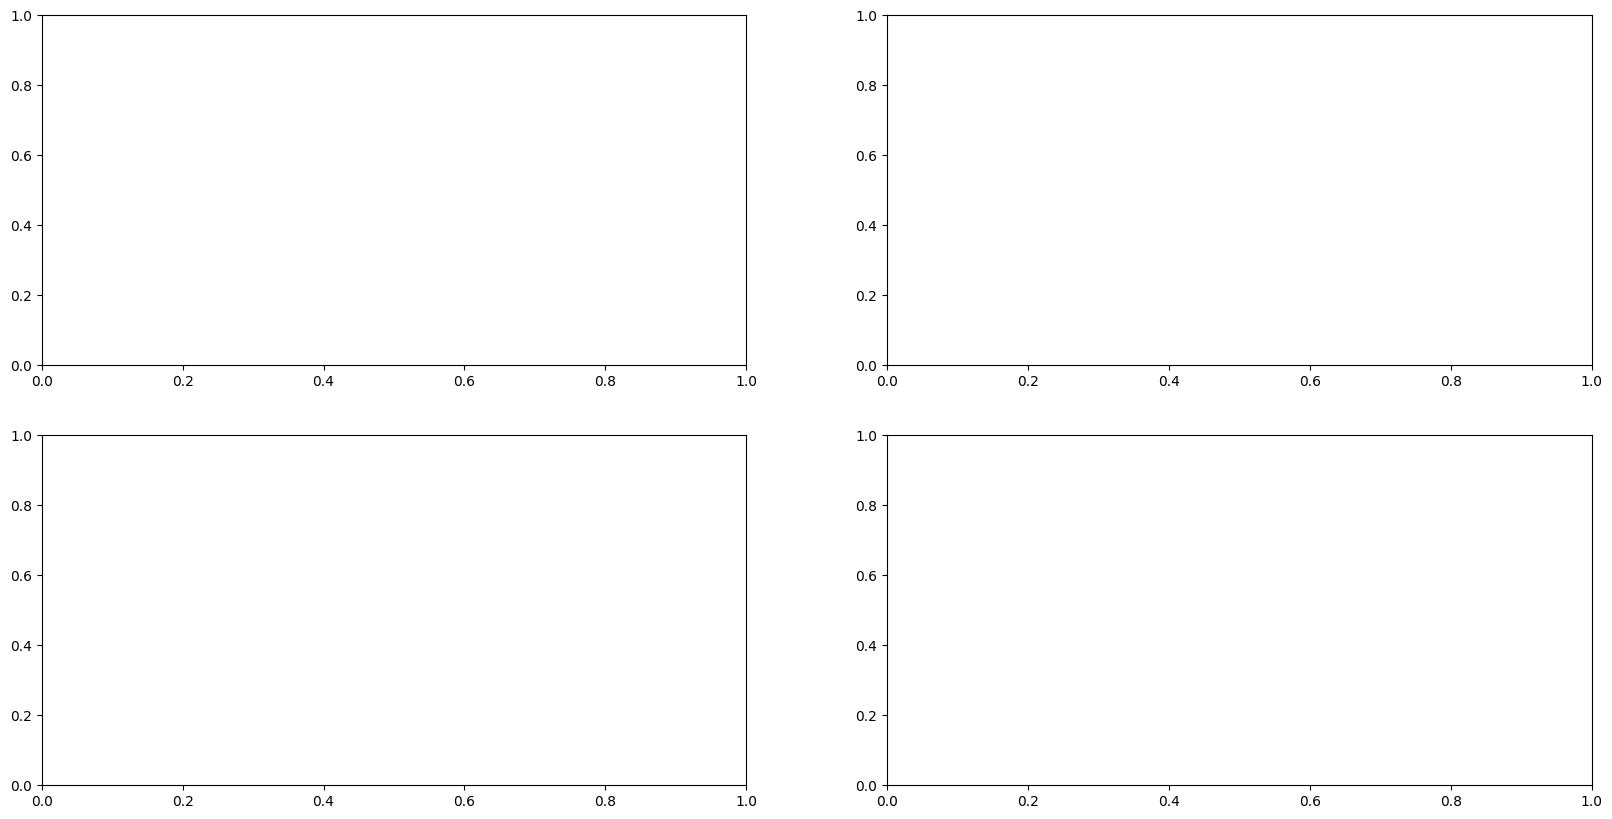

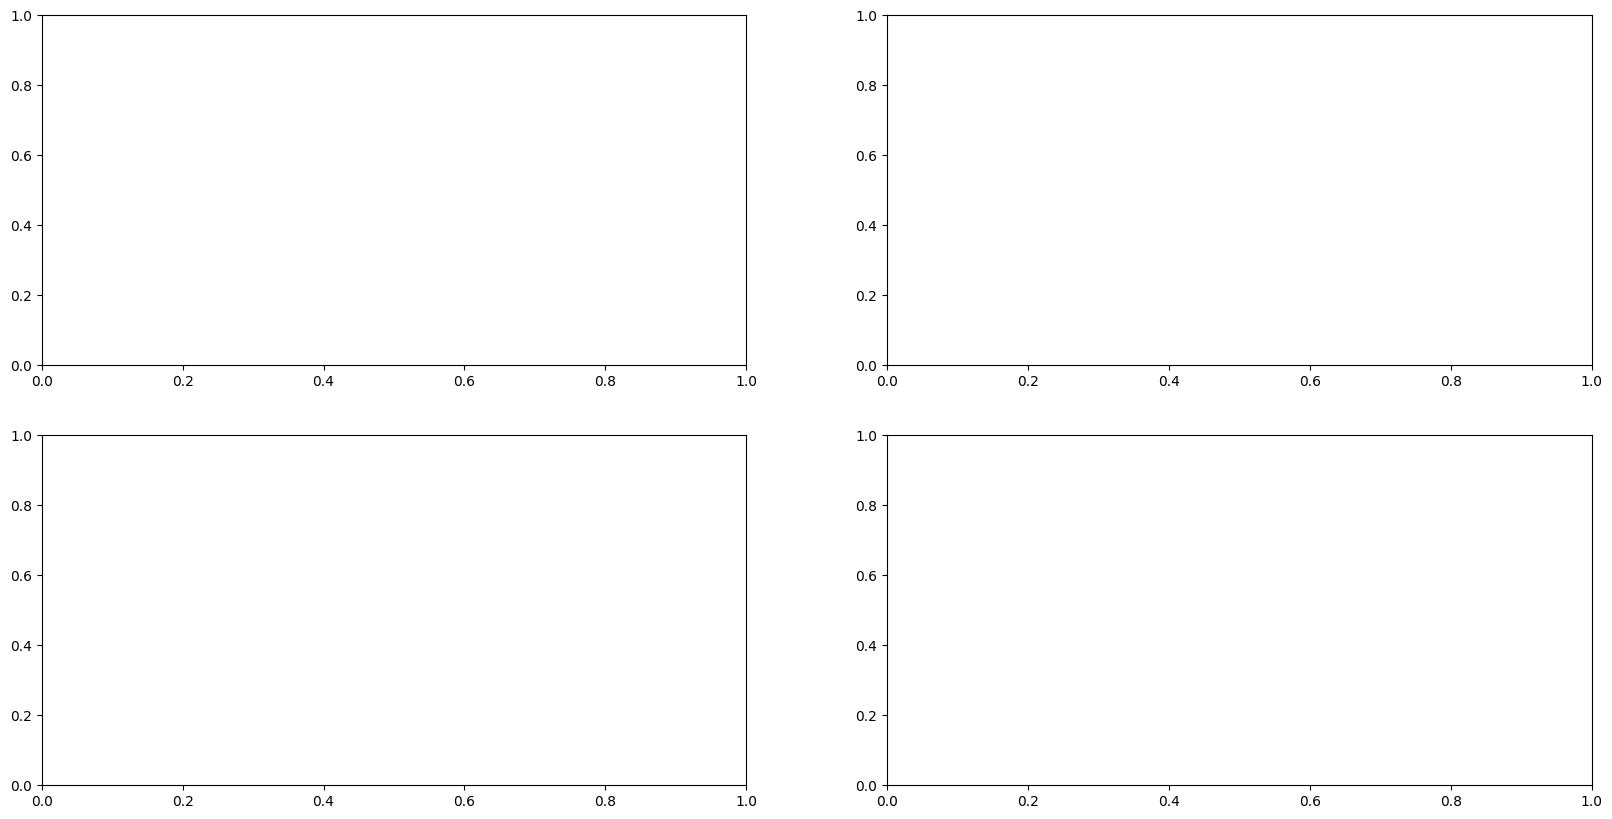

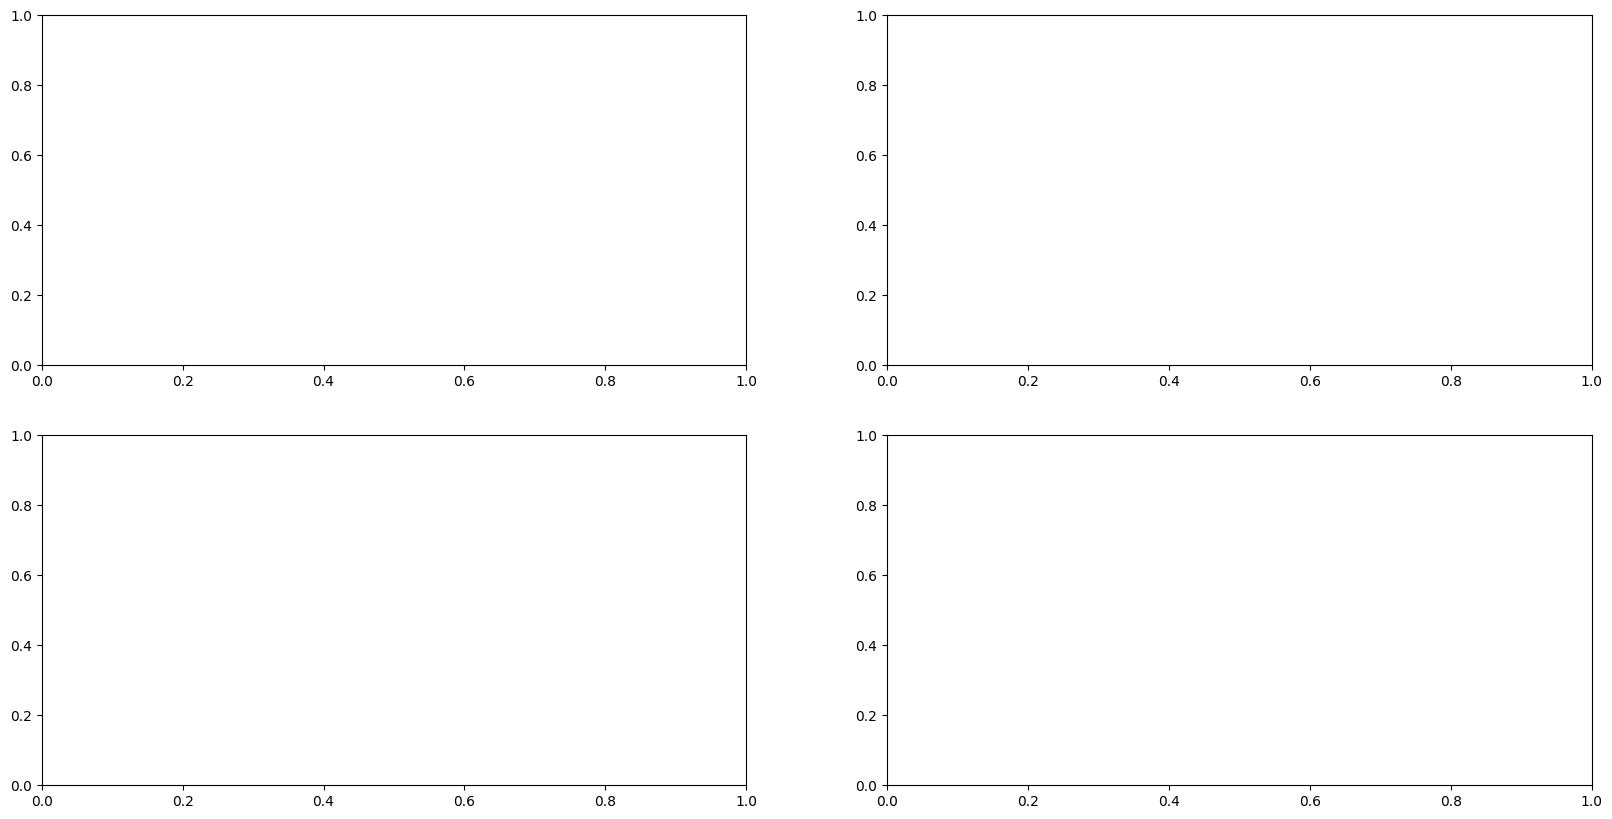

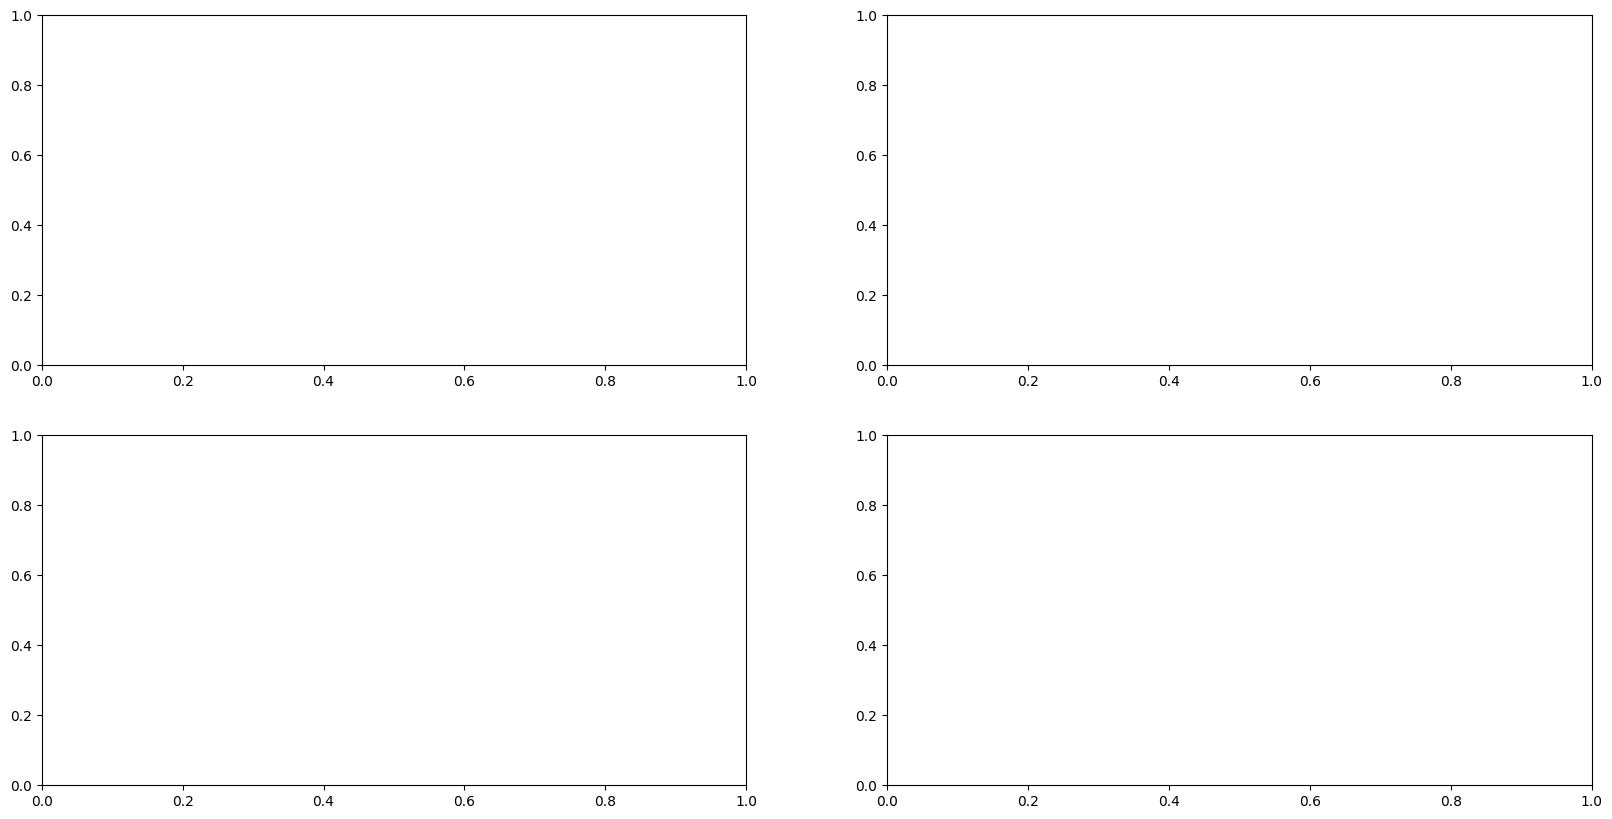

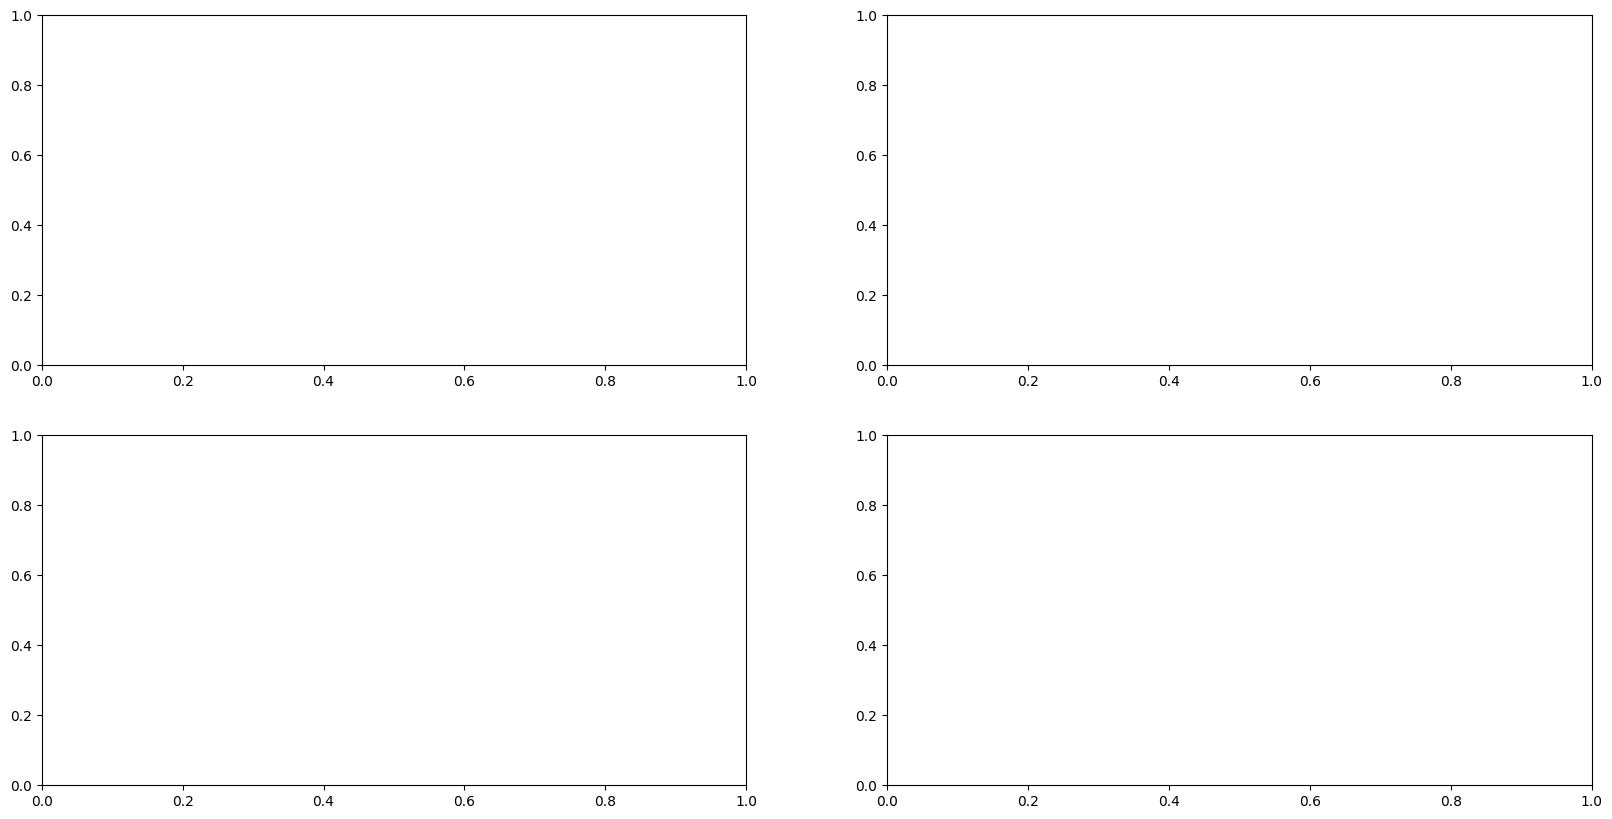

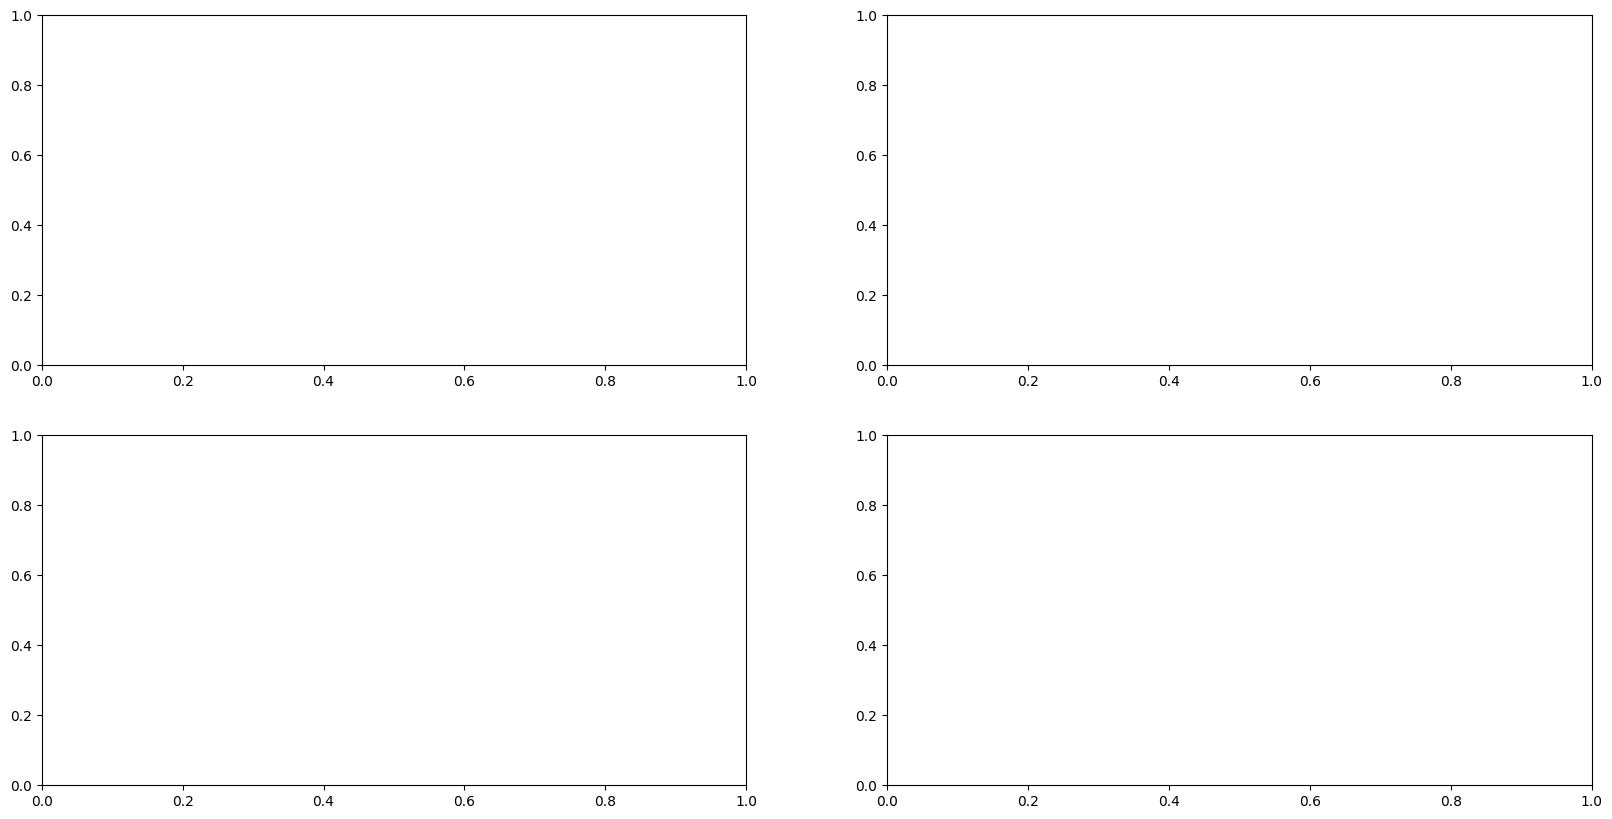

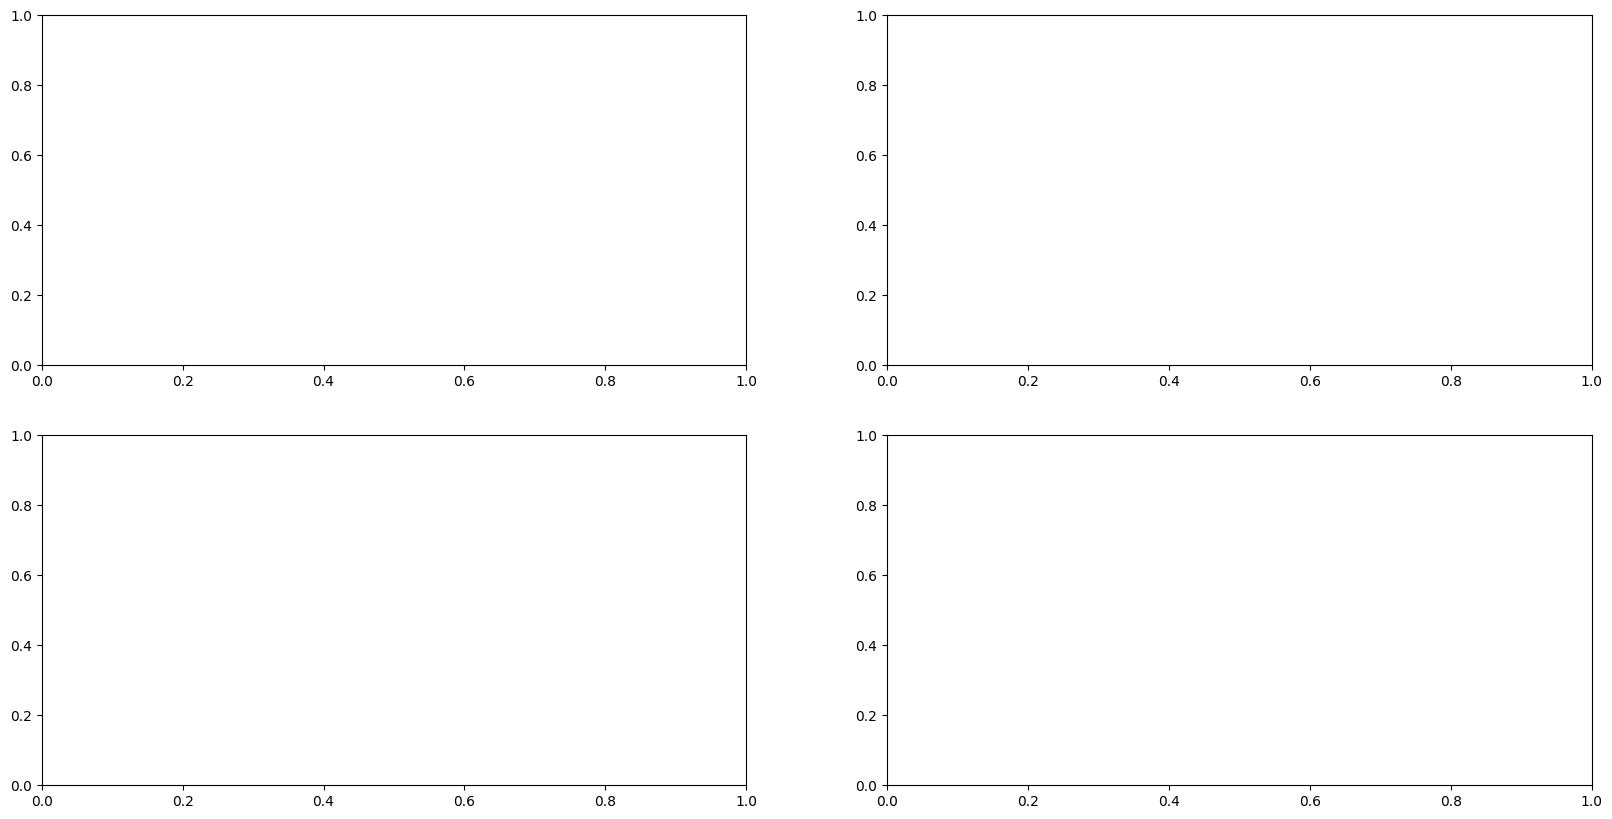

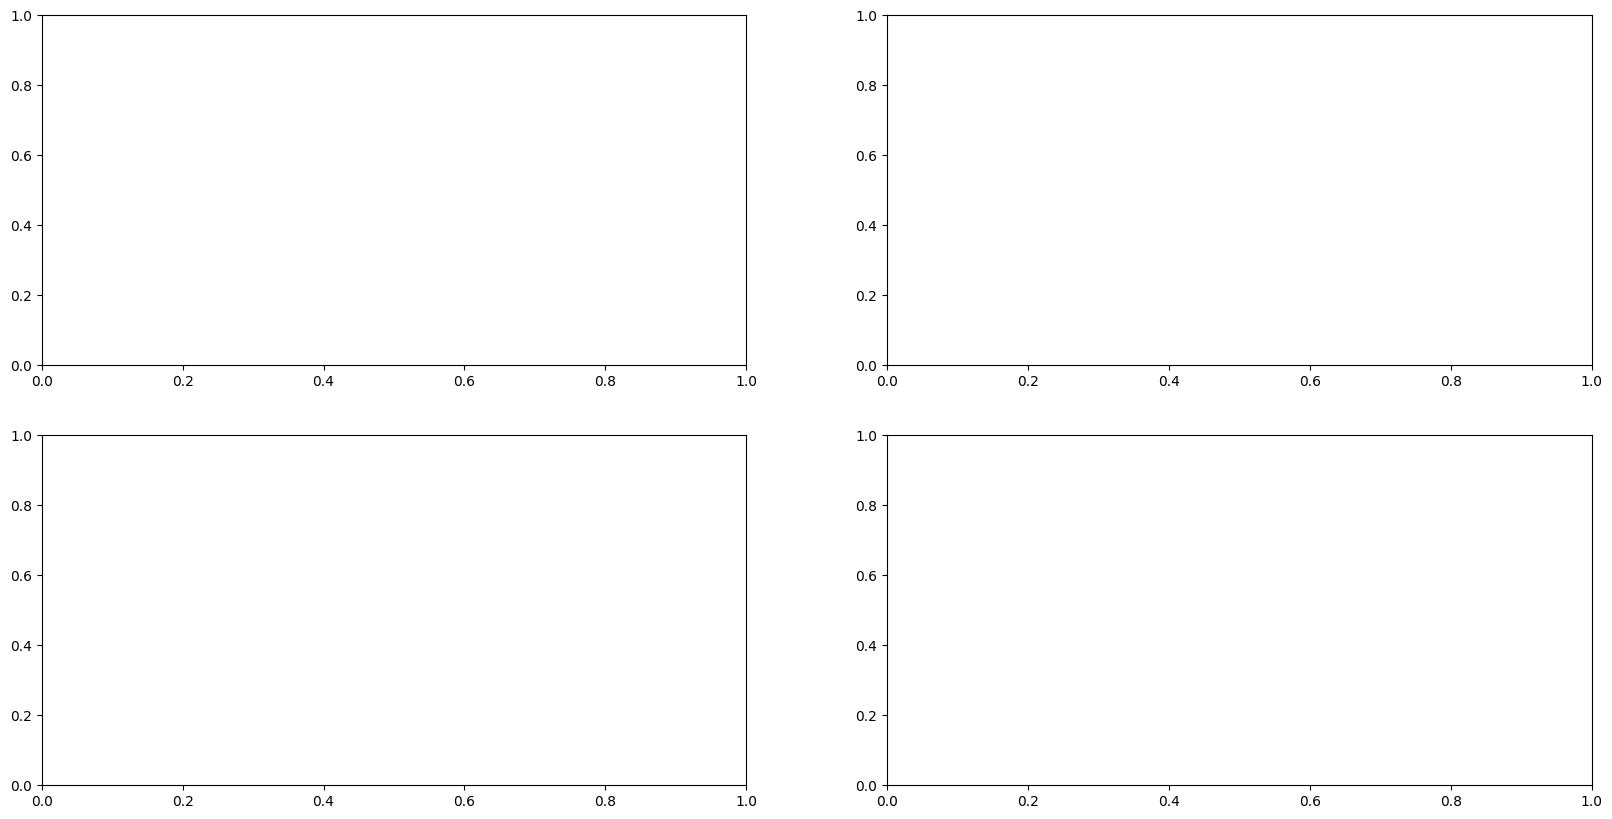

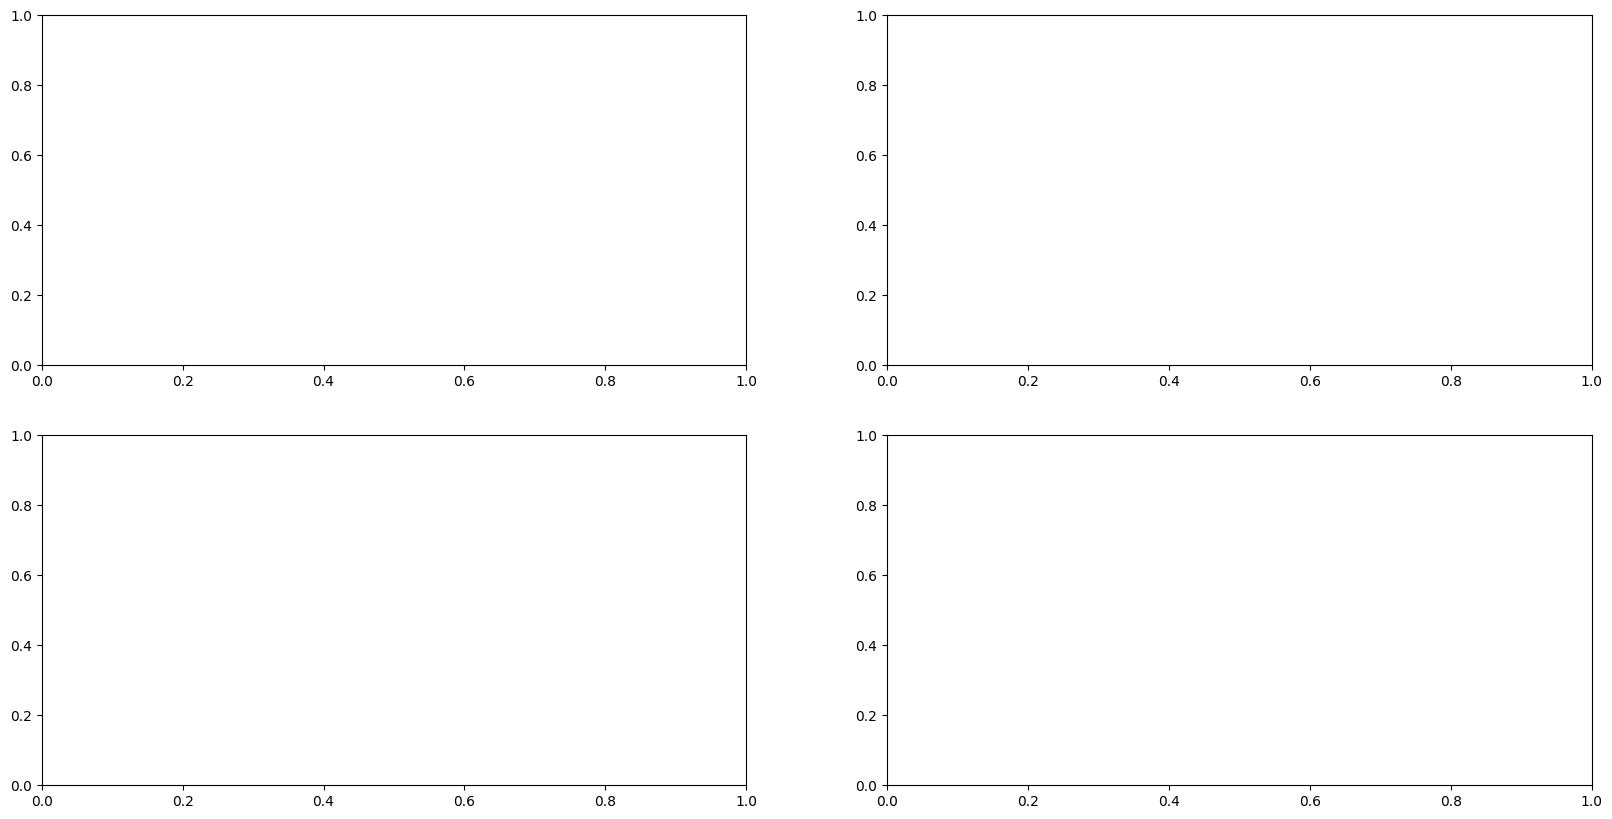

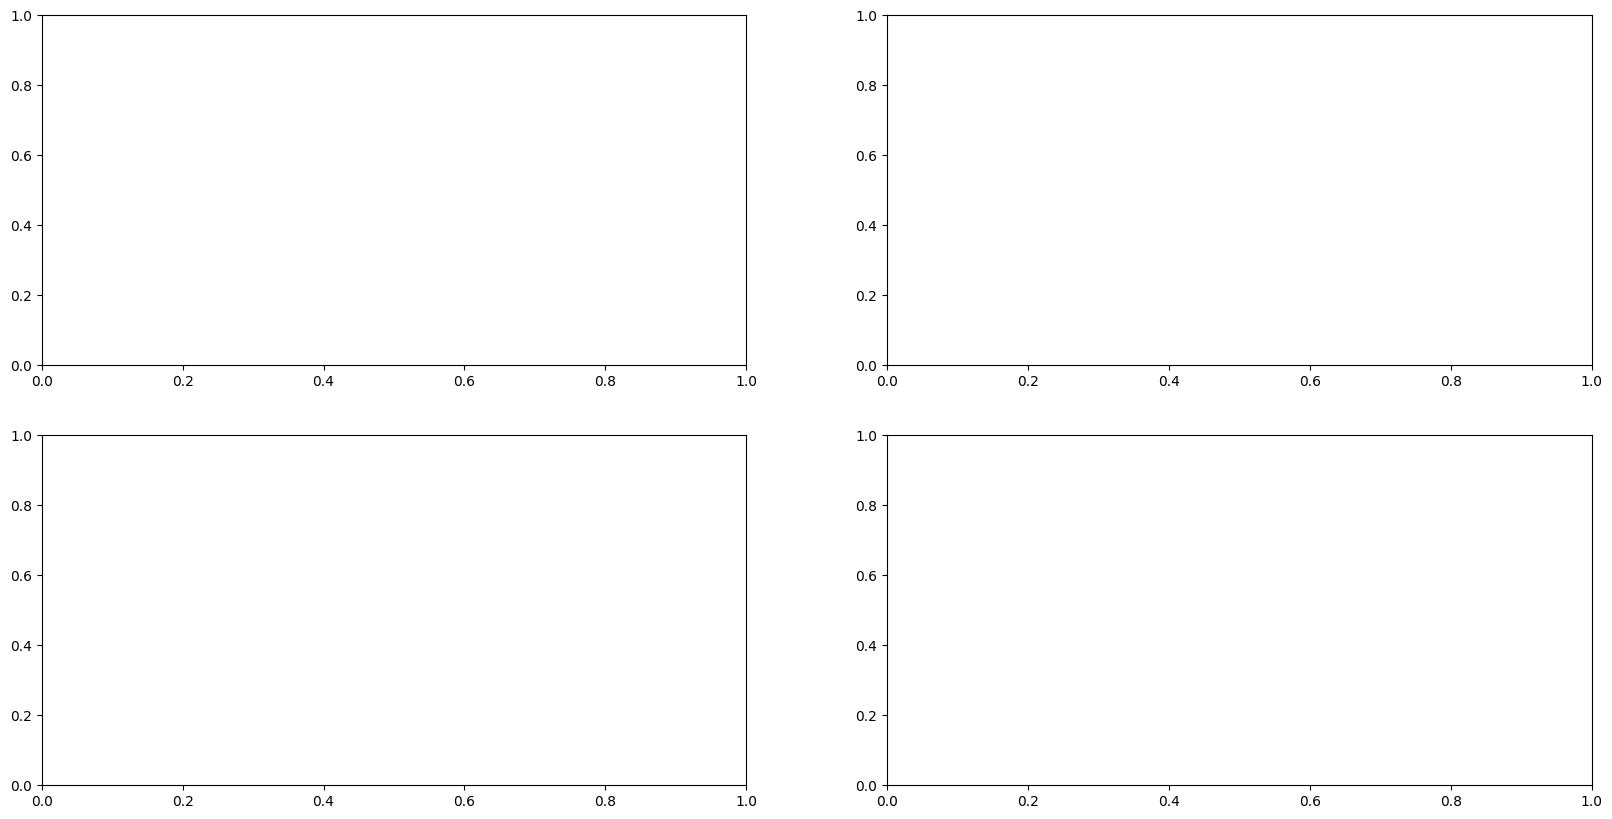

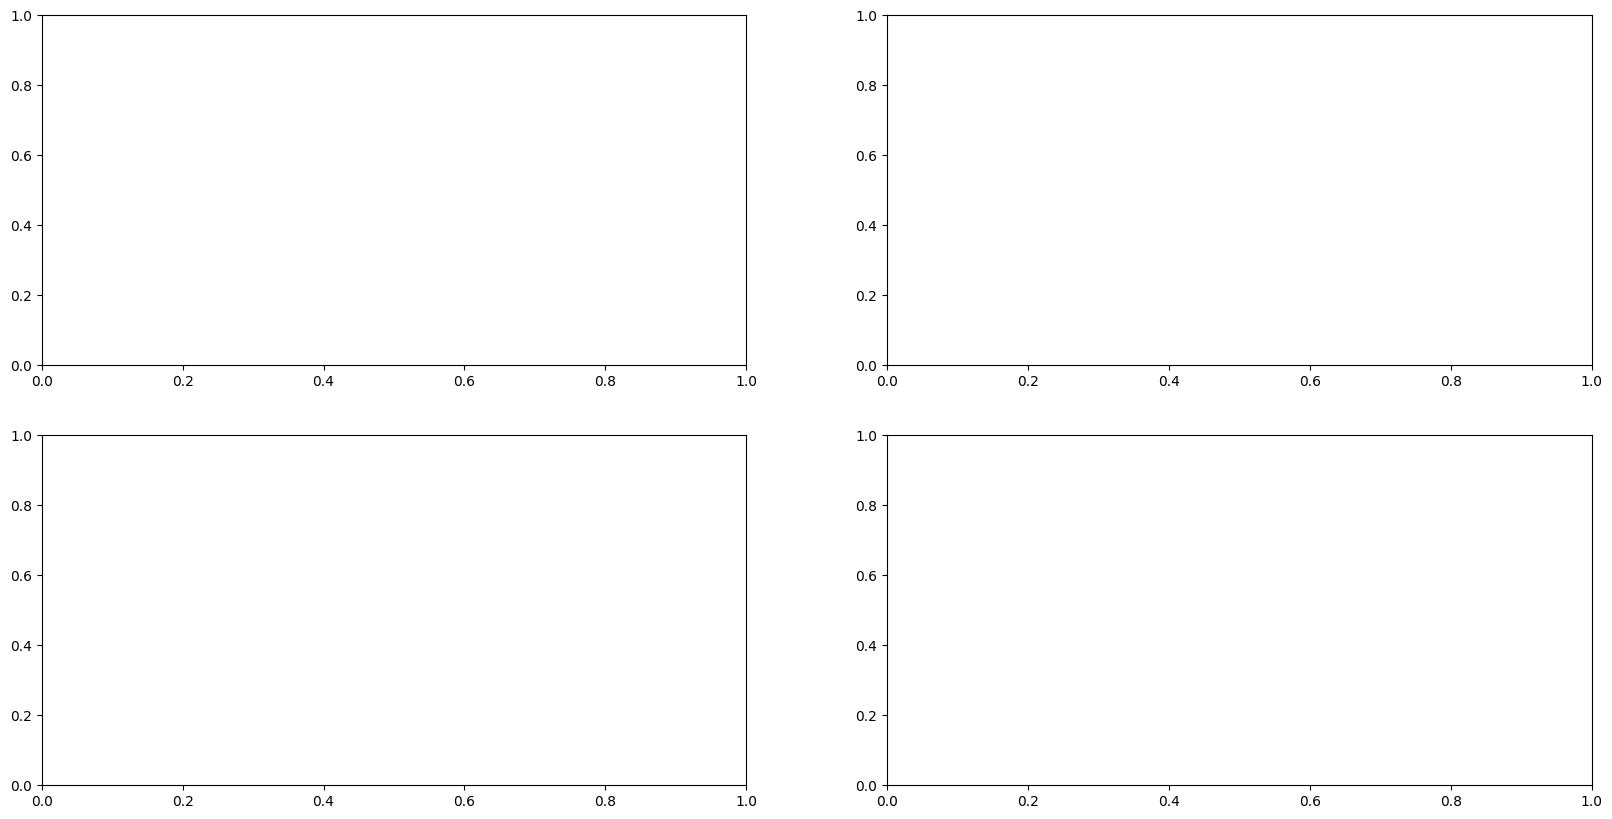

In [42]:
for name in station.keys():
    station_temp = deepcopy(df[df['NAME'] == src_name[name]])
    # station_temp = station_temp.drop(columns = ['NAME'],
    #                                  axis    = 1).reset_index()
    station_temp = station_temp.reset_index()
    station_temp = dataset.handle_feature_outliers_over_time(data              = station_temp,
                                                             data_cols         = numerical_features,
                                                             station_name      = name,
                                                             method            = "statistic",
                                                             metrics           = list([
                                                                                    #  "z_score",
                                                                                    #  "z_score modified",
                                                                                     "iqr",
                                                                                    #  "percentile",
                                                                                     ]),
                                                             display           = False,
                                                             z_thresh          = 3,    # Z_score
                                                             modified_z_thresh = 3.5,  # Z_score modified
                                                             k                 = 1.5,  # IQR
                                                             p_low             = 0.01, # Percentile
                                                             p_high            = 0.99, # Percentiled
                                                             step_size         = 1,    # Every day
                                                             threshold         = 0.10,
                                                             # start_time        = "1990-01-01 00:00:00+07:00",
                                                             # end_time          = "2025-01-01 00:00:00+07:00",
                                                             # freq              = "1H"
                                                             )
    station_temp = station_temp.set_index('time')
    df[df['NAME'] == src_name[name]] = station_temp

In [43]:
# dataset.compare_df(df_A = df_temp,
#                    df_B = df,
#                    key  = df.columns
#                    )

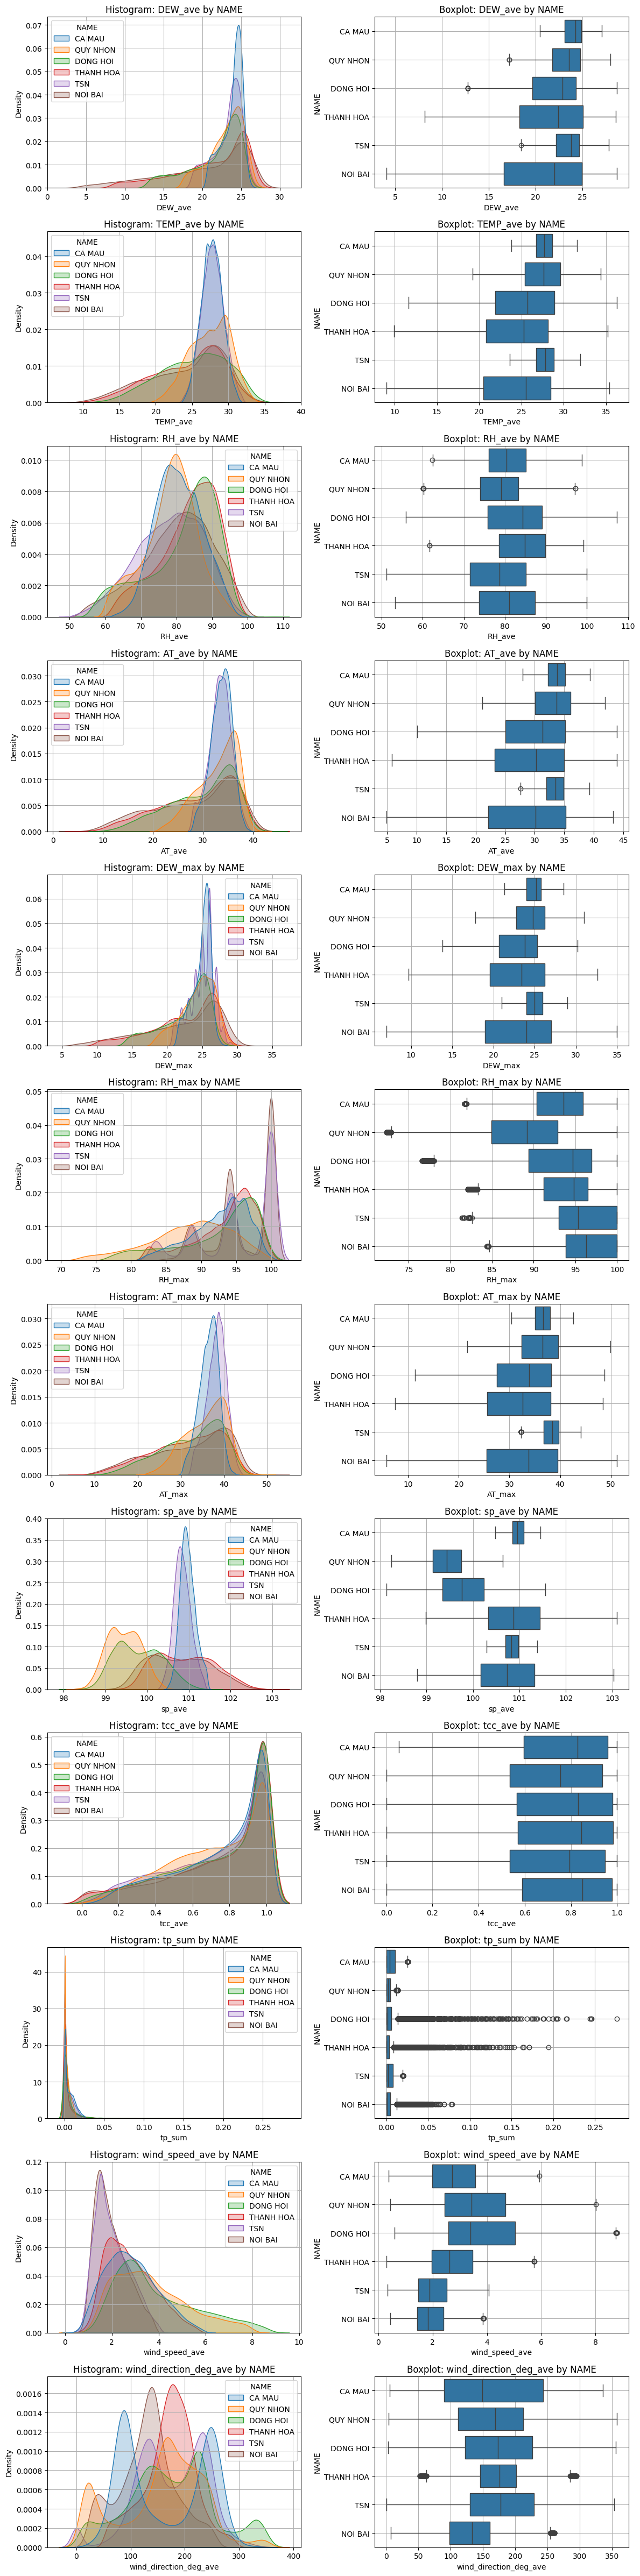

In [44]:
plots.plot_Outlier(data      = df,
                   data_cols = feature_col,
                   target    = "NAME")

##### <span style="color:tomato">Scaling numerical feature</span>

In [45]:
# Ép index của features_encoded và targets_encoded về dạng DatetimeIndex
features_encoded.index = pd.to_datetime(features_encoded.index)
targets_encoded.index  = pd.to_datetime(targets_encoded.index)

# Ép mốc thời gian về Timestamp (datetime)
# C1:
start_train = pd.Timestamp("1990-01-01 00:00:00")
end_train   = pd.Timestamp("2022-12-31 00:00:00")
start_test  = pd.Timestamp("2023-01-01 00:00:00")
end_test    = pd.Timestamp("2024-12-31 00:00:00")

# C2:
# idx = features_encoded.index
# split_idx = int(len(idx) * 0.8)
# start_train = idx[0]
# end_train   = idx[split_idx - 1]

# start_test  = idx[split_idx]
# end_test    = idx[-1]

# Tạo mask để lọc
train_mask = (features_encoded.index >= start_train) & (features_encoded.index <= pd.Timestamp("2020-12-31 00:00:00"))
valid_mask = (features_encoded.index >= pd.Timestamp("2021-01-01 00:00:00")) & (features_encoded.index <= end_train)
test_mask  = (features_encoded.index >= start_test) & (features_encoded.index <= end_test)

# Chia dữ liệu
X_train_encoded = features_encoded[train_mask]
X_valid_encoded = features_encoded[valid_mask]
X_test_encoded  = features_encoded[test_mask]

y_train_encoded = targets_encoded[train_mask]
y_valid_encoded = targets_encoded[valid_mask]
y_test_encoded  = targets_encoded[test_mask]

In [46]:
X_train_encoded[feature_col]

,DEW_ave,TEMP_ave,RH_ave,AT_ave,DEW_max,RH_max,AT_max,sp_ave,tcc_ave,tp_sum,wind_speed_ave,wind_direction_deg_ave
time,,,,,,,,,,,,
1990-01-01,21.760000,24.460000,85.710000,28.910000,22.2,92.950000,32.420000,101.080992,0.963329,0.000669,3.038102,81.611026
1990-01-01,20.920000,23.800000,84.435950,27.706273,21.4,92.279648,31.230500,99.714036,0.400093,0.000425,2.383495,164.361671
1990-01-01,18.750000,20.280000,90.940000,22.890000,19.5,94.570000,24.040000,100.064575,0.796282,0.000511,1.422625,158.100468
1990-01-01,20.400000,22.000000,90.641837,25.582248,20.4,90.641837,25.582248,101.251524,0.999033,0.000457,2.537301,174.652701
1990-01-01,21.175758,27.027273,71.463133,31.087169,23.0,88.507803,35.566200,100.972871,0.499631,0.000034,1.601291,150.244327
...,...,...,...,...,...,...,...,...,...,...,...,...
2020-12-31,2.440000,13.060000,50.320000,10.460000,5.0,71.070000,15.250000,102.408440,0.596290,0.000000,2.549802,70.927018
2020-12-31,12.360000,16.090000,78.770000,15.680000,13.6,88.300000,17.770000,101.016927,0.988707,0.011418,8.504080,16.848851
2020-12-31,15.916667,25.937500,54.538774,27.009338,17.0,64.906839,30.089800,101.046627,0.984432,0.008686,2.979479,54.656208


In [47]:
y_train_encoded

,NAME,TEMP_max
time,,
1990-01-01,CA MAU,28.3
1990-01-01,QUY NHON,27.3
1990-01-01,DONG HOI,21.3
1990-01-01,THANH HOA,22.0
1990-01-01,TSN,32.0
...,...,...
2020-12-31,NOI BAI,18.0
2020-12-31,DONG HOI,17.9
2020-12-31,TSN,29.0


In [48]:
print(feature_col)
print(X_train_encoded[feature_col].shape, y_train_encoded.shape)
print(X_valid_encoded[feature_col].shape, y_valid_encoded.shape)
print(X_test_encoded[feature_col].shape, y_test_encoded.shape)

['DEW_ave', 'TEMP_ave', 'RH_ave', 'AT_ave', 'DEW_max', 'RH_max', 'AT_max', 'sp_ave', 'tcc_ave', 'tp_sum', 'wind_speed_ave', 'wind_direction_deg_ave']
(67938, 12) (67938, 2)
(4380, 12) (4380, 2)
(4386, 12) (4386, 2)


In [49]:
scaler = MinMaxScaler()
scaler.fit(X_train_encoded[feature_col])

# Train
X_train_encoded_before = X_train_encoded[feature_col].copy()
X_train_encoded_after  = scaler.transform(X_train_encoded_before)

# Valid
X_valid_encoded_before = X_valid_encoded[feature_col].copy()
X_valid_encoded_after  = scaler.transform(X_valid_encoded_before)

# Test
X_test_encoded_before  = X_test_encoded[feature_col].copy()
X_test_encoded_after   = scaler.transform(X_test_encoded_before)

# Cast np.ndarray to pd.Dataframe
X_train_encoded_after = pd.DataFrame(data    = X_train_encoded_after, 
                                     index   = X_train_encoded.index, 
                                     columns = feature_col)
X_valid_encoded_after = pd.DataFrame(data    = X_valid_encoded_after, 
                                     index   = X_valid_encoded.index, 
                                     columns = feature_col)
X_test_encoded_after  = pd.DataFrame(data    = X_test_encoded_after,  
                                     index   = X_test_encoded.index,  
                                     columns = feature_col)

In [50]:
X_train_encoded_before.shape, X_valid_encoded_before.shape, X_test_encoded_before.shape

((67938, 12), (4380, 12), (4386, 12))

In [51]:
X_train_encoded_after.shape, X_valid_encoded_after.shape, X_test_encoded_after.shape

((67938, 12), (4380, 12), (4386, 12))

In [52]:
X_train_encoded_after = pd.DataFrame(X_train_encoded_after, index=X_train_encoded.index, columns=feature_col)
X_valid_encoded_after = pd.DataFrame(X_valid_encoded_after, index=X_valid_encoded.index, columns=feature_col)
X_test_encoded_after  = pd.DataFrame(X_test_encoded_after,  index=X_test_encoded.index,  columns=feature_col)

features_encoded_after = pd.concat([X_train_encoded_after, X_valid_encoded_after, X_test_encoded_after])

features_encoded[feature_col] = features_encoded_after
features_encoded

,NAME,LATITUDE,LONGITUDE,DEW_ave,TEMP_ave,RH_ave,AT_ave,DEW_max,RH_max,AT_max,sp_ave,tcc_ave,tp_sum,wind_speed_ave,wind_direction_deg_ave
time,,,,,,,,,,,,,,,
1990-01-01,CA MAU,9.183333,105.150000,0.743911,0.594807,0.729682,0.619632,0.602484,0.902959,0.593596,0.593313,0.963329,0.002421,0.237746,0.220669
1990-01-01,QUY NHON,13.766667,109.216667,0.712915,0.572258,0.713753,0.589169,0.577640,0.893732,0.567910,0.317719,0.400093,0.001539,0.181120,0.454307
1990-01-01,DONG HOI,17.483000,106.600000,0.632841,0.451999,0.795074,0.467283,0.518634,0.925258,0.412636,0.388392,0.796282,0.001851,0.098001,0.436629
1990-01-01,THANH HOA,19.750000,105.783333,0.693727,0.510762,0.791346,0.535416,0.546584,0.871188,0.445940,0.627695,0.999033,0.001653,0.194425,0.483362
1990-01-01,TSN,10.818797,106.651856,0.722353,0.682517,0.551552,0.674730,0.627329,0.841814,0.661536,0.571515,0.499631,0.000121,0.113457,0.414448
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2024-12-31,NOI BAI,21.221192,105.807178,0.369742,0.327639,0.586897,0.292663,0.347826,1.000000,0.330362,0.734342,0.607103,0.000246,0.157860,0.494968
2024-12-31,TSN,10.818797,106.651856,0.726630,0.697956,0.527709,0.688689,0.658385,0.845124,0.676404,0.579390,0.817102,0.000077,0.107063,-0.008863
2024-12-31,CA MAU,9.183333,105.150000,0.833948,0.681927,0.721805,0.727947,0.726708,0.944253,0.661834,0.604153,0.988316,0.000058,0.122851,0.903306


#### <span style="color:green">4.5. Save data</span>

Scaler

In [53]:
# Tạo thư mục nếu chưa tồn tại
os.makedirs(os.path.dirname(model_path), exist_ok=True)

# Lưu model
joblib.dump(value    = scaler, 
            filename = model_path.replace("trained_models","checkpoints") + "scaler.pkl",
            # compress = True
            )
print(f"Scaler đã được lưu tại: {model_path.replace('trained_models','checkpoints')}")

Scaler đã được lưu tại: ../../models/checkpoints/ML/XGBOOST/


Data

In [54]:
# Check so dong
print(features_encoded.shape)
print(targets_encoded.shape)

(76704, 15)
(76704, 2)


In [55]:
# Reset index
# df_reset         = df.loc[features_encoded.index].reset_index()
# features_encoded = features_encoded.reset_index(drop=True)
# targets_df       = pd.DataFrame(targets_encoded, columns=["TEMP_max"]).reset_index(drop=True)

# Thay thế giá trị ở các cột trùng trong df_reset bằng features_encoded
# df_reset[features_encoded.columns] = features_encoded[features_encoded.columns]

# # Tương tự 
# df_reset[targets_df.columns] = targets_df[targets_df.columns]

df = pd.concat([features_encoded,targets_encoded["TEMP_max"]],axis=1).reset_index()

# Lưu file
os.makedirs("../../data/processed/datasets_encoded/", exist_ok=True)
# file_name = f"../../data/processed/datasets_encoded/{station_name}_90.24_encoded.csv"
file_name = f"../../data/processed/datasets_encoded/all_area_90.24_encoded.csv"
df.to_csv(file_name, index=False)
print(f"✅ Đã lưu: {file_name}")

✅ Đã lưu: ../../data/processed/datasets_encoded/all_area_90.24_encoded.csv


In [56]:
df

,time,NAME,LATITUDE,LONGITUDE,DEW_ave,TEMP_ave,RH_ave,AT_ave,DEW_max,RH_max,AT_max,sp_ave,tcc_ave,tp_sum,wind_speed_ave,wind_direction_deg_ave,TEMP_max
0,1990-01-01,CA MAU,9.183333,105.150000,0.743911,0.594807,0.729682,0.619632,0.602484,0.902959,0.593596,0.593313,0.963329,0.002421,0.237746,0.220669,28.3
1,1990-01-01,QUY NHON,13.766667,109.216667,0.712915,0.572258,0.713753,0.589169,0.577640,0.893732,0.567910,0.317719,0.400093,0.001539,0.181120,0.454307,27.3
2,1990-01-01,DONG HOI,17.483000,106.600000,0.632841,0.451999,0.795074,0.467283,0.518634,0.925258,0.412636,0.388392,0.796282,0.001851,0.098001,0.436629,21.3
3,1990-01-01,THANH HOA,19.750000,105.783333,0.693727,0.510762,0.791346,0.535416,0.546584,0.871188,0.445940,0.627695,0.999033,0.001653,0.194425,0.483362,22.0
4,1990-01-01,TSN,10.818797,106.651856,0.722353,0.682517,0.551552,0.674730,0.627329,0.841814,0.661536,0.571515,0.499631,0.000121,0.113457,0.414448,32.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
76699,2024-12-31,NOI BAI,21.221192,105.807178,0.369742,0.327639,0.586897,0.292663,0.347826,1.000000,0.330362,0.734342,0.607103,0.000246,0.157860,0.494968,21.0
76700,2024-12-31,TSN,10.818797,106.651856,0.726630,0.697956,0.527709,0.688689,0.658385,0.845124,0.676404,0.579390,0.817102,0.000077,0.107063,-0.008863,31.0
76701,2024-12-31,CA MAU,9.183333,105.150000,0.833948,0.681927,0.721805,0.727947,0.726708,0.944253,0.661834,0.604153,0.988316,0.000058,0.122851,0.903306,29.6
76702,2024-12-31,QUY NHON,13.766667,109.216667,0.576107,0.511616,0.587679,0.490130,0.515528,0.803346,0.430644,0.352407,1.000000,0.048281,0.628583,0.995123,22.2


### <span style="color:orange">5.Model</span>

#### <span style="color:green">5.1. Loading the dataset</span>

In [57]:
# src_encoded = dict({"CaMau" : "../../data/processed/datasets_encoded/CaMau_90.24_encoded.csv",
#                     "DH"    : "../../data/processed/datasets_encoded/DH_90.24_encoded.csv",
#                     "NB"    : "../../data/processed/datasets_encoded/NB_90.24_encoded.csv",
#                     "QN"    : "../../data/processed/datasets_encoded/QN_90.24_encoded.csv",
#                     "TH"    : "../../data/processed/datasets_encoded/TH_90.24_encoded.csv",
#                     "TSN"   : "../../data/processed/datasets_encoded/TSN_90.24_encoded.csv"})
src_encoded = dict({"all" : "../../data/processed/datasets_encoded/all_area_90.24_encoded.csv"})

In [58]:
df               = pd.read_csv(filepath_or_buffer = src_encoded['all'],
                               parse_dates        = True,
                            #    nrows              = nrows,
                               index_col          = "time")
targets_encoded  = df[['NAME',"TEMP_max"]]
features_encoded = df.drop(columns = ["TEMP_max"])

In [59]:
features_encoded[feature_col]

,DEW_ave,TEMP_ave,RH_ave,AT_ave,DEW_max,RH_max,AT_max,sp_ave,tcc_ave,tp_sum,wind_speed_ave,wind_direction_deg_ave
time,,,,,,,,,,,,
1990-01-01,0.743911,0.594807,0.729682,0.619632,0.602484,0.902959,0.593596,0.593313,0.963329,0.002421,0.237746,0.220669
1990-01-01,0.712915,0.572258,0.713753,0.589169,0.577640,0.893732,0.567910,0.317719,0.400093,0.001539,0.181120,0.454307
1990-01-01,0.632841,0.451999,0.795074,0.467283,0.518634,0.925258,0.412636,0.388392,0.796282,0.001851,0.098001,0.436629
1990-01-01,0.693727,0.510762,0.791346,0.535416,0.546584,0.871188,0.445940,0.627695,0.999033,0.001653,0.194425,0.483362
1990-01-01,0.722353,0.682517,0.551552,0.674730,0.627329,0.841814,0.661536,0.571515,0.499631,0.000121,0.113457,0.414448
...,...,...,...,...,...,...,...,...,...,...,...,...
2024-12-31,0.369742,0.327639,0.586897,0.292663,0.347826,1.000000,0.330362,0.734342,0.607103,0.000246,0.157860,0.494968
2024-12-31,0.726630,0.697956,0.527709,0.688689,0.658385,0.845124,0.676404,0.579390,0.817102,0.000077,0.107063,-0.008863
2024-12-31,0.833948,0.681927,0.721805,0.727947,0.726708,0.944253,0.661834,0.604153,0.988316,0.000058,0.122851,0.903306


In [60]:
targets_encoded

,NAME,TEMP_max
time,,
1990-01-01,CA MAU,28.3
1990-01-01,QUY NHON,27.3
1990-01-01,DONG HOI,21.3
1990-01-01,THANH HOA,22.0
1990-01-01,TSN,32.0
...,...,...
2024-12-31,NOI BAI,21.0
2024-12-31,TSN,31.0
2024-12-31,CA MAU,29.6


#### <span style="color:green">5.2. Splitting the dataset</span>

In [61]:
# Ép index của features_encoded và targets_encoded về dạng DatetimeIndex
features_encoded.index = pd.to_datetime(features_encoded.index)
targets_encoded.index  = pd.to_datetime(targets_encoded.index)

# Ép mốc thời gian về Timestamp (datetime)
# C1:
start_train = pd.Timestamp("1990-01-01 00:00:00")
end_train   = pd.Timestamp("2022-12-31 00:00:00")
start_test  = pd.Timestamp("2023-01-01 00:00:00")
end_test    = pd.Timestamp("2024-12-31 00:00:00")

# C2:
# idx = features_encoded.index
# split_idx = int(len(idx) * 0.8)
# start_train = idx[0]
# end_train   = idx[split_idx - 1]

# start_test  = idx[split_idx]
# end_test    = idx[-1]

# Tạo mask để lọc
train_mask = (features_encoded.index >= start_train) & (features_encoded.index <= pd.Timestamp("2020-12-31 00:00:00"))
valid_mask = (features_encoded.index >= pd.Timestamp("2021-01-01 00:00:00")) & (features_encoded.index <= end_train)
test_mask  = (features_encoded.index >= start_test) & (features_encoded.index <= end_test)

# Chia dữ liệu
X_train_encoded = features_encoded[train_mask]
X_valid_encoded = features_encoded[valid_mask]
X_test_encoded  = features_encoded[test_mask]

y_train_encoded = targets_encoded[train_mask]
y_valid_encoded = targets_encoded[valid_mask]
y_test_encoded  = targets_encoded[test_mask]

In [62]:
X_train_encoded[feature_col]

,DEW_ave,TEMP_ave,RH_ave,AT_ave,DEW_max,RH_max,AT_max,sp_ave,tcc_ave,tp_sum,wind_speed_ave,wind_direction_deg_ave
time,,,,,,,,,,,,
1990-01-01,0.743911,0.594807,0.729682,0.619632,0.602484,0.902959,0.593596,0.593313,0.963329,0.002421,0.237746,0.220669
1990-01-01,0.712915,0.572258,0.713753,0.589169,0.577640,0.893732,0.567910,0.317719,0.400093,0.001539,0.181120,0.454307
1990-01-01,0.632841,0.451999,0.795074,0.467283,0.518634,0.925258,0.412636,0.388392,0.796282,0.001851,0.098001,0.436629
1990-01-01,0.693727,0.510762,0.791346,0.535416,0.546584,0.871188,0.445940,0.627695,0.999033,0.001653,0.194425,0.483362
1990-01-01,0.722353,0.682517,0.551552,0.674730,0.627329,0.841814,0.661536,0.571515,0.499631,0.000121,0.113457,0.414448
...,...,...,...,...,...,...,...,...,...,...,...,...
2020-12-31,0.030996,0.205330,0.287197,0.152714,0.068323,0.601789,0.222823,0.860943,0.596290,0.000000,0.195506,0.190504
2020-12-31,0.397048,0.308849,0.642911,0.284817,0.335404,0.838954,0.277240,0.580397,0.988707,0.041317,0.710574,0.037821
2020-12-31,0.528290,0.645285,0.339945,0.571532,0.440994,0.516956,0.543277,0.586385,0.984432,0.031431,0.232675,0.144565


In [63]:
y_train_encoded

,NAME,TEMP_max
time,,
1990-01-01,CA MAU,28.3
1990-01-01,QUY NHON,27.3
1990-01-01,DONG HOI,21.3
1990-01-01,THANH HOA,22.0
1990-01-01,TSN,32.0
...,...,...
2020-12-31,NOI BAI,18.0
2020-12-31,DONG HOI,17.9
2020-12-31,TSN,29.0


In [64]:
print(feature_col)
print(X_train_encoded[feature_col].shape, y_train_encoded.shape)
print(X_valid_encoded[feature_col].shape, y_valid_encoded.shape)
print(X_test_encoded[feature_col].shape, y_test_encoded.shape)

['DEW_ave', 'TEMP_ave', 'RH_ave', 'AT_ave', 'DEW_max', 'RH_max', 'AT_max', 'sp_ave', 'tcc_ave', 'tp_sum', 'wind_speed_ave', 'wind_direction_deg_ave']
(67938, 12) (67938, 2)
(4380, 12) (4380, 2)
(4386, 12) (4386, 2)


#### <span style="color:green">5.3. Building models</span>

<a href="https://link.springer.com/article/10.1023/A:1010933404324">Random Forest</a>

<a href="https://youtu.be/v6VJ2RO66Ag?si=PjRmGGXido5Pj9Bd">Random Forest Algorithm Clearly Explained!</a>

<a href="https://youtu.be/_QuGM_FW9eo?si=euE6Tpslgb0Vbg_F">Random Forest Algorithm Explained with Python and scikit-learn</a>

<a href="https://youtu.be/PAXpE-h4X2g?si=oR2skNoU8cqtcJeu">Xác định thuộc tính quan trọng bằng Random Forest</a>

##### <span style="color:tomato">Building Models ~ aproach1</span>

In [65]:
early_stopping = xgboost.callback.EarlyStopping(min_delta = 0.001, # minimium amount of change to count as an improvement
                                                rounds    = 20, # how many epochs to wait before stopping
                                                save_best = True)

reg_model = XGBRegressor(objective               = 'reg:squarederror',
                         base_score              = None,
                         booster                 = None,
                        #  callbacks               = [early_stopping], # MODIFIED
                         colsample_bylevel       = None,
                         colsample_bynode        = None,
                         colsample_bytree        = None,
                         device                  = "cuda",  # MODIFIED
                         early_stopping_rounds   = None,
                         enable_categorical      = False,
                        #  eval_metric             = ["mae", "rmse", 
                        #                             # "msle", "mape" # NOT SUPPORTED
                        #                             ],      # MODIFIED
                         feature_types           = None,
                         feature_weights         = None,
                         gamma                   = None,
                         grow_policy             = None,
                         importance_type         = None,
                         interaction_constraints = None,
                         learning_rate           = None,
                         max_bin                 = None,
                         max_cat_threshold       = None,
                         max_cat_to_onehot       = None,
                         max_delta_step          = None,
                         max_depth               = None,
                         max_leaves              = None,
                         min_child_weight        = None,
                         missing                 = np.NaN,
                         monotone_constraints    = None,
                         multi_strategy          = None,
                         n_estimators            = None,      # MODIFIED
                         n_jobs                  = -1,        # MODIFIED
                         num_parallel_tree       = None,
                         random_state            = PROJ_SEED, # MODIFIED
                         reg_alpha               = None,
                         reg_lambda              = None,
                         sampling_method         = None,
                         scale_pos_weight        = None,
                         subsample               = None,
                         tree_method             = None,
                         validate_parameters     = None,
                         verbosity               = 1)          # MODIFIED
reg_model

,objective,'reg:squarederror'
,base_score,None
,booster,None
,callbacks,None
,colsample_bylevel,None
,colsample_bynode,None
,colsample_bytree,None
,device,'cuda'
,early_stopping_rounds,None
,enable_categorical,False
,eval_metric,None


##### <span style="color:tomato">Building Models ~ aproach2</span>

🧠 So sánh: GridSearchCV vs RandomizedSearchCV
| Tiêu chí                             | `GridSearchCV`                                             | `RandomizedSearchCV`                                                             |
| ------------------------------------ | ---------------------------------------------------------- | -------------------------------------------------------------------------------- |
| **Chiến lược tìm kiếm**              | Tìm kiếm toàn bộ tổ hợp các giá trị trong `param_grid`.    | Lấy mẫu ngẫu nhiên từ không gian siêu tham số với số tổ hợp cố định.             |
| **Hiệu quả tính toán**               | Rất tốn thời gian nếu có nhiều tham số hoặc nhiều giá trị. | Nhanh hơn nhiều vì chỉ thử một số tổ hợp nhất định.                              |
| **Khả năng bao phủ toàn diện**       | Bao phủ toàn bộ không gian tham số được chỉ định.          | Không bao phủ toàn bộ không gian, nhưng có thể khám phá rộng hơn nếu set hợp lý. |
| **Số lượng tổ hợp cần thử**          | Bằng tích số giá trị của từng tham số.                     | Do người dùng chỉ định (qua `n_iter`).                                           |
| **Thích hợp cho bài toán nào?**      | Khi không gian tìm kiếm nhỏ và muốn tối ưu tuyệt đối.      | Khi không gian tìm kiếm lớn hoặc cần tiết kiệm thời gian.                        |
| **Xử lý tham số liên tục**           | Cần chỉ định danh sách cụ thể (discrete).                  | Có thể chỉ định phân phối liên tục (vd: `uniform`, `loguniform`).                |
| **Hỗ trợ phân phối tham số**         | ❌ Không hỗ trợ (chỉ duyệt danh sách cụ thể).               | ✅ Hỗ trợ (qua `scipy.stats`, ví dụ `randint`, `uniform`, v.v.).                  |
| **Tái lập kết quả (`random_state`)** | Không cần, vì duyệt toàn bộ.                               | Cần thiết nếu muốn tái lập kết quả thử nghiệm.                                   |


✅ Tóm lại:

Dùng GridSearchCV nếu:

- Bạn biết rõ phạm vi tham số nhỏ và muốn tìm tổ hợp tốt nhất tuyệt đối.
- Bạn có tài nguyên tính toán dồi dào và thời gian chạy không phải vấn đề.

Dùng RandomizedSearchCV nếu:

- Bạn muốn đánh đổi giữa tốc độ và chất lượng giải pháp.
- Bạn có nhiều tham số hoặc phạm vi quá lớn.
- Bạn muốn thử nghiệm sơ bộ để rút gọn phạm vi tìm kiếm cho GridSearchCV.

In [66]:
# param_grid = {
#     'n_estimators'             : [100, 200, 300, 500],  # Number of trees in the forest
#     'max_depth'                : [5, 10, 20, 30, 50],   # Maximum depth of the tree
#     'min_samples_split'        : [2, 5, 10],            # Minimum number of samples required to split an internal node
#     'min_samples_leaf'         : [1, 2, 4],             # Minimum number of samples required to be at a leaf node
#     'min_impurity_decrease'    : [0.0, 0.01, 0.02],     # A node will be split if this split induces a decrease in impurity greater than or equal to this value
#     'max_features'             : [0.5, 0.75, 1.0],      # Fraction of features to consider when looking for the best split
#     'ccp_alpha'                : [0.0, 0.001, 0.01],    # Complexity parameter used for Minimal Cost-Complexity Pruning
#     'min_weight_fraction_leaf' : [0.0, 0.01, 0.02],     # Minimum weighted fraction of the input samples required to be at a leaf node
# }

# reg_model = train_model.FindBestTuningModel(model       = reg_model,
#                                             method      = "GridSearchCV",
#                                             scoring     = {
#                                                            'r2'   : 'r2',    
#                                                         #    'mae'  : 'neg_mean_absolute_error',
#                                                         #    'mse'  : 'neg_mean_squared_error',
#                                                         #    'msle' : 'neg_mean_squared_log_error',
#                                                         #    'mape' : 'neg_mean_absolute_percentage_error'
#                                                            },
#                                             refit       = "r2",
#                                             n_jobs      = 2,
#                                             param_grid  = param_grid,
#                                             train_X     = features_encoded[features.columns].iloc[:10],
#                                             train_y     = targets_encoded.iloc[:10])

##### <span style="color:tomato">Building Models ~ aproach3</span>

Việc tuning lần lượt từng tham số (params) là cách tiếp cận theo kiểu manual sequential tuning – vừa tiết kiệm tài nguyên, vừa dễ kiểm soát. Tuy nhiên, thứ tự tuning các tham số rất quan trọng, vì một số tham số ảnh hưởng mạnh hơn những cái còn lại.

✅ Thứ tự khuyến nghị khi tuning RandomForestRegressor:
- Mục tiêu: Ưu tiên tuning các tham số có ảnh hưởng lớn nhất đến mô hình và giảm thời gian huấn luyện trước.

🔢 Thứ tự tuning hợp lý:
| Thứ tự | Tham số                    | Ý nghĩa ngắn gọn                                                               |
| ------ | -------------------------- | ------------------------------------------------------------------------------ |
| 1️⃣    | `n_estimators`             | Số lượng cây (ảnh hưởng lớn đến độ chính xác và độ ổn định)                    |
| 2️⃣    | `max_depth`                | Độ sâu cây (kiểm soát overfitting / underfitting)                              |
| 3️⃣    | `min_samples_split`        | Số lượng mẫu tối thiểu để tách một node (ảnh hưởng đến phân nhánh sớm/muộn)    |
| 4️⃣    | `min_samples_leaf`         | Số lượng mẫu tối thiểu tại một lá (giúp làm mượt dự đoán)                      |
| 5️⃣    | `max_features`             | Tỷ lệ feature được xét ở mỗi split (ảnh hưởng đến ngẫu nhiên và bias-variance) |
| 6️⃣    | `min_impurity_decrease`    | Ngưỡng impurity giảm tối thiểu để chia node                                    |
| 7️⃣    | `min_weight_fraction_leaf` | Tỷ lệ mẫu tối thiểu tại một lá (thường ít dùng)                                |
| 8️⃣    | `ccp_alpha`                | Pruning (chỉ áp dụng nếu bạn muốn cắt tỉa cây để đơn giản mô hình)             |


📌 Gợi ý flow tuning:
1. Chọn base model (RandomForestRegressor hoặc XGBRegressor)
2. Fix random_state, chọn train/test cố định.
3. Tuning theo thứ tự:
+ a. n_estimators
+ b. max_depth
+ c. min_samples_split
+ d. min_samples_leaf
+ e. max_features
+ f. min_impurity_decrease
+ h. min_weight_fraction_leaf (nếu cần)
+ g. ccp_alpha
4. Đánh giá R2 hoặc MAE để chọn param tốt nhất từng bước.


In [67]:
param_grid_default = {
    'n_estimators'      : [reg_model.get_params()['n_estimators']],
    'max_depth'         : [reg_model.get_params()['max_depth']],
    'learning_rate'     : [reg_model.get_params()['learning_rate']],
    'min_child_weight'  : [reg_model.get_params()['min_child_weight']],
    'gamma'             : [reg_model.get_params()['gamma']],
    'subsample'         : [reg_model.get_params()['subsample']],
    'colsample_bytree'  : [reg_model.get_params()['colsample_bytree']],
    'colsample_bylevel' : [reg_model.get_params()['colsample_bylevel']],
    'colsample_bynode'  : [reg_model.get_params()['colsample_bynode']],
    'reg_lambda'        : [reg_model.get_params()['reg_lambda']],
    'reg_alpha'         : [reg_model.get_params()['reg_alpha']],
    'scale_pos_weight'  : [reg_model.get_params()['scale_pos_weight']],
}
param_grid_default

{'n_estimators': [None],
 'max_depth': [None],
 'learning_rate': [None],
 'min_child_weight': [None],
 'gamma': [None],
 'subsample': [None],
 'colsample_bytree': [None],
 'colsample_bylevel': [None],
 'colsample_bynode': [None],
 'reg_lambda': [None],
 'reg_alpha': [None],
 'scale_pos_weight': [None]}

In [68]:
step = 15 # ~ +60 n_estimators each loop
pad_size = 0.00001
param_grid = {
    'n_estimators'      : param_grid_default["n_estimators"] + np.linspace(100, 1000, step, dtype=int).tolist(),
    'max_depth'         : param_grid_default["max_depth"] + np.linspace(3, 15, step, dtype=int).tolist(),
    'learning_rate'     : param_grid_default["learning_rate"] + np.linspace(0.01, 0.3, step, dtype=float).tolist(),
    'min_child_weight'  : param_grid_default["min_child_weight"] + np.linspace(0.0, 1.0, step, dtype=float).tolist(),
    'gamma'             : param_grid_default['gamma'] + np.linspace(0, 5, step, dtype=float).tolist(),
    'subsample'         : param_grid_default["subsample"] + np.linspace(0.0 + pad_size, 
                                                                        1.0, step).tolist(), 
    'colsample_bytree'  : param_grid_default["colsample_bytree"] + np.linspace(0.0 + pad_size, 
                                                                               1.0, step).tolist(), 
    'colsample_bylevel' : param_grid_default["colsample_bylevel"] + np.linspace(0.0 + pad_size, 
                                                                                1.0, step).tolist(), 
    'colsample_bynode'  : param_grid_default["colsample_bynode"] + np.linspace(0.0 + pad_size, 
                                                                               1.0, step).tolist(), 
    'reg_lambda'        : param_grid_default["reg_lambda"] + np.linspace(0.0, 10, step).tolist(), 
    'reg_alpha'         : param_grid_default["reg_alpha"] + np.linspace(0.0, 10, step).tolist(), 
    'scale_pos_weight'  : param_grid_default["scale_pos_weight"] + np.linspace(1, 100, step).tolist(), 
}
param_grid

{'n_estimators': [None,
  100,
  164,
  228,
  292,
  357,
  421,
  485,
  550,
  614,
  678,
  742,
  807,
  871,
  935,
  1000],
 'max_depth': [None, 3, 3, 4, 5, 6, 7, 8, 9, 9, 10, 11, 12, 13, 14, 15],
 'learning_rate': [None,
  0.01,
  0.030714285714285715,
  0.05142857142857143,
  0.07214285714285713,
  0.09285714285714285,
  0.11357142857142856,
  0.13428571428571429,
  0.155,
  0.1757142857142857,
  0.19642857142857142,
  0.21714285714285714,
  0.23785714285714285,
  0.25857142857142856,
  0.27928571428571425,
  0.3],
 'min_child_weight': [None,
  0.0,
  0.07142857142857142,
  0.14285714285714285,
  0.21428571428571427,
  0.2857142857142857,
  0.3571428571428571,
  0.42857142857142855,
  0.5,
  0.5714285714285714,
  0.6428571428571428,
  0.7142857142857142,
  0.7857142857142857,
  0.8571428571428571,
  0.9285714285714285,
  1.0],
 'gamma': [None,
  0.0,
  0.35714285714285715,
  0.7142857142857143,
  1.0714285714285714,
  1.4285714285714286,
  1.7857142857142858,
  2.1428571428571

In [ ]:
best_score = plots.plot_evaluate_params_over_time(
                                                  # data             = df[feature_col].join(targets_encoded["TEMP_max"]).reset_index(), 
                                                  target_cols_name = "TEMP_max", 
                                                  station_name     = 'All', 
                                                  x_fit            = list([X_train_encoded[feature_col], 
                                                                           X_valid_encoded[feature_col]]),
                                                  y_true           = list([y_train_encoded["TEMP_max"], 
                                                                           y_valid_encoded["TEMP_max"]]),
                                                  model            = reg_model,
                                                  params           = param_grid,
                                                  method           = "short",
                                                  metrics          = list([
                                                                          # # only this one
                                                                        #    "R2", # NOT USE!!!  
                                                                           
                                                                          # # or single [all] of the rest
                                                                           "MAE",
                                                                           "MSE",
                                                                           "MSLE",
                                                                           "MAPE"
                                                                           ]),
                                                  display          = True,
                                                  step_size        = 365, # FASTER <~> DOESNT AFFECT OUTPUT BUT SPEED
                                                  # record           = 0.890157940645714,
                                                 #  start_time       = "1990-01-01 00:00:00+07:00",
                                                 #  end_time         = "2023-01-01 00:00:00+07:00",
                                                  # freq             = "1H"
                                                  )

CaMau + DH + NB + QN + TH + TSN

In [72]:
param_grid['n_estimators']     = [1000]
param_grid['reg_alpha']        = [7.142857142857143]
# param_grid['learning_rate']    = [0.1757142857142857]
# param_grid['colsample_bynode'] = [0.5000049999999999]

SET UP PARAMS

In [ ]:
param_grid

In [73]:
reg_model.set_params(**dict({k : v[0] for k,v in param_grid.items()}))
reg_model

,objective,'reg:squarederror'
,base_score,None
,booster,None
,callbacks,None
,colsample_bylevel,None
,colsample_bynode,None
,colsample_bytree,None
,device,'cuda'
,early_stopping_rounds,None
,enable_categorical,False
,eval_metric,None


Save model

In [ ]:
# Tạo thư mục nếu chưa tồn tại
os.makedirs(os.path.dirname(model_path), exist_ok=True)

# Lưu model
joblib.dump(value    = reg_model, 
            filename = model_path + "XGB_based.pkl",
            # compress = True
            )
print(f"Model đã được lưu tại: {model_path}")

##### <span style="color:tomato">Building Models ~ aproach4</span>

In [ ]:
# # Load lại model
reg_model = joblib.load(model_path + "XGB_based.pkl")

#### <span style="color:green">5.4. Training models</span>

##### <span style="color:tomato">Training Models ~ aproach1</span>

Only used when model's performance was too BAD!!!

In [ ]:
# reg_model.set_params(warm_start = True)

# df_train = pd.concat([X_train_encoded[feature_col], y_train_encoded],axis=1)
# df_train

In [ ]:
# n_splits = 5
# tss      = TimeSeriesSplit(n_splits)

visualize

In [ ]:
# fig, axes = plt.subplots(n_splits, 1, 
#                          figsize = (15,15),
#                          sharex = True)

# fold = 0
# for train_idx, val_idx in tss.split(df_train):
#     train = df.iloc[train_idx]
#     test  = df.iloc[val_idx]
    
    
#     FEATURES = feature_col
#     TARGET   = targets.name
    
#     train[TARGET].plot(ax    = axes[fold],
#                        label = "Training Set",
#                        title = f"Data Train/Test Split Fold {fold}")
#     test[TARGET].plot(ax    = axes[fold],
#                       label = "Test Set")
#     axes[fold].axvline(test.index.min(),
#                 color = "black",
#                 ls    = "--")
#     fold += 1

training

In [ ]:
# fold   = 0
# preds  = []
# scores = []
# for train_idx, val_idx in tss.split(df_train):
#     train = df.iloc[train_idx]
#     test  = df.iloc[val_idx]
    
#     FEATURES = feature_col
#     TARGET   = targets.name
    
#     X_train = train[FEATURES]
#     y_train = train[TARGET]
    
#     X_test = test[FEATURES]
#     y_test = test[TARGET]
    
#     reg_model.fit(X_train, y_train)
    
#     print()
    
#     y_pred = reg_model.predict(X_test)
#     preds.append(y_pred)
#     score = np.sqrt(mean_squared_error(y_true = y_test,
#                                        y_pred = y_pred))
#     scores.append(score)

In [ ]:
# print(f"Score across folds {np.mean(scores):0.4f}")
# print(f"Fold scores:{scores}")

In [ ]:
# reg_model.set_params(warm_start = False)

##### <span style="color:tomato">Training Models ~ aproach2</span>

In [74]:
reg_model.set_params(**dict({k : v[0] for k,v in param_grid.items()}))
reg_model.set_params(callbacks   = [early_stopping],
                     eval_metric = ["mae", "rmse"])

,objective,'reg:squarederror'
,base_score,None
,booster,None
,callbacks,[<xgboost.call...001D68D1EFF70>]
,colsample_bylevel,None
,colsample_bynode,None
,colsample_bytree,None
,device,'cuda'
,early_stopping_rounds,None
,enable_categorical,False
,eval_metric,"['mae', 'rmse']"


In [75]:
reg_model.fit(X        = X_train_encoded[feature_col],
              y        = y_train_encoded["TEMP_max"],
              eval_set = [(X_valid_encoded[feature_col], y_valid_encoded["TEMP_max"])],
              verbose  = 1)

[0]	validation_0-mae:2.69070	validation_0-rmse:3.40654
[1]	validation_0-mae:1.92655	validation_0-rmse:2.45300
[2]	validation_0-mae:1.40720	validation_0-rmse:1.80236
[3]	validation_0-mae:1.06439	validation_0-rmse:1.37057
[4]	validation_0-mae:0.83467	validation_0-rmse:1.08198
[5]	validation_0-mae:0.68528	validation_0-rmse:0.89476
[6]	validation_0-mae:0.59598	validation_0-rmse:0.78184
[7]	validation_0-mae:0.54187	validation_0-rmse:0.71564
[8]	validation_0-mae:0.50098	validation_0-rmse:0.66384
[9]	validation_0-mae:0.47808	validation_0-rmse:0.63544
[10]	validation_0-mae:0.46103	validation_0-rmse:0.61429
[11]	validation_0-mae:0.45205	validation_0-rmse:0.60214
[12]	validation_0-mae:0.44767	validation_0-rmse:0.59684
[13]	validation_0-mae:0.44142	validation_0-rmse:0.58836
[14]	validation_0-mae:0.43717	validation_0-rmse:0.58260
[15]	validation_0-mae:0.43395	validation_0-rmse:0.57835
[16]	validation_0-mae:0.43141	validation_0-rmse:0.57497
[17]	validation_0-mae:0.42920	validation_0-rmse:0.57186
[1

,objective,'reg:squarederror'
,base_score,None
,booster,None
,callbacks,[<xgboost.call...001D68D1EFF70>]
,colsample_bylevel,None
,colsample_bynode,None
,colsample_bytree,None
,device,'cuda'
,early_stopping_rounds,None
,enable_categorical,False
,eval_metric,"['mae', 'rmse']"


In [ ]:
# reg_model.set_params(warm_start = False)

In [ ]:
# # SLOWWWWWW
# fn = X_train_encoded[feature_col].columns
# cn = [y_train_encoded.name]
# # fig, axes = plt.subplots(nrows = 1,ncols = 1,figsize = (4,4), dpi=800)
# plot_tree(reg_model.estimators_[0],
#           feature_names = fn, 
#           class_names   = cn,
#           filled        = True)
# plt.title("Decision Tree from the Random Forest")
# plt.show()

##### <span style="color:tomato">Training Models ~ aproach3</span>

#### <span style="color:green">5.5. Save models</span>

In [ ]:
# Tạo thư mục nếu chưa tồn tại
os.makedirs(os.path.dirname(model_path), exist_ok=True)

# Lưu model
joblib.dump(value    = reg_model, 
            filename = model_path + "XGB_trained.pkl",
            # compress = True
            )
print(f"Model đã được lưu tại: {model_path}")

### <span style="color:orange">6.Model Evaluation</span>

In [ ]:
# # Load lại model
reg_model = joblib.load(model_path + "XGB_trained.pkl")

#### <span style="color:green">6.1. Load model</span>

In [76]:
# station_name = "CaMau"
station_fit  = dict()
station_valid = dict()
station_pred = dict()

for name in station.keys():
    print(f"🔸 Trạm: {name}")
    station_fit[name]    = pd.DataFrame(data    = reg_model.predict(X_train_encoded.loc[X_train_encoded["NAME"] == src_name[name]][feature_col]), 
                                        index   = y_train_encoded.loc[y_train_encoded["NAME"] == src_name[name]]["TEMP_max"].index, 
                                        columns = [y_train_encoded["TEMP_max"].name])
    station_valid[name]  = pd.DataFrame(data    = reg_model.predict(X_valid_encoded.loc[X_valid_encoded["NAME"] == src_name[name]][feature_col]), 
                                        index   = y_valid_encoded.loc[y_valid_encoded["NAME"] == src_name[name]]["TEMP_max"].index, 
                                        columns = [y_valid_encoded["TEMP_max"].name])
    station_pred[name]   = pd.DataFrame(data    = reg_model.predict(X_test_encoded.loc[X_test_encoded["NAME"] == src_name[name]][feature_col]), 
                                        index   = y_test_encoded.loc[y_test_encoded["NAME"] == src_name[name]]["TEMP_max"].index, 
                                        columns = [y_test_encoded["TEMP_max"].name])

🔸 Trạm: CaMau
🔸 Trạm: DH
🔸 Trạm: NB
🔸 Trạm: QN
🔸 Trạm: TH
🔸 Trạm: TSN


In [ ]:
for name in station.keys():
    print(f"🔸 Trạm: {name}")
    print(y_train_encoded.loc[y_train_encoded["NAME"] == src_name[name]]["TEMP_max"].shape, station_fit[name].shape)

In [ ]:
for name in station.keys():
    print(f"🔸 Trạm: {name}")
    print(y_valid_encoded.loc[y_valid_encoded["NAME"] == src_name[name]]["TEMP_max"].shape, station_valid[name].shape)

In [ ]:
for name in station.keys():
    print(f"🔸 Trạm: {name}")
    print(y_test_encoded.loc[y_test_encoded["NAME"] == src_name[name]]["TEMP_max"].shape, station_pred[name].shape)

#### <span style="color:green">6.2. Evaluation Metrics</span>

##### <span style="color:tomato">r2_score</span>

train

In [ ]:
for name in station.keys():
    print(f"🔸 Trạm: {name}")
    print(r2_score(y_true      = y_train_encoded.loc[y_train_encoded["NAME"] == src_name[name]]["TEMP_max"],
                   y_pred      = station_fit[name],
                   multioutput = "uniform_average"))

valid

In [ ]:
for name in station.keys():
    print(f"🔸 Trạm: {name}")
    print(r2_score(y_true      = y_valid_encoded.loc[y_valid_encoded["NAME"] == src_name[name]]["TEMP_max"],
                   y_pred      = station_valid[name],
                   multioutput = "uniform_average"))

test

In [ ]:
for name in station.keys():
    print(f"🔸 Trạm: {name}")
    print(r2_score(y_true      = y_test_encoded.loc[y_test_encoded["NAME"] == src_name[name]]["TEMP_max"],
                   y_pred      = station_pred[name],
                   multioutput = "uniform_average"))

##### <span style="color:tomato">mean_absolute_error</span>

train

In [ ]:
for name in station.keys():
    print(f"🔸 Trạm: {name}")
    print(mean_absolute_error(y_true = y_train_encoded.loc[y_train_encoded["NAME"] == src_name[name]]["TEMP_max"],
                              y_pred = station_fit[name]))

valid

In [ ]:
for name in station.keys():
    print(f"🔸 Trạm: {name}")
    print(mean_absolute_error(y_true = y_valid_encoded.loc[y_valid_encoded["NAME"] == src_name[name]]["TEMP_max"],
                              y_pred = station_valid[name]))

test

In [ ]:
for name in station.keys():
    print(f"🔸 Trạm: {name}")
    print(mean_absolute_error(y_true = y_test_encoded.loc[y_test_encoded["NAME"] == src_name[name]]["TEMP_max"],
                              y_pred = station_pred[name]))

##### <span style="color:tomato">mean_squared_error</span>

train

In [ ]:
for name in station.keys():
    print(f"🔸 Trạm: {name}")
    print(mean_squared_error(y_true      = y_train_encoded.loc[y_train_encoded["NAME"] == src_name[name]]["TEMP_max"],
                             y_pred      = station_fit[name],
                             multioutput = "uniform_average"))

valid

In [ ]:
for name in station.keys():
    print(f"🔸 Trạm: {name}")
    print(mean_squared_error(y_true      = y_valid_encoded.loc[y_valid_encoded["NAME"] == src_name[name]]["TEMP_max"],
                             y_pred      = station_valid[name],
                             multioutput = "uniform_average"))

test

In [ ]:
for name in station.keys():
    print(f"🔸 Trạm: {name}")
    print(mean_squared_error(y_true      = y_test_encoded.loc[y_test_encoded["NAME"] == src_name[name]]["TEMP_max"],
                             y_pred      = station_pred[name],
                             multioutput = "uniform_average"))

##### <span style="color:tomato">mean_squared_log_error</span>

train

In [ ]:
for name in station.keys():
    print(f"🔸 Trạm: {name}")
    print(mean_squared_log_error(y_true      = y_train_encoded.loc[y_train_encoded["NAME"] == src_name[name]]["TEMP_max"],
                                 y_pred      = station_fit[name],
                                 multioutput = "uniform_average"))

valid

In [ ]:
for name in station.keys():
    print(f"🔸 Trạm: {name}")
    print(mean_squared_log_error(y_true      = y_valid_encoded.loc[y_valid_encoded["NAME"] == src_name[name]]["TEMP_max"],
                                 y_pred      = station_valid[name],
                                 multioutput = "uniform_average"))

test

In [ ]:
for name in station.keys():
    print(f"🔸 Trạm: {name}")
    print(mean_squared_log_error(y_true      = y_test_encoded.loc[y_test_encoded["NAME"] == src_name[name]]["TEMP_max"],
                                 y_pred      = station_pred[name],
                                 multioutput = "uniform_average"))

##### <span style="color:tomato">mean_absolute_percentage_error</span>

train

In [ ]:
for name in station.keys():
    print(f"🔸 Trạm: {name}")
    print(mean_absolute_percentage_error(y_true      = y_train_encoded.loc[y_train_encoded["NAME"] == src_name[name]]["TEMP_max"],
                                         y_pred      = station_fit[name],
                                         multioutput = "uniform_average"))

valid

In [ ]:
for name in station.keys():
    print(f"🔸 Trạm: {name}")
    print(mean_absolute_percentage_error(y_true      = y_valid_encoded.loc[y_valid_encoded["NAME"] == src_name[name]]["TEMP_max"],
                                         y_pred      = station_valid[name],
                                         multioutput = "uniform_average"))

test

In [ ]:
for name in station.keys():
    print(f"🔸 Trạm: {name}")
    print(mean_absolute_percentage_error(y_true      = y_test_encoded.loc[y_test_encoded["NAME"] == src_name[name]]["TEMP_max"],
                                         y_pred      = station_pred[name],
                                         multioutput = "uniform_average"))

#### <span style="color:green">6.3. Visualizing Evaluation results</span>

##### <span style="color:tomato">Predict vs Actual Line</span>

true_fit vs fit

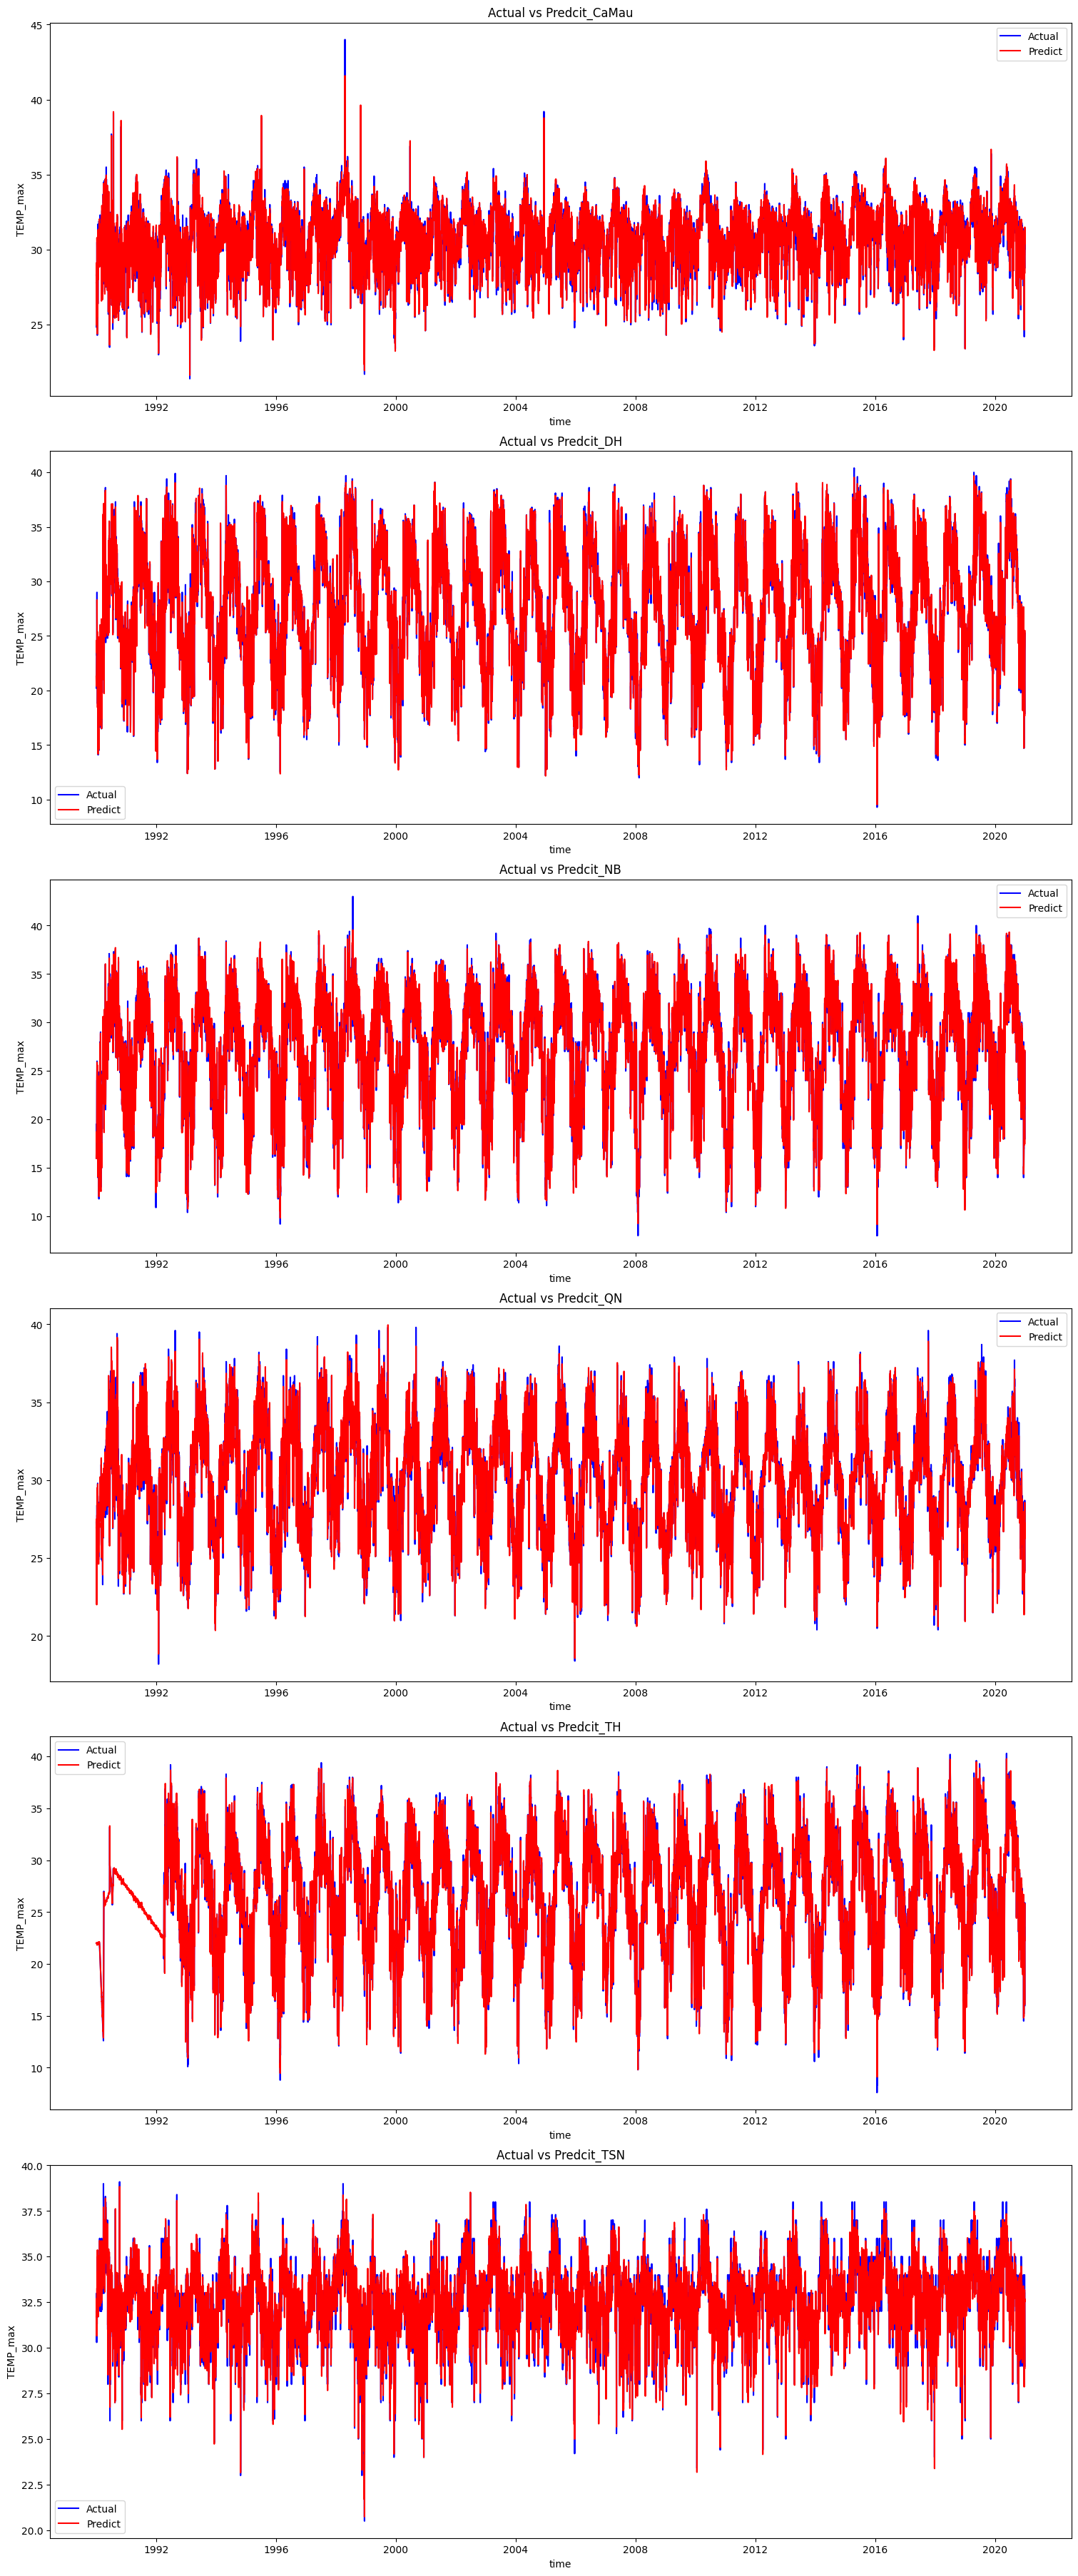

In [ ]:
num_cols = len(station_fit.keys())

# Xác định số hàng và số cột hợp lý
ncols = 1  # Số biểu đồ trên mỗi hàng
nrows = int(np.ceil(num_cols / ncols))  # Tính số hàng cần thiết

fig, ax = plt.subplots(ncols                = ncols, 
                       nrows              = nrows, 
                       figsize            = (15*ncols, 6*nrows),
                       constrained_layout = True)  # auto căn chỉnh
ax = ax.flatten()  # chuyển mảng 2 chiều thành 1 chiều để dễ duyệt

for i, name in enumerate(station.keys(), 0):
    # true_fit
    sns.lineplot(x     = station_fit[name].index,
                 y     = y_train_encoded.loc[y_train_encoded["NAME"] == src_name[name]]["TEMP_max"],
                 color = 'blue',
                 label = 'Actual',
                 ax    = ax[i])
    # fit
    sns.lineplot(x     = station_fit[name].index,
                 y     = tf.squeeze(station_fit[name]),
                 color = 'red',
                 label = 'Predict',
                 ax    = ax[i])
    ax[i].set_title(f"Actual vs Predict_{name}")

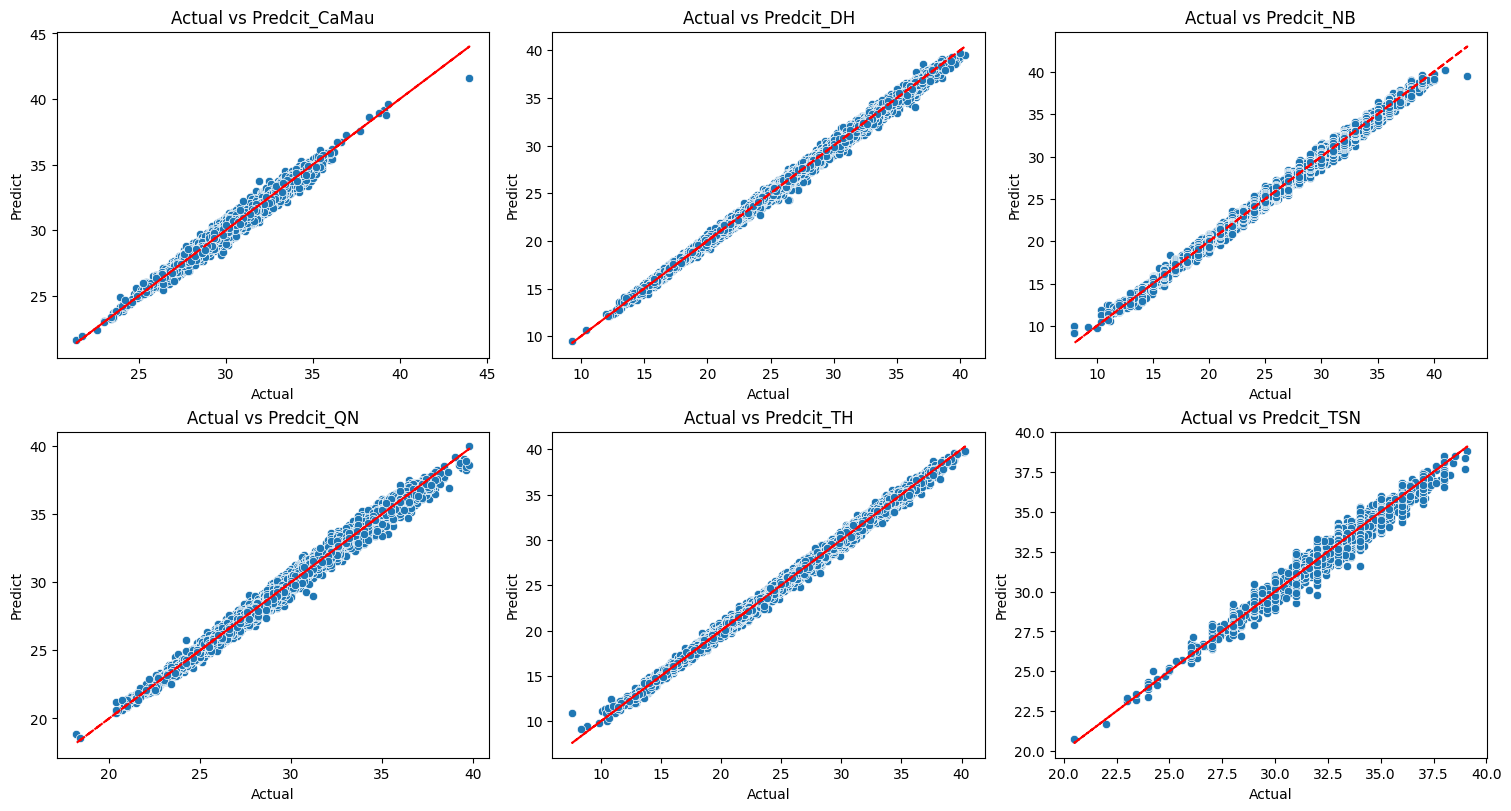

In [ ]:
num_cols = len(station_fit.keys())

# Xác định số hàng và số cột hợp lý
ncols = 3  # Số biểu đồ trên mỗi hàng
nrows = int(np.ceil(num_cols / ncols))  # Tính số hàng cần thiết

fig, ax = plt.subplots(ncols              = ncols, 
                       nrows              = nrows, 
                       figsize            = (5*ncols, 4*nrows),
                       constrained_layout = True)  # auto căn chỉnh
ax = ax.flatten()  # chuyển mảng 2 chiều thành 1 chiều để dễ duyệt

for i, name in enumerate(station.keys(), 0):
    # fit
    sns.scatterplot(x  = y_train_encoded.loc[y_train_encoded["NAME"] == src_name[name]]["TEMP_max"],
                    y  = tf.squeeze(station_fit[name]),
                    ax = ax[i])
    ax[i].set_xlabel("Actual")
    ax[i].set_ylabel("Predict")
    # true_fit
    ax[i].plot(y_train_encoded.loc[y_train_encoded["NAME"] == src_name[name]]["TEMP_max"],
               y_train_encoded.loc[y_train_encoded["NAME"] == src_name[name]]["TEMP_max"],
               "r--")
    ax[i].set_title(f"Actual vs Predict_{name}")

true_valid vs valid

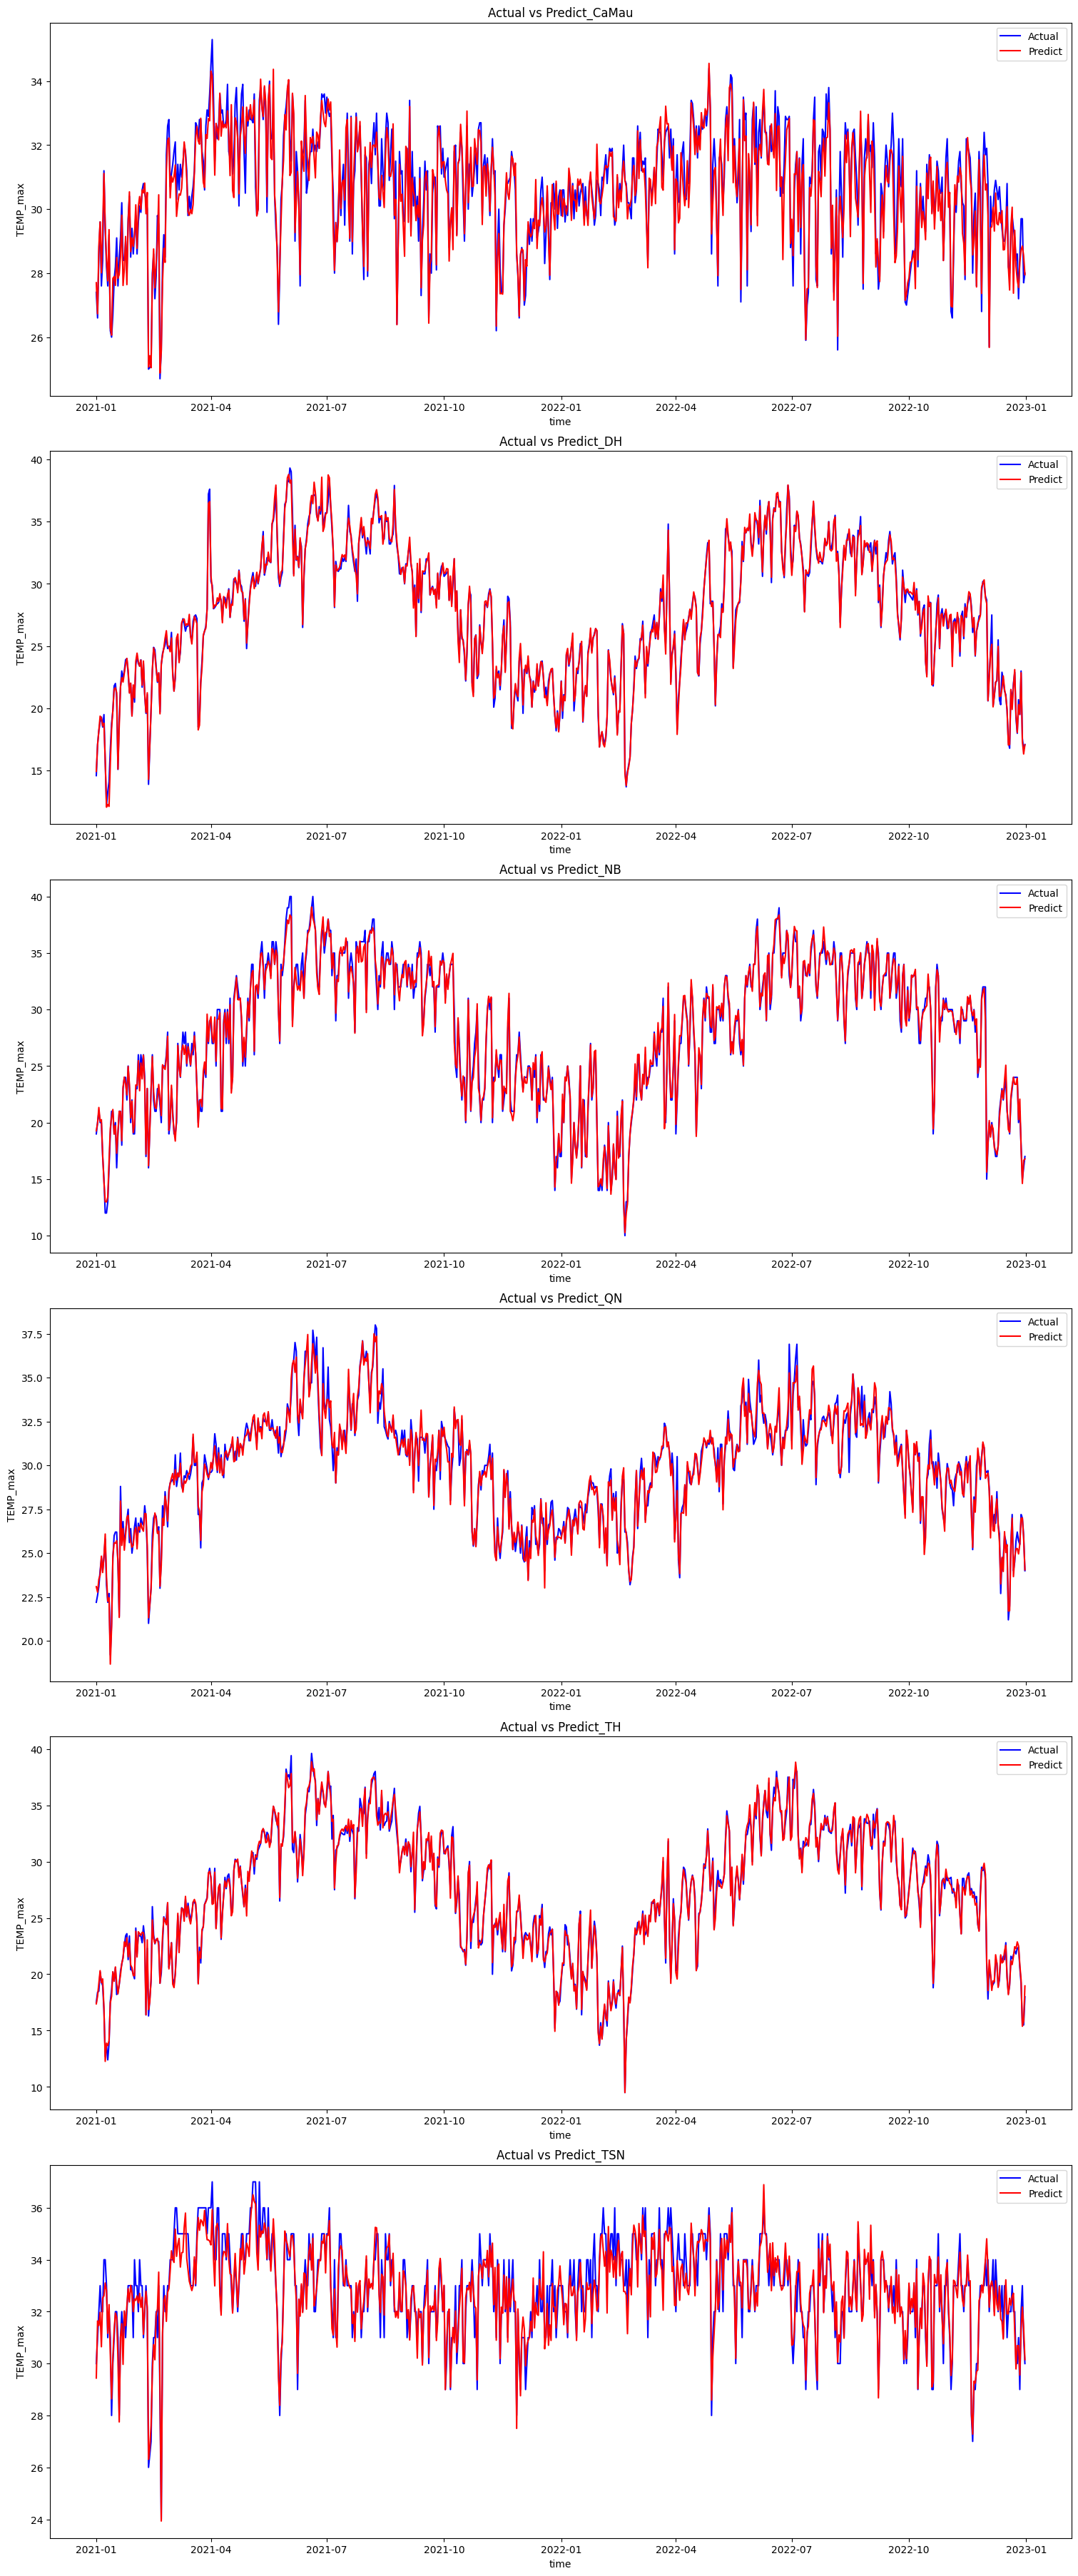

In [79]:
num_cols = len(station_valid.keys())

# Xác định số hàng và số cột hợp lý
ncols = 1  # Số biểu đồ trên mỗi hàng
nrows = int(np.ceil(num_cols / ncols))  # Tính số hàng cần thiết

fig, ax = plt.subplots(ncols                = ncols, 
                       nrows              = nrows, 
                       figsize            = (15*ncols, 6*nrows),
                       constrained_layout = True)  # auto căn chỉnh
ax = ax.flatten()  # chuyển mảng 2 chiều thành 1 chiều để dễ duyệt

for i, name in enumerate(station.keys(), 0):
    # true_valid
    sns.lineplot(x     = station_valid[name].index,
                 y     = y_valid_encoded.loc[y_valid_encoded["NAME"] == src_name[name]]["TEMP_max"],
                 color = 'blue',
                 label = 'Actual',
                 ax    = ax[i])
    # valid
    sns.lineplot(x     = station_valid[name].index,
                 y     = tf.squeeze(station_valid[name]),
                 color = 'red',
                 label = 'Predict',
                 ax    = ax[i])
    ax[i].set_title(f"Actual vs Predict_{name}")

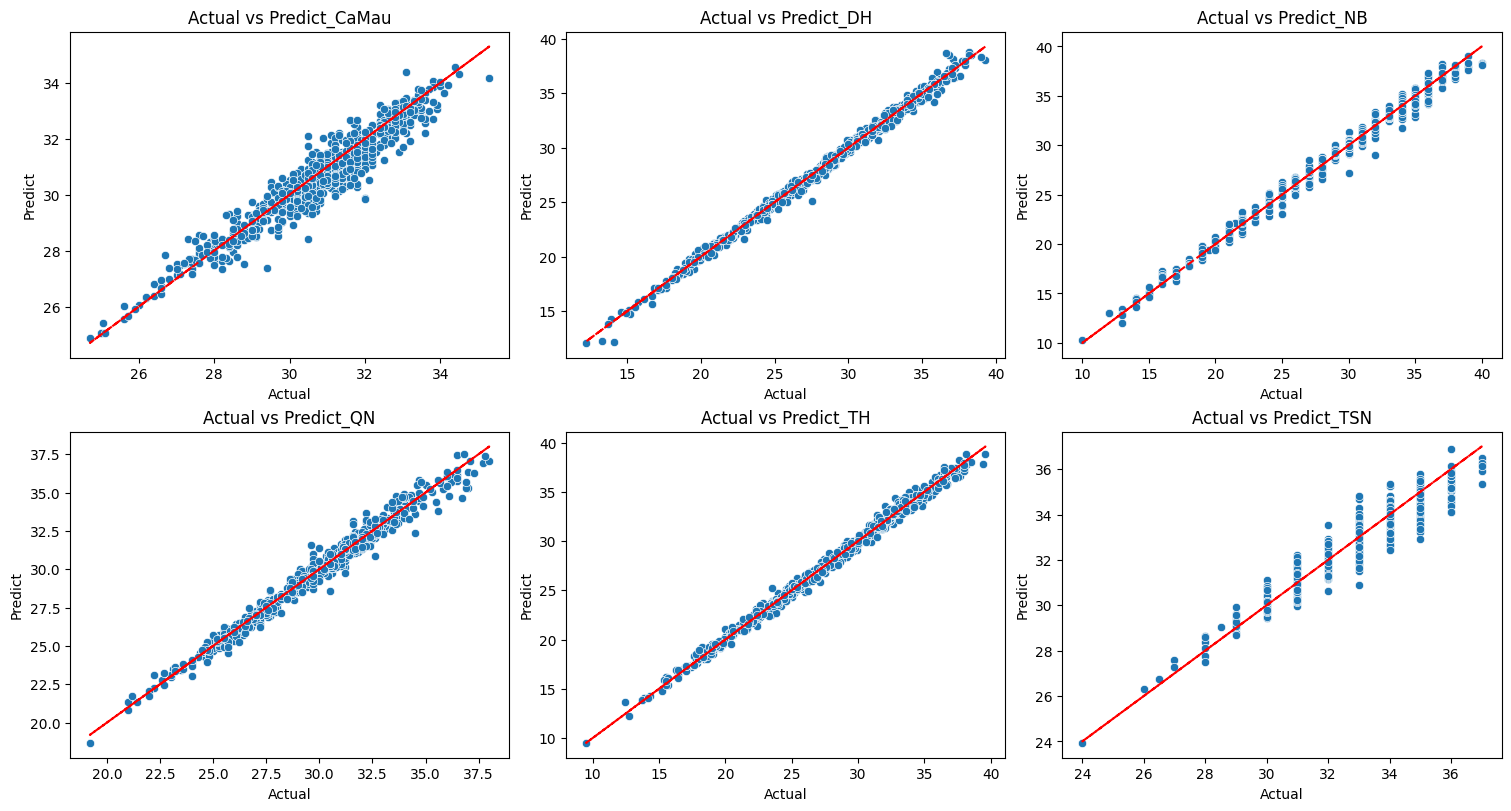

In [80]:
num_cols = len(station_valid.keys())

# Xác định số hàng và số cột hợp lý
ncols = 3  # Số biểu đồ trên mỗi hàng
nrows = int(np.ceil(num_cols / ncols))  # Tính số hàng cần thiết

fig, ax = plt.subplots(ncols              = ncols, 
                       nrows              = nrows, 
                       figsize            = (5*ncols, 4*nrows),
                       constrained_layout = True)  # auto căn chỉnh
ax = ax.flatten()  # chuyển mảng 2 chiều thành 1 chiều để dễ duyệt

for i, name in enumerate(station.keys(), 0):
    # valid
    sns.scatterplot(x  = y_valid_encoded.loc[y_valid_encoded["NAME"] == src_name[name]]["TEMP_max"],
                    y  = tf.squeeze(station_valid[name]),
                    ax = ax[i])
    ax[i].set_xlabel("Actual")
    ax[i].set_ylabel("Predict")
    # true_valid
    ax[i].plot(y_valid_encoded.loc[y_valid_encoded["NAME"] == src_name[name]]["TEMP_max"],
               y_valid_encoded.loc[y_valid_encoded["NAME"] == src_name[name]]["TEMP_max"],
               "r--")
    ax[i].set_title(f"Actual vs Predict_{name}")

true_pred vs pred

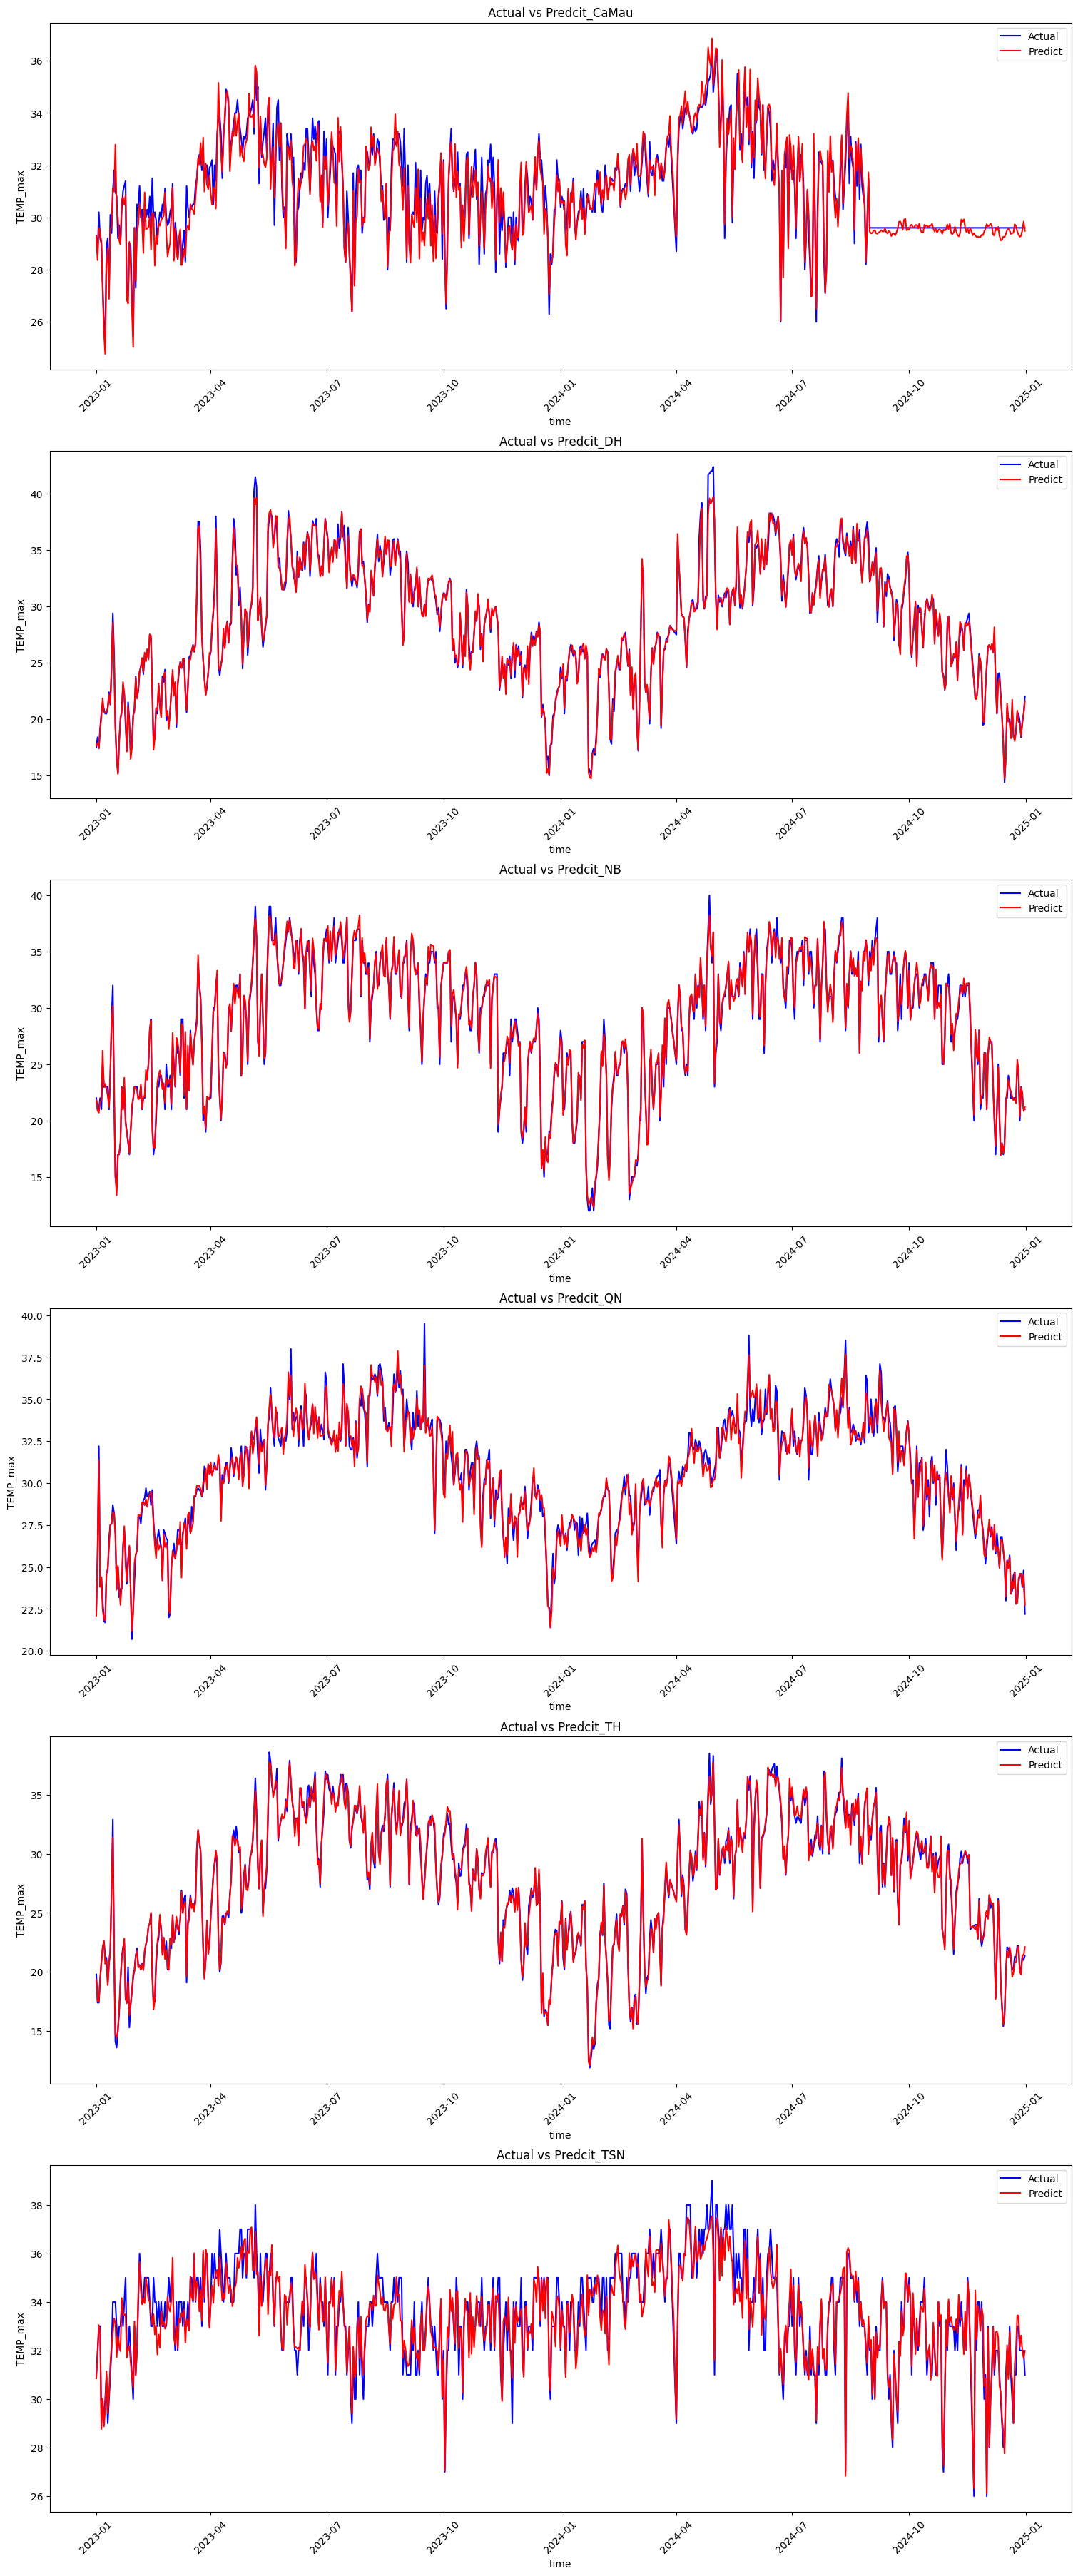

In [81]:
num_cols = len(station_fit.keys())

# Xác định số hàng và số cột hợp lý
ncols = 1  # Số biểu đồ trên mỗi hàng
nrows = int(np.ceil(num_cols / ncols))  # Tính số hàng cần thiết

fig, ax = plt.subplots(ncols                = ncols, 
                       nrows              = nrows, 
                       figsize            = (15*ncols, 6*nrows),
                       constrained_layout = True)  # auto căn chỉnh
ax = ax.flatten()  # chuyển mảng 2 chiều thành 1 chiều để dễ duyệt

for i, name in enumerate(station.keys(), 0):
    # true_fit
    sns.lineplot(x     = station_pred[name].index,
                 y     = y_test_encoded.loc[y_test_encoded["NAME"] == src_name[name]]["TEMP_max"],
                 color = 'blue',
                 label = 'Actual',
                 ax    = ax[i])
    # fit
    sns.lineplot(x     = station_pred[name].index,
                 y     = tf.squeeze(station_pred[name]),
                 color = 'red',
                 label = 'Predict',
                 ax    = ax[i])
    # xoay label trục X
    ax[i].tick_params(axis='x', rotation=45)
    ax[i].set_title(f"Actual vs Predcit_{name}")

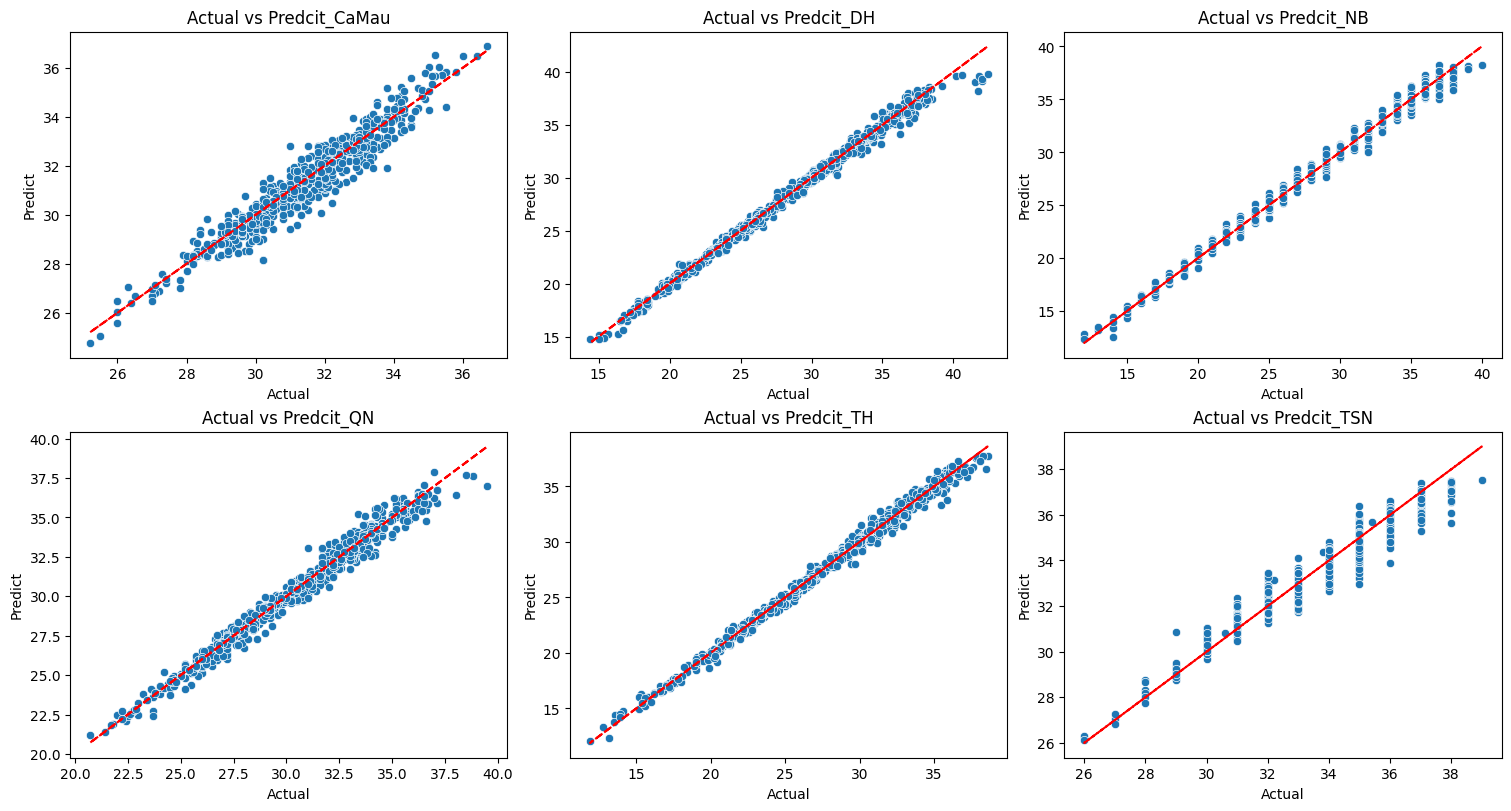

In [82]:
num_cols = len(station_fit.keys())

# Xác định số hàng và số cột hợp lý
ncols = 3  # Số biểu đồ trên mỗi hàng
nrows = int(np.ceil(num_cols / ncols))  # Tính số hàng cần thiết

fig, ax = plt.subplots(ncols                = ncols, 
                         nrows              = nrows, 
                         figsize            = (5*ncols, 4*nrows),
                         constrained_layout = True)  # auto căn chỉnh
ax = ax.flatten()  # chuyển mảng 2 chiều thành 1 chiều để dễ duyệt

for i, name in enumerate(station.keys(), 0):
    # fit
    sns.scatterplot(x  = y_test_encoded.loc[y_test_encoded["NAME"] == src_name[name]]["TEMP_max"],
                    y  = tf.squeeze(station_pred[name]),
                    ax = ax[i])
    ax[i].set_xlabel("Actual")
    ax[i].set_ylabel("Predict")
    # true_fit
    ax[i].plot(y_test_encoded.loc[y_test_encoded["NAME"] == src_name[name]]["TEMP_max"],
               y_test_encoded.loc[y_test_encoded["NAME"] == src_name[name]]["TEMP_max"],
               "r--")
    ax[i].set_title(f"Actual vs Predcit_{name}")

##### <span style="color:tomato">Metrics score</span>

🔸 Trạm: CaMau


f:\NCKH\.venv\lib\site-packages\sklearn\metrics\_regression.py:1283: UndefinedMetricWarning: R^2 score is not well-defined with less than two samples.
  warnings.warn(msg, UndefinedMetricWarning)
f:\NCKH\.venv\lib\site-packages\sklearn\metrics\_regression.py:1283: UndefinedMetricWarning: R^2 score is not well-defined with less than two samples.
  warnings.warn(msg, UndefinedMetricWarning)
f:\NCKH\TSF_Github\Drafts\Temp Prediction\notebooks\3.1. ML_model\../..\scripts\evaluate_model.py:128: FutureWarning: 'Y' is deprecated and will be removed in a future version, please use 'YE' instead.
  years = idx_series.to_series().resample('Y').mean().interpolate().dt.year
f:\NCKH\TSF_Github\Drafts\Temp Prediction\notebooks\3.1. ML_model\../..\scripts\evaluate_model.py:129: FutureWarning: 'Y' is deprecated and will be removed in a future version, please use 'YE' instead.
  train_scores_yearly = pd.Series(train_scores, index=idx_series).resample('Y').mean().interpolate()
f:\NCKH\TSF_Github\Drafts\T

🔹 TEMP_max_CaMau (R2_train) : 0.9732354194984052
🔹 TEMP_max_CaMau (R2_test)  : 0.9220089763782349

🔹 TEMP_max_CaMau (MAE_train) : 0.2452154696393032
🔹 TEMP_max_CaMau (MAE_test)  : 0.37816880639698547



f:\NCKH\TSF_Github\Drafts\Temp Prediction\notebooks\3.1. ML_model\../..\scripts\evaluate_model.py:229: FutureWarning: 'Y' is deprecated and will be removed in a future version, please use 'YE' instead.
  years = idx_series.to_series().resample('Y').mean().interpolate().dt.year
f:\NCKH\TSF_Github\Drafts\Temp Prediction\notebooks\3.1. ML_model\../..\scripts\evaluate_model.py:230: FutureWarning: 'Y' is deprecated and will be removed in a future version, please use 'YE' instead.
  train_scores_yearly = pd.Series(train_scores, index=idx_series).resample('Y').mean().interpolate()
f:\NCKH\TSF_Github\Drafts\Temp Prediction\notebooks\3.1. ML_model\../..\scripts\evaluate_model.py:231: FutureWarning: 'Y' is deprecated and will be removed in a future version, please use 'YE' instead.
  test_scores_yearly  = pd.Series(test_scores, index=idx_series).resample('Y').mean().interpolate()
f:\NCKH\TSF_Github\Drafts\Temp Prediction\notebooks\3.1. ML_model\../..\scripts\evaluate_model.py:329: FutureWarning:

🔹 TEMP_max_CaMau (MSE_train) : 0.10021738312962622
🔹 TEMP_max_CaMau (MSE_test)  : 0.2622813570905407

🔹 TEMP_max_CaMau (MSLE_train) : 9.905608435199956e-05
🔹 TEMP_max_CaMau (MSLE_test)  : 0.0002516553051912425



f:\NCKH\TSF_Github\Drafts\Temp Prediction\notebooks\3.1. ML_model\../..\scripts\evaluate_model.py:528: FutureWarning: 'Y' is deprecated and will be removed in a future version, please use 'YE' instead.
  years = idx_series.to_series().resample('Y').mean().interpolate().dt.year
f:\NCKH\TSF_Github\Drafts\Temp Prediction\notebooks\3.1. ML_model\../..\scripts\evaluate_model.py:529: FutureWarning: 'Y' is deprecated and will be removed in a future version, please use 'YE' instead.
  train_scores_yearly = pd.Series(train_scores, index=idx_series).resample('Y').mean().interpolate()
f:\NCKH\TSF_Github\Drafts\Temp Prediction\notebooks\3.1. ML_model\../..\scripts\evaluate_model.py:530: FutureWarning: 'Y' is deprecated and will be removed in a future version, please use 'YE' instead.
  test_scores_yearly  = pd.Series(test_scores, index=idx_series).resample('Y').mean().interpolate()


🔹 TEMP_max_CaMau (MAPE_train) : 0.007964072574833463
🔹 TEMP_max_CaMau (MAPE_test)  : 0.01206874022471913



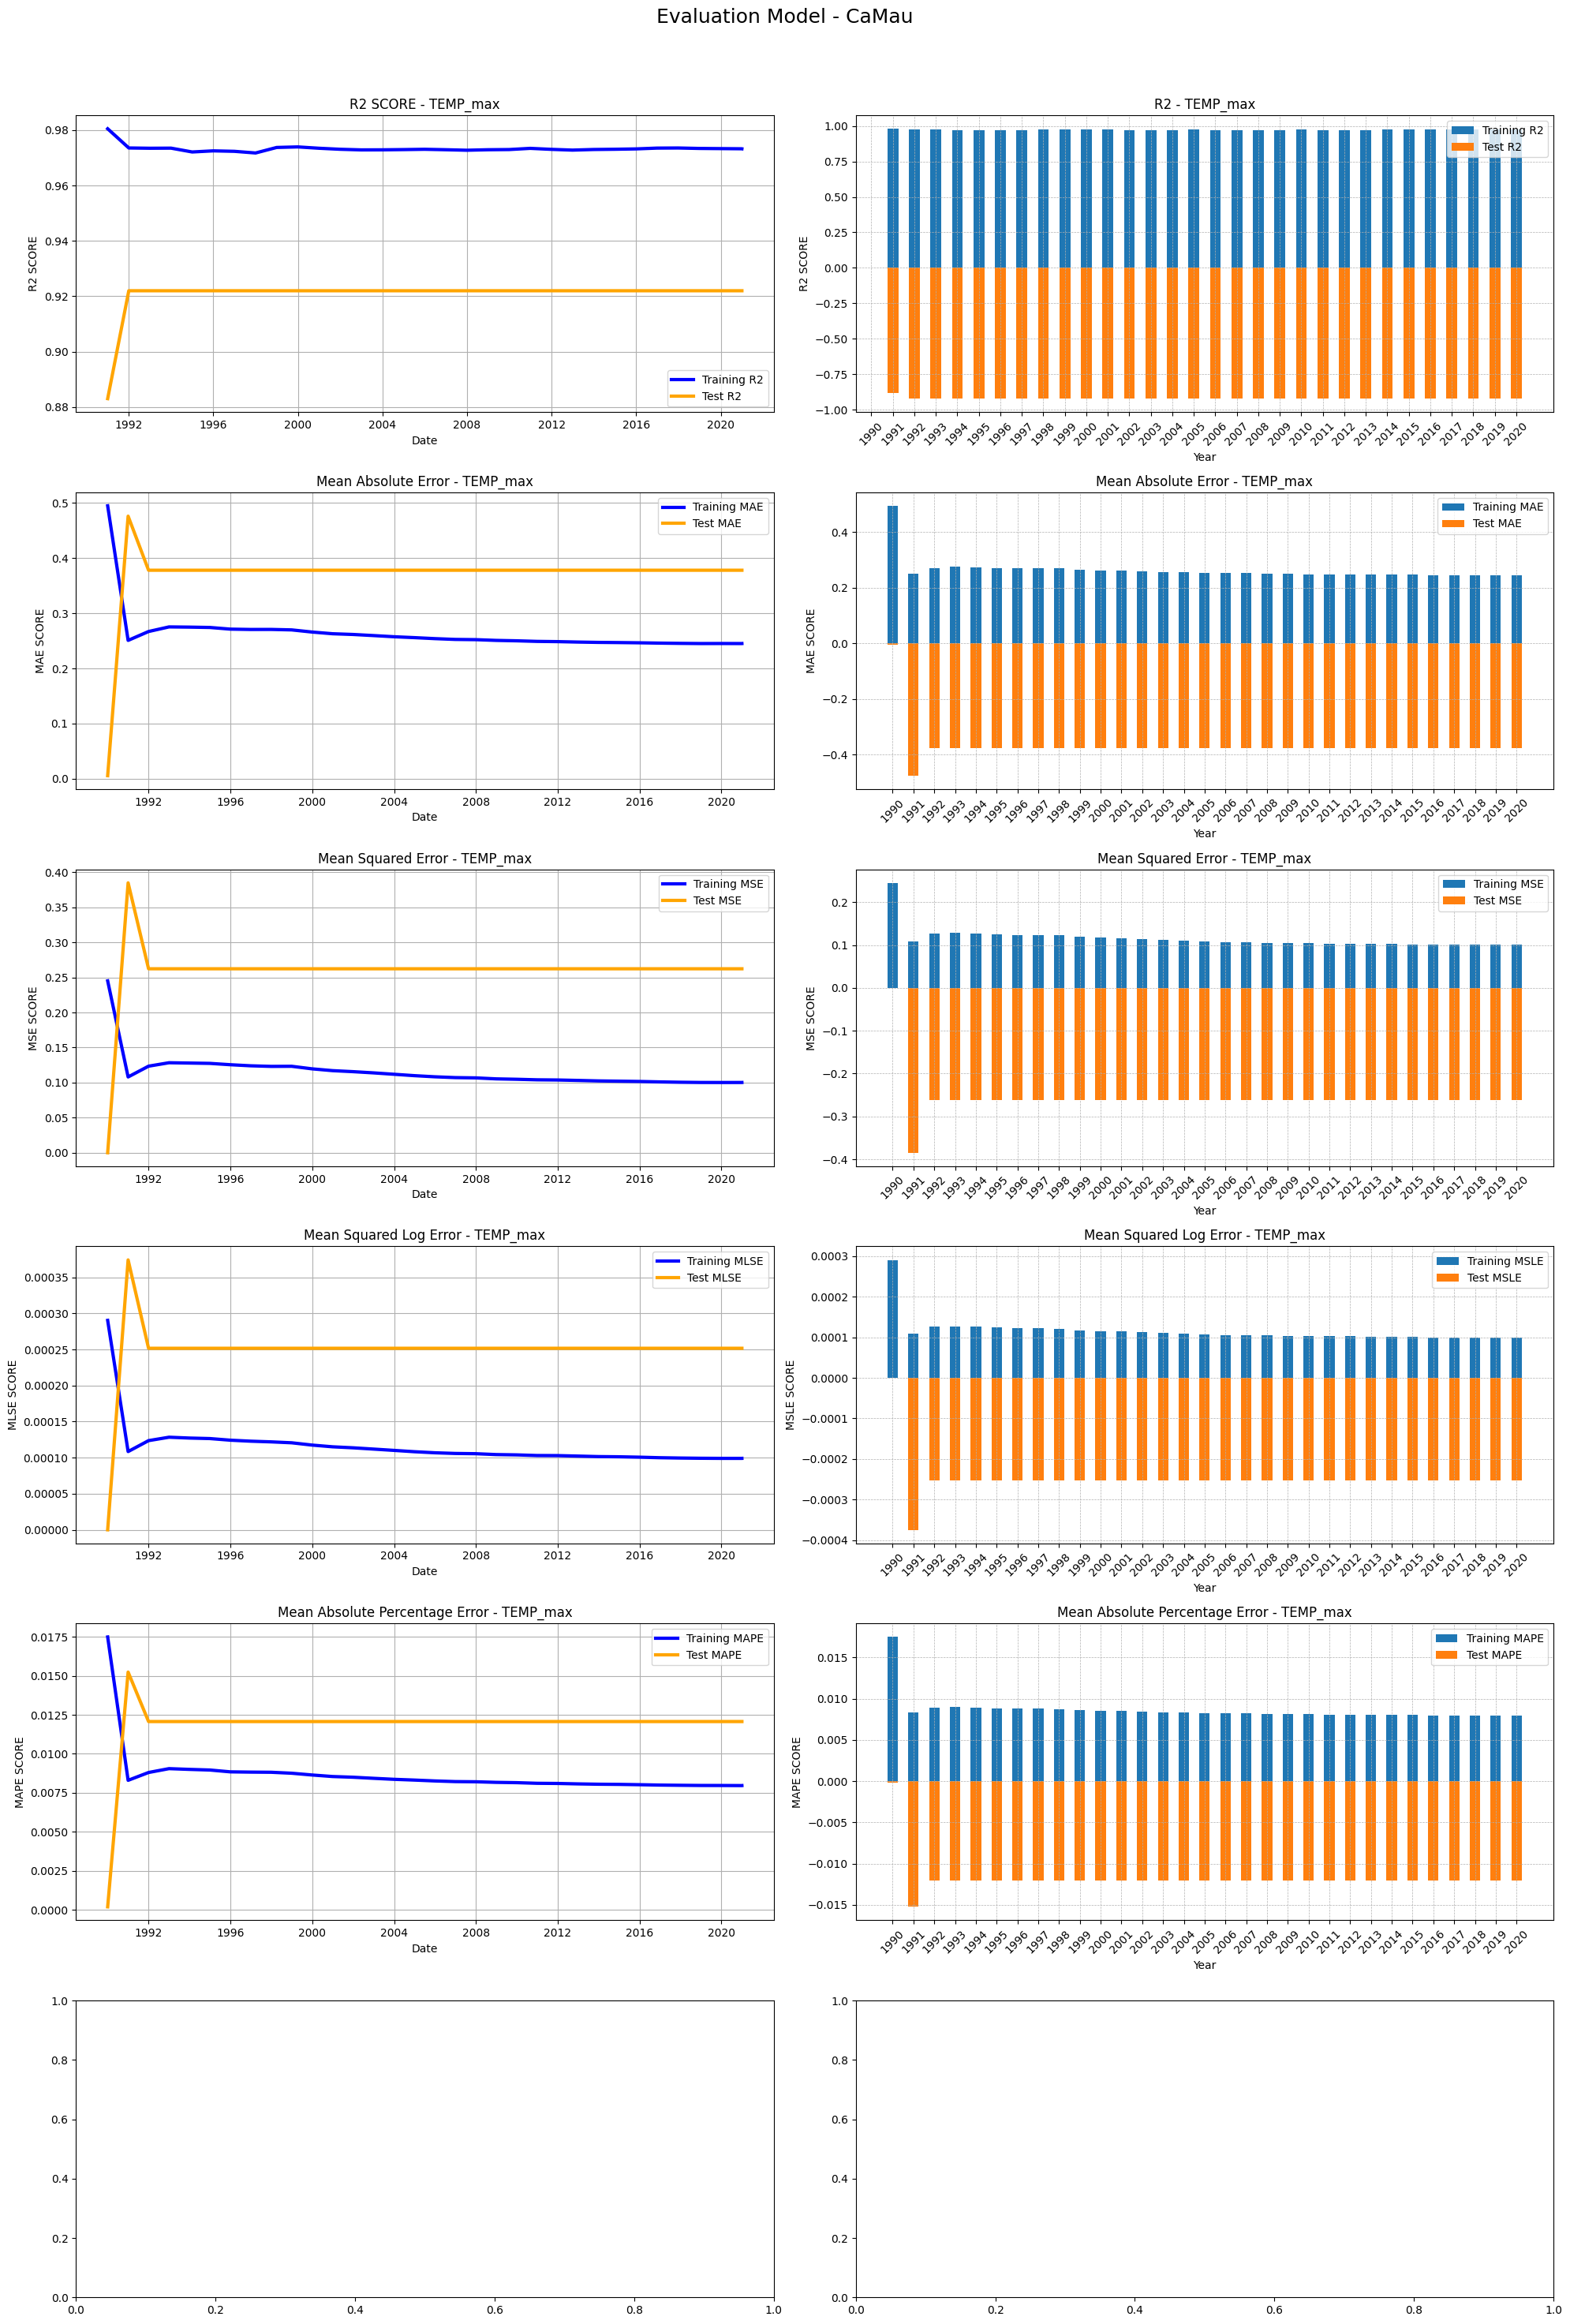

🔸 Trạm: DH


f:\NCKH\.venv\lib\site-packages\sklearn\metrics\_regression.py:1283: UndefinedMetricWarning: R^2 score is not well-defined with less than two samples.
  warnings.warn(msg, UndefinedMetricWarning)
f:\NCKH\.venv\lib\site-packages\sklearn\metrics\_regression.py:1283: UndefinedMetricWarning: R^2 score is not well-defined with less than two samples.
  warnings.warn(msg, UndefinedMetricWarning)
f:\NCKH\TSF_Github\Drafts\Temp Prediction\notebooks\3.1. ML_model\../..\scripts\evaluate_model.py:128: FutureWarning: 'Y' is deprecated and will be removed in a future version, please use 'YE' instead.
  years = idx_series.to_series().resample('Y').mean().interpolate().dt.year
f:\NCKH\TSF_Github\Drafts\Temp Prediction\notebooks\3.1. ML_model\../..\scripts\evaluate_model.py:129: FutureWarning: 'Y' is deprecated and will be removed in a future version, please use 'YE' instead.
  train_scores_yearly = pd.Series(train_scores, index=idx_series).resample('Y').mean().interpolate()
f:\NCKH\TSF_Github\Drafts\T

🔹 TEMP_max_DH (R2_train) : 0.996679444049771
🔹 TEMP_max_DH (R2_test)  : 0.9925622964281409

🔹 TEMP_max_DH (MAE_train) : 0.2321903681270073
🔹 TEMP_max_DH (MAE_test)  : 0.3226805456555493



f:\NCKH\TSF_Github\Drafts\Temp Prediction\notebooks\3.1. ML_model\../..\scripts\evaluate_model.py:229: FutureWarning: 'Y' is deprecated and will be removed in a future version, please use 'YE' instead.
  years = idx_series.to_series().resample('Y').mean().interpolate().dt.year
f:\NCKH\TSF_Github\Drafts\Temp Prediction\notebooks\3.1. ML_model\../..\scripts\evaluate_model.py:230: FutureWarning: 'Y' is deprecated and will be removed in a future version, please use 'YE' instead.
  train_scores_yearly = pd.Series(train_scores, index=idx_series).resample('Y').mean().interpolate()
f:\NCKH\TSF_Github\Drafts\Temp Prediction\notebooks\3.1. ML_model\../..\scripts\evaluate_model.py:231: FutureWarning: 'Y' is deprecated and will be removed in a future version, please use 'YE' instead.
  test_scores_yearly  = pd.Series(test_scores, index=idx_series).resample('Y').mean().interpolate()
f:\NCKH\TSF_Github\Drafts\Temp Prediction\notebooks\3.1. ML_model\../..\scripts\evaluate_model.py:329: FutureWarning:

🔹 TEMP_max_DH (MSE_train) : 0.09355011667619932
🔹 TEMP_max_DH (MSE_test)  : 0.23130435022811704

🔹 TEMP_max_DH (MSLE_train) : 0.0001157127908267205
🔹 TEMP_max_DH (MSLE_test)  : 0.00022920018657611525



f:\NCKH\TSF_Github\Drafts\Temp Prediction\notebooks\3.1. ML_model\../..\scripts\evaluate_model.py:429: FutureWarning: 'Y' is deprecated and will be removed in a future version, please use 'YE' instead.
  years = idx_series.to_series().resample('Y').mean().interpolate().dt.year
f:\NCKH\TSF_Github\Drafts\Temp Prediction\notebooks\3.1. ML_model\../..\scripts\evaluate_model.py:430: FutureWarning: 'Y' is deprecated and will be removed in a future version, please use 'YE' instead.
  train_scores_yearly = pd.Series(train_scores, index=idx_series).resample('Y').mean().interpolate()
f:\NCKH\TSF_Github\Drafts\Temp Prediction\notebooks\3.1. ML_model\../..\scripts\evaluate_model.py:431: FutureWarning: 'Y' is deprecated and will be removed in a future version, please use 'YE' instead.
  test_scores_yearly  = pd.Series(test_scores, index=idx_series).resample('Y').mean().interpolate()
f:\NCKH\TSF_Github\Drafts\Temp Prediction\notebooks\3.1. ML_model\../..\scripts\evaluate_model.py:528: FutureWarning:

🔹 TEMP_max_DH (MAPE_train) : 0.008508307526963355
🔹 TEMP_max_DH (MAPE_test)  : 0.011110249352975271



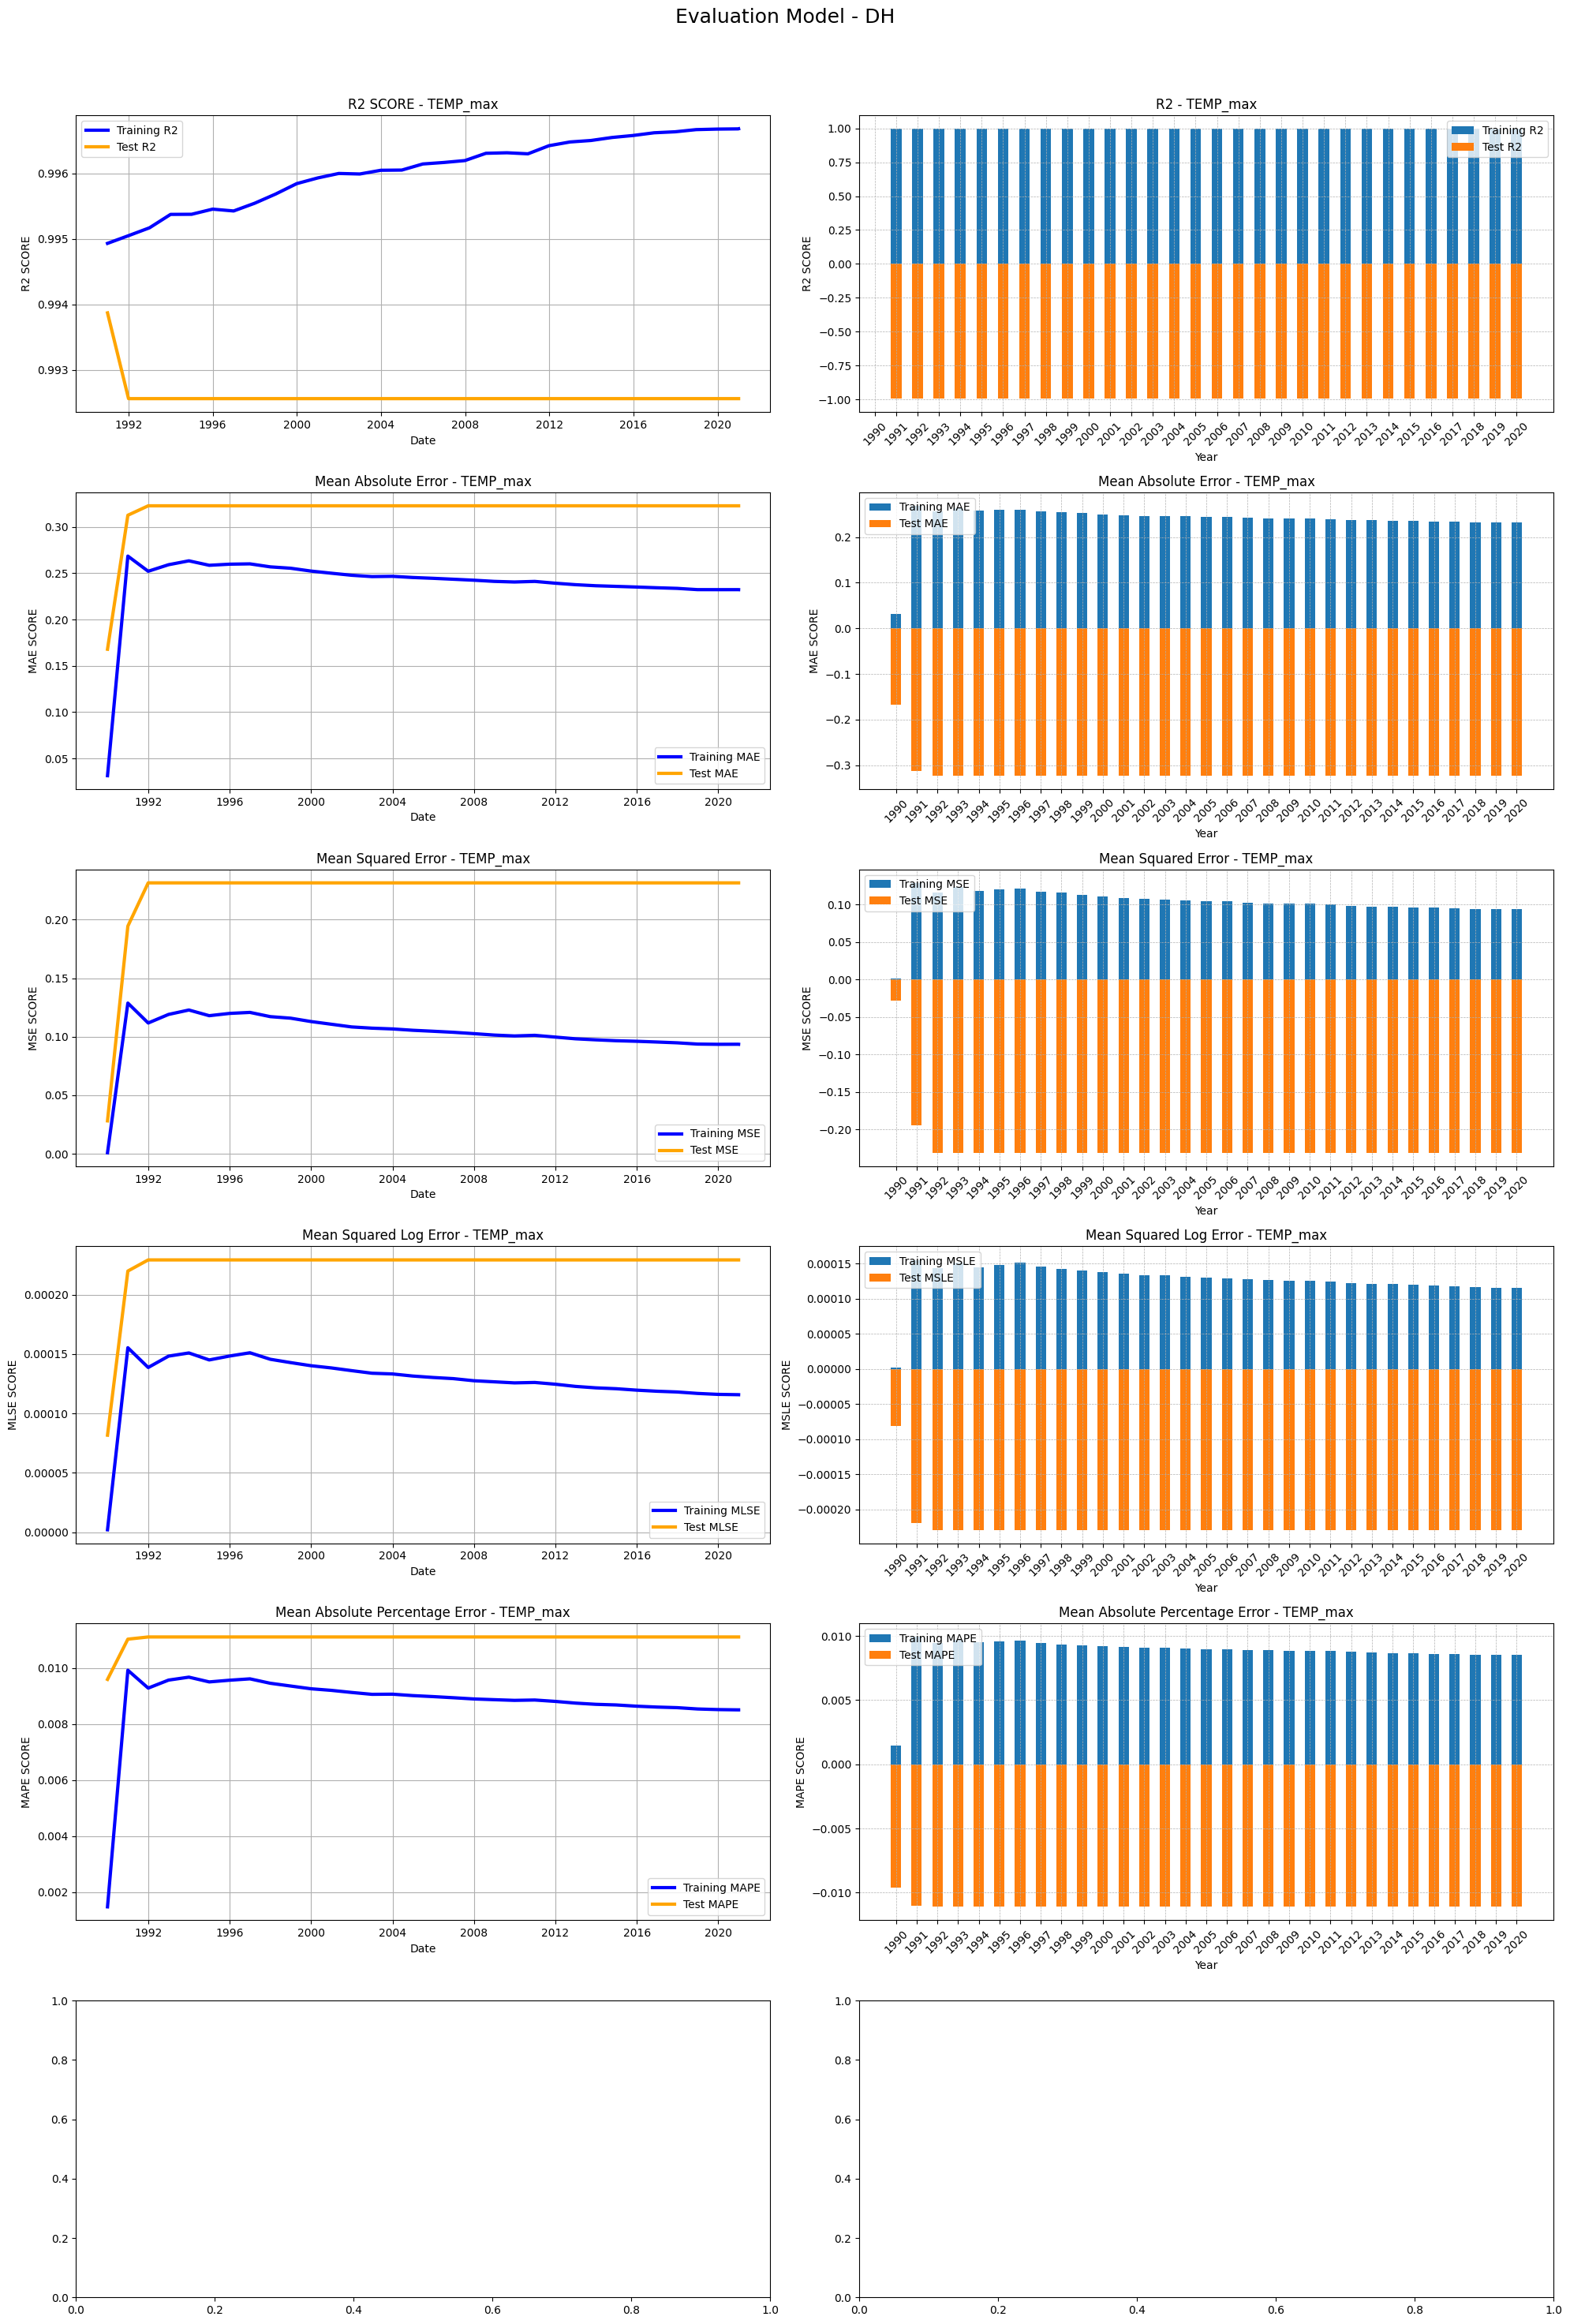

🔸 Trạm: NB


f:\NCKH\.venv\lib\site-packages\sklearn\metrics\_regression.py:1283: UndefinedMetricWarning: R^2 score is not well-defined with less than two samples.
  warnings.warn(msg, UndefinedMetricWarning)
f:\NCKH\.venv\lib\site-packages\sklearn\metrics\_regression.py:1283: UndefinedMetricWarning: R^2 score is not well-defined with less than two samples.
  warnings.warn(msg, UndefinedMetricWarning)
f:\NCKH\TSF_Github\Drafts\Temp Prediction\notebooks\3.1. ML_model\../..\scripts\evaluate_model.py:128: FutureWarning: 'Y' is deprecated and will be removed in a future version, please use 'YE' instead.
  years = idx_series.to_series().resample('Y').mean().interpolate().dt.year
f:\NCKH\TSF_Github\Drafts\Temp Prediction\notebooks\3.1. ML_model\../..\scripts\evaluate_model.py:129: FutureWarning: 'Y' is deprecated and will be removed in a future version, please use 'YE' instead.
  train_scores_yearly = pd.Series(train_scores, index=idx_series).resample('Y').mean().interpolate()
f:\NCKH\TSF_Github\Drafts\T

🔹 TEMP_max_NB (R2_train) : 0.9956816360554454
🔹 TEMP_max_NB (R2_test)  : 0.992925743221148

🔹 TEMP_max_NB (MAE_train) : 0.30393056550295877
🔹 TEMP_max_NB (MAE_test)  : 0.3729755438140577



f:\NCKH\TSF_Github\Drafts\Temp Prediction\notebooks\3.1. ML_model\../..\scripts\evaluate_model.py:229: FutureWarning: 'Y' is deprecated and will be removed in a future version, please use 'YE' instead.
  years = idx_series.to_series().resample('Y').mean().interpolate().dt.year
f:\NCKH\TSF_Github\Drafts\Temp Prediction\notebooks\3.1. ML_model\../..\scripts\evaluate_model.py:230: FutureWarning: 'Y' is deprecated and will be removed in a future version, please use 'YE' instead.
  train_scores_yearly = pd.Series(train_scores, index=idx_series).resample('Y').mean().interpolate()
f:\NCKH\TSF_Github\Drafts\Temp Prediction\notebooks\3.1. ML_model\../..\scripts\evaluate_model.py:231: FutureWarning: 'Y' is deprecated and will be removed in a future version, please use 'YE' instead.
  test_scores_yearly  = pd.Series(test_scores, index=idx_series).resample('Y').mean().interpolate()
f:\NCKH\TSF_Github\Drafts\Temp Prediction\notebooks\3.1. ML_model\../..\scripts\evaluate_model.py:329: FutureWarning:

🔹 TEMP_max_NB (MSE_train) : 0.15255523019262496
🔹 TEMP_max_NB (MSE_test)  : 0.24429029963955062

🔹 TEMP_max_NB (MSLE_train) : 0.00022033997794575612
🔹 TEMP_max_NB (MSLE_test)  : 0.00029430758935441363



f:\NCKH\TSF_Github\Drafts\Temp Prediction\notebooks\3.1. ML_model\../..\scripts\evaluate_model.py:429: FutureWarning: 'Y' is deprecated and will be removed in a future version, please use 'YE' instead.
  years = idx_series.to_series().resample('Y').mean().interpolate().dt.year
f:\NCKH\TSF_Github\Drafts\Temp Prediction\notebooks\3.1. ML_model\../..\scripts\evaluate_model.py:430: FutureWarning: 'Y' is deprecated and will be removed in a future version, please use 'YE' instead.
  train_scores_yearly = pd.Series(train_scores, index=idx_series).resample('Y').mean().interpolate()
f:\NCKH\TSF_Github\Drafts\Temp Prediction\notebooks\3.1. ML_model\../..\scripts\evaluate_model.py:431: FutureWarning: 'Y' is deprecated and will be removed in a future version, please use 'YE' instead.
  test_scores_yearly  = pd.Series(test_scores, index=idx_series).resample('Y').mean().interpolate()
f:\NCKH\TSF_Github\Drafts\Temp Prediction\notebooks\3.1. ML_model\../..\scripts\evaluate_model.py:528: FutureWarning:

🔹 TEMP_max_NB (MAPE_train) : 0.011572160204742842
🔹 TEMP_max_NB (MAPE_test)  : 0.013412314578060039



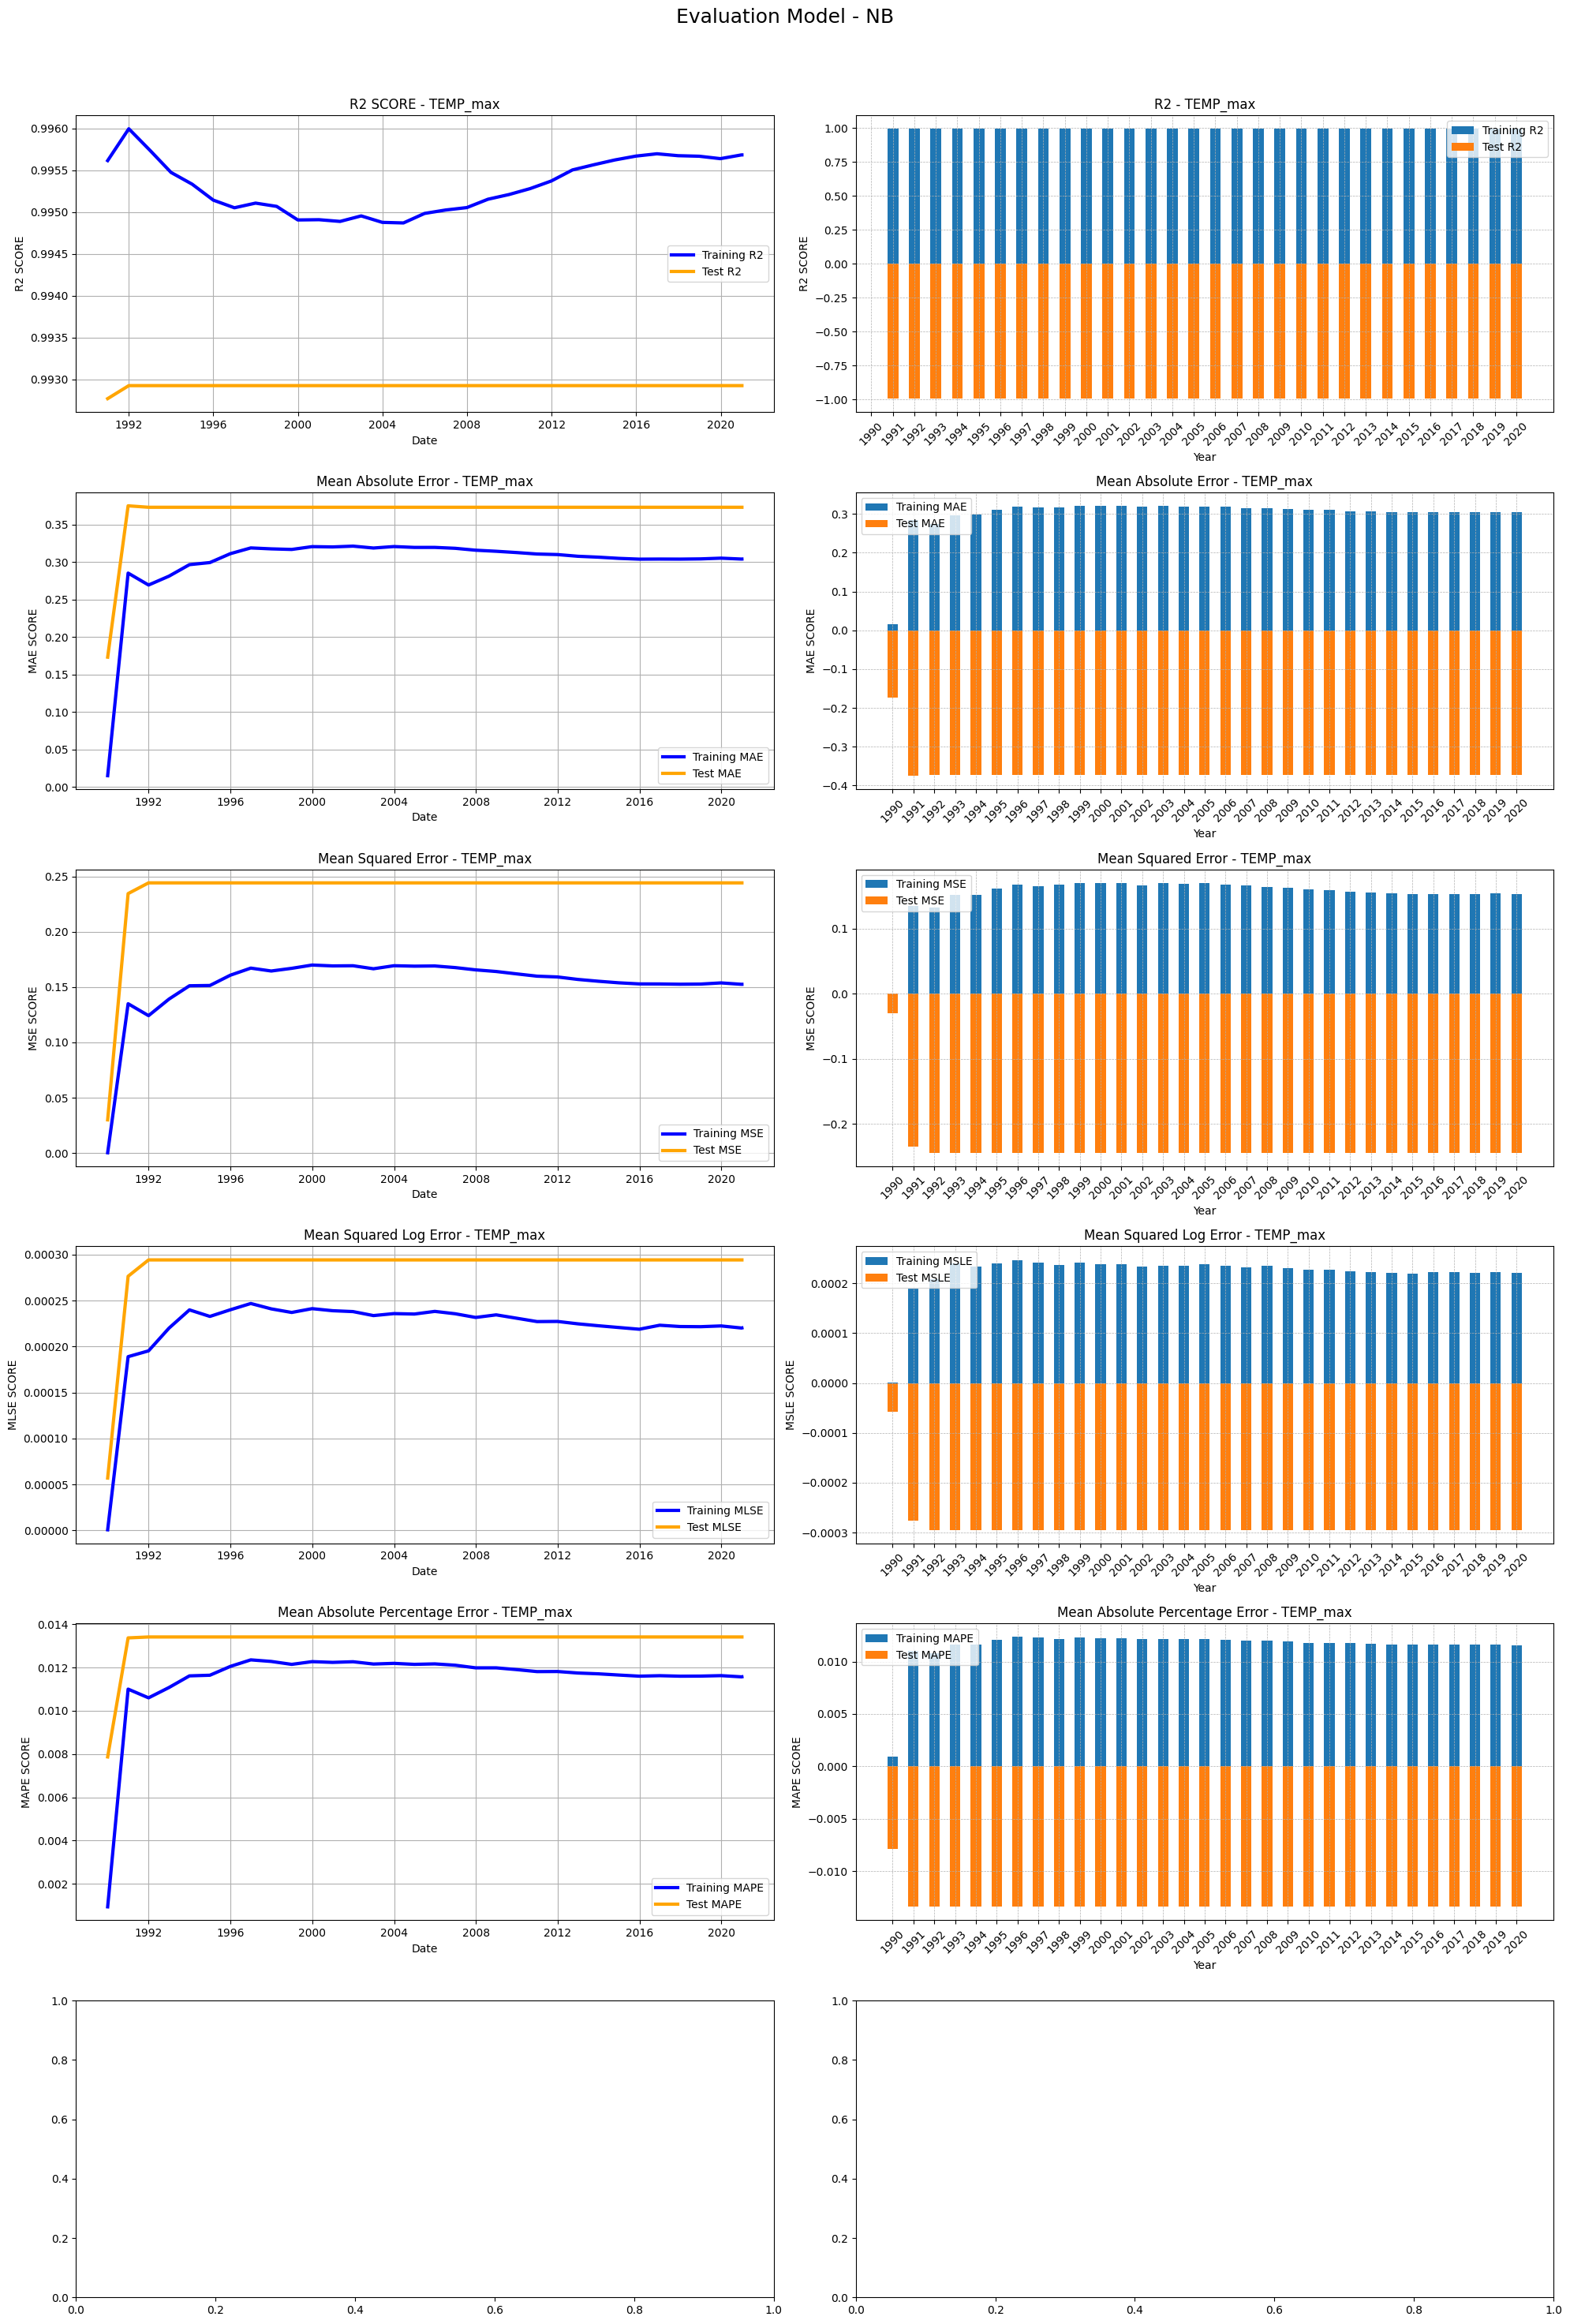

🔸 Trạm: QN


f:\NCKH\.venv\lib\site-packages\sklearn\metrics\_regression.py:1283: UndefinedMetricWarning: R^2 score is not well-defined with less than two samples.
  warnings.warn(msg, UndefinedMetricWarning)
f:\NCKH\.venv\lib\site-packages\sklearn\metrics\_regression.py:1283: UndefinedMetricWarning: R^2 score is not well-defined with less than two samples.
  warnings.warn(msg, UndefinedMetricWarning)
f:\NCKH\TSF_Github\Drafts\Temp Prediction\notebooks\3.1. ML_model\../..\scripts\evaluate_model.py:128: FutureWarning: 'Y' is deprecated and will be removed in a future version, please use 'YE' instead.
  years = idx_series.to_series().resample('Y').mean().interpolate().dt.year
f:\NCKH\TSF_Github\Drafts\Temp Prediction\notebooks\3.1. ML_model\../..\scripts\evaluate_model.py:129: FutureWarning: 'Y' is deprecated and will be removed in a future version, please use 'YE' instead.
  train_scores_yearly = pd.Series(train_scores, index=idx_series).resample('Y').mean().interpolate()
f:\NCKH\TSF_Github\Drafts\T

🔹 TEMP_max_QN (R2_train) : 0.9912418315107263
🔹 TEMP_max_QN (R2_test)  : 0.9769265755198702



f:\NCKH\TSF_Github\Drafts\Temp Prediction\notebooks\3.1. ML_model\../..\scripts\evaluate_model.py:229: FutureWarning: 'Y' is deprecated and will be removed in a future version, please use 'YE' instead.
  years = idx_series.to_series().resample('Y').mean().interpolate().dt.year
f:\NCKH\TSF_Github\Drafts\Temp Prediction\notebooks\3.1. ML_model\../..\scripts\evaluate_model.py:230: FutureWarning: 'Y' is deprecated and will be removed in a future version, please use 'YE' instead.
  train_scores_yearly = pd.Series(train_scores, index=idx_series).resample('Y').mean().interpolate()
f:\NCKH\TSF_Github\Drafts\Temp Prediction\notebooks\3.1. ML_model\../..\scripts\evaluate_model.py:231: FutureWarning: 'Y' is deprecated and will be removed in a future version, please use 'YE' instead.
  test_scores_yearly  = pd.Series(test_scores, index=idx_series).resample('Y').mean().interpolate()


🔹 TEMP_max_QN (MAE_train) : 0.24226938127688788
🔹 TEMP_max_QN (MAE_test)  : 0.38198178313499276



f:\NCKH\TSF_Github\Drafts\Temp Prediction\notebooks\3.1. ML_model\../..\scripts\evaluate_model.py:329: FutureWarning: 'Y' is deprecated and will be removed in a future version, please use 'YE' instead.
  years = idx_series.to_series().resample('Y').mean().interpolate().dt.year
f:\NCKH\TSF_Github\Drafts\Temp Prediction\notebooks\3.1. ML_model\../..\scripts\evaluate_model.py:330: FutureWarning: 'Y' is deprecated and will be removed in a future version, please use 'YE' instead.
  train_scores_yearly = pd.Series(train_scores, index=idx_series).resample('Y').mean().interpolate()
f:\NCKH\TSF_Github\Drafts\Temp Prediction\notebooks\3.1. ML_model\../..\scripts\evaluate_model.py:331: FutureWarning: 'Y' is deprecated and will be removed in a future version, please use 'YE' instead.
  test_scores_yearly  = pd.Series(test_scores, index=idx_series).resample('Y').mean().interpolate()


🔹 TEMP_max_QN (MSE_train) : 0.10251994765303213
🔹 TEMP_max_QN (MSE_test)  : 0.2624052507210534



f:\NCKH\TSF_Github\Drafts\Temp Prediction\notebooks\3.1. ML_model\../..\scripts\evaluate_model.py:429: FutureWarning: 'Y' is deprecated and will be removed in a future version, please use 'YE' instead.
  years = idx_series.to_series().resample('Y').mean().interpolate().dt.year
f:\NCKH\TSF_Github\Drafts\Temp Prediction\notebooks\3.1. ML_model\../..\scripts\evaluate_model.py:430: FutureWarning: 'Y' is deprecated and will be removed in a future version, please use 'YE' instead.
  train_scores_yearly = pd.Series(train_scores, index=idx_series).resample('Y').mean().interpolate()
f:\NCKH\TSF_Github\Drafts\Temp Prediction\notebooks\3.1. ML_model\../..\scripts\evaluate_model.py:431: FutureWarning: 'Y' is deprecated and will be removed in a future version, please use 'YE' instead.
  test_scores_yearly  = pd.Series(test_scores, index=idx_series).resample('Y').mean().interpolate()
f:\NCKH\TSF_Github\Drafts\Temp Prediction\notebooks\3.1. ML_model\../..\scripts\evaluate_model.py:528: FutureWarning:

🔹 TEMP_max_QN (MSLE_train) : 0.0001030399176085588
🔹 TEMP_max_QN (MSLE_test)  : 0.0002543883947923412

🔹 TEMP_max_QN (MAPE_train) : 0.008014625344111886
🔹 TEMP_max_QN (MAPE_test)  : 0.012400224947453655



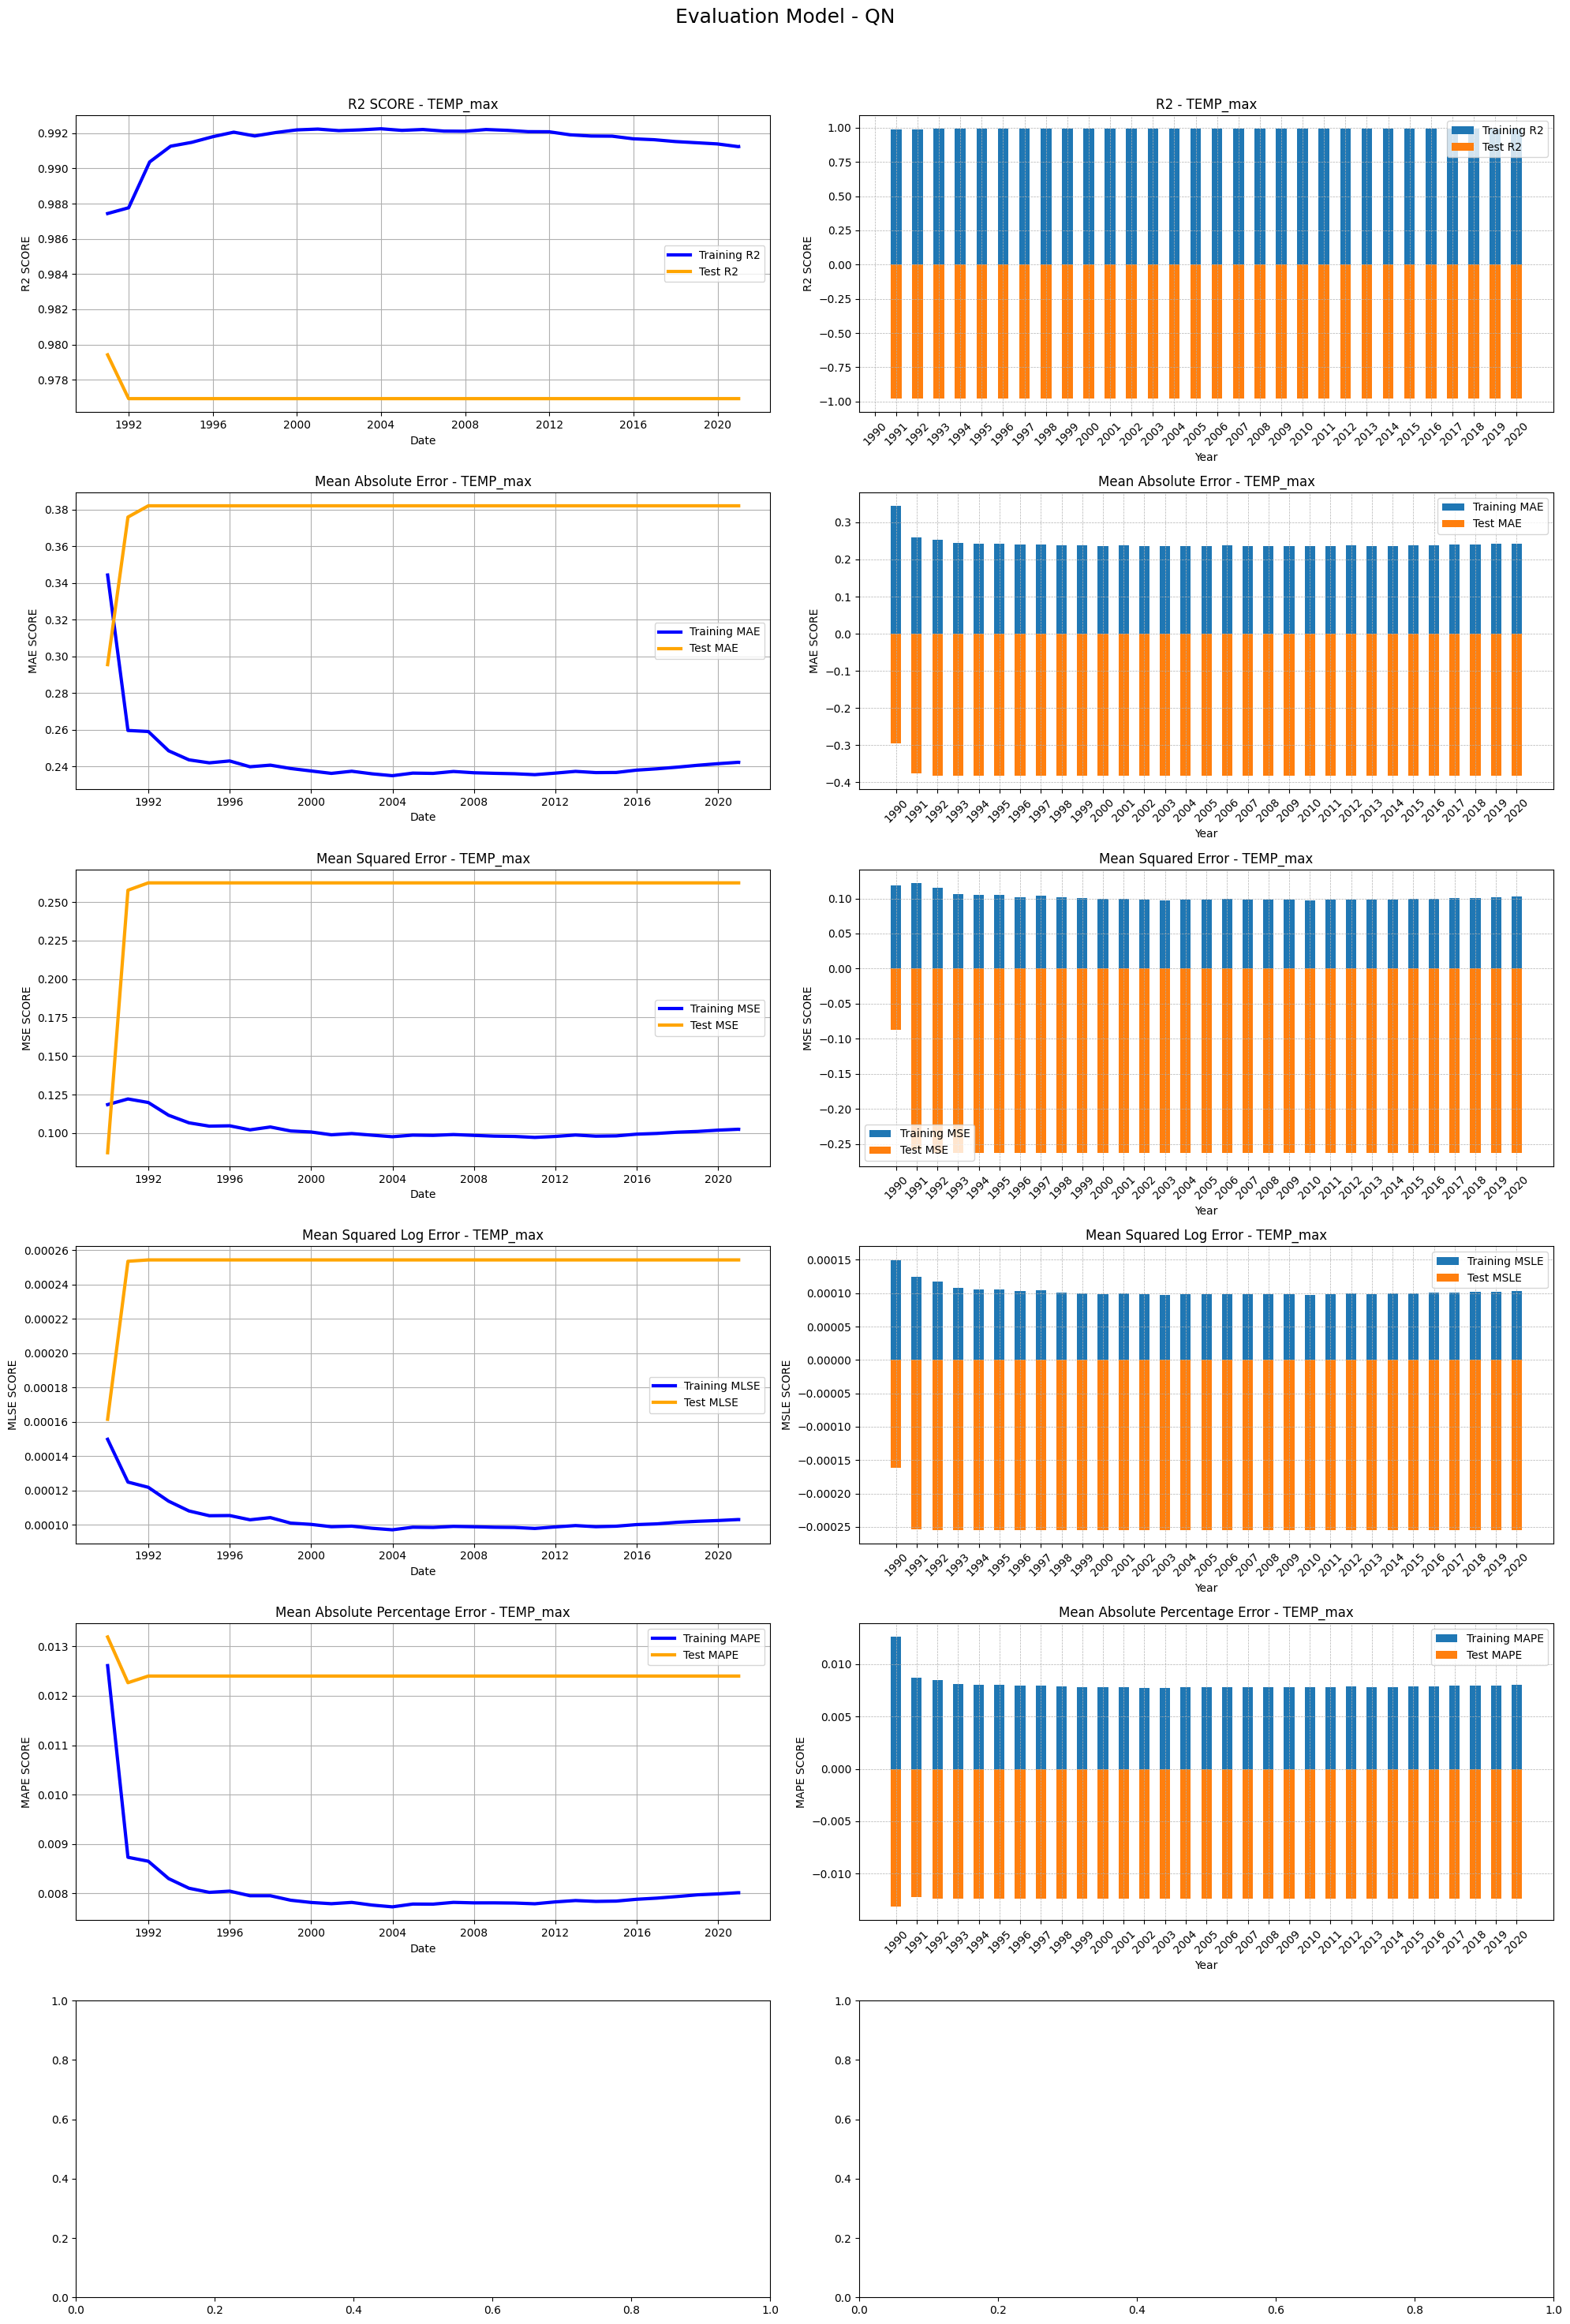

🔸 Trạm: TH


f:\NCKH\.venv\lib\site-packages\sklearn\metrics\_regression.py:1283: UndefinedMetricWarning: R^2 score is not well-defined with less than two samples.
  warnings.warn(msg, UndefinedMetricWarning)
f:\NCKH\.venv\lib\site-packages\sklearn\metrics\_regression.py:1283: UndefinedMetricWarning: R^2 score is not well-defined with less than two samples.
  warnings.warn(msg, UndefinedMetricWarning)
f:\NCKH\TSF_Github\Drafts\Temp Prediction\notebooks\3.1. ML_model\../..\scripts\evaluate_model.py:128: FutureWarning: 'Y' is deprecated and will be removed in a future version, please use 'YE' instead.
  years = idx_series.to_series().resample('Y').mean().interpolate().dt.year
f:\NCKH\TSF_Github\Drafts\Temp Prediction\notebooks\3.1. ML_model\../..\scripts\evaluate_model.py:129: FutureWarning: 'Y' is deprecated and will be removed in a future version, please use 'YE' instead.
  train_scores_yearly = pd.Series(train_scores, index=idx_series).resample('Y').mean().interpolate()
f:\NCKH\TSF_Github\Drafts\T

🔹 TEMP_max_TH (R2_train) : 0.9965190678620206
🔹 TEMP_max_TH (R2_test)  : 0.9934510557286849



f:\NCKH\TSF_Github\Drafts\Temp Prediction\notebooks\3.1. ML_model\../..\scripts\evaluate_model.py:229: FutureWarning: 'Y' is deprecated and will be removed in a future version, please use 'YE' instead.
  years = idx_series.to_series().resample('Y').mean().interpolate().dt.year
f:\NCKH\TSF_Github\Drafts\Temp Prediction\notebooks\3.1. ML_model\../..\scripts\evaluate_model.py:230: FutureWarning: 'Y' is deprecated and will be removed in a future version, please use 'YE' instead.
  train_scores_yearly = pd.Series(train_scores, index=idx_series).resample('Y').mean().interpolate()
f:\NCKH\TSF_Github\Drafts\Temp Prediction\notebooks\3.1. ML_model\../..\scripts\evaluate_model.py:231: FutureWarning: 'Y' is deprecated and will be removed in a future version, please use 'YE' instead.
  test_scores_yearly  = pd.Series(test_scores, index=idx_series).resample('Y').mean().interpolate()


🔹 TEMP_max_TH (MAE_train) : 0.2393277759816882
🔹 TEMP_max_TH (MAE_test)  : 0.3317233506501454



f:\NCKH\TSF_Github\Drafts\Temp Prediction\notebooks\3.1. ML_model\../..\scripts\evaluate_model.py:329: FutureWarning: 'Y' is deprecated and will be removed in a future version, please use 'YE' instead.
  years = idx_series.to_series().resample('Y').mean().interpolate().dt.year
f:\NCKH\TSF_Github\Drafts\Temp Prediction\notebooks\3.1. ML_model\../..\scripts\evaluate_model.py:330: FutureWarning: 'Y' is deprecated and will be removed in a future version, please use 'YE' instead.
  train_scores_yearly = pd.Series(train_scores, index=idx_series).resample('Y').mean().interpolate()
f:\NCKH\TSF_Github\Drafts\Temp Prediction\notebooks\3.1. ML_model\../..\scripts\evaluate_model.py:331: FutureWarning: 'Y' is deprecated and will be removed in a future version, please use 'YE' instead.
  test_scores_yearly  = pd.Series(test_scores, index=idx_series).resample('Y').mean().interpolate()


🔹 TEMP_max_TH (MSE_train) : 0.10198662161148239
🔹 TEMP_max_TH (MSE_test)  : 0.20233738359168474



f:\NCKH\TSF_Github\Drafts\Temp Prediction\notebooks\3.1. ML_model\../..\scripts\evaluate_model.py:429: FutureWarning: 'Y' is deprecated and will be removed in a future version, please use 'YE' instead.
  years = idx_series.to_series().resample('Y').mean().interpolate().dt.year
f:\NCKH\TSF_Github\Drafts\Temp Prediction\notebooks\3.1. ML_model\../..\scripts\evaluate_model.py:430: FutureWarning: 'Y' is deprecated and will be removed in a future version, please use 'YE' instead.
  train_scores_yearly = pd.Series(train_scores, index=idx_series).resample('Y').mean().interpolate()
f:\NCKH\TSF_Github\Drafts\Temp Prediction\notebooks\3.1. ML_model\../..\scripts\evaluate_model.py:431: FutureWarning: 'Y' is deprecated and will be removed in a future version, please use 'YE' instead.
  test_scores_yearly  = pd.Series(test_scores, index=idx_series).resample('Y').mean().interpolate()


🔹 TEMP_max_TH (MSLE_train) : 0.00015575791498670751
🔹 TEMP_max_TH (MSLE_test)  : 0.00024461278467671565

🔹 TEMP_max_TH (MAPE_train) : 0.009294290666711632
🔹 TEMP_max_TH (MAPE_test)  : 0.01202546008108939



f:\NCKH\TSF_Github\Drafts\Temp Prediction\notebooks\3.1. ML_model\../..\scripts\evaluate_model.py:528: FutureWarning: 'Y' is deprecated and will be removed in a future version, please use 'YE' instead.
  years = idx_series.to_series().resample('Y').mean().interpolate().dt.year
f:\NCKH\TSF_Github\Drafts\Temp Prediction\notebooks\3.1. ML_model\../..\scripts\evaluate_model.py:529: FutureWarning: 'Y' is deprecated and will be removed in a future version, please use 'YE' instead.
  train_scores_yearly = pd.Series(train_scores, index=idx_series).resample('Y').mean().interpolate()
f:\NCKH\TSF_Github\Drafts\Temp Prediction\notebooks\3.1. ML_model\../..\scripts\evaluate_model.py:530: FutureWarning: 'Y' is deprecated and will be removed in a future version, please use 'YE' instead.
  test_scores_yearly  = pd.Series(test_scores, index=idx_series).resample('Y').mean().interpolate()


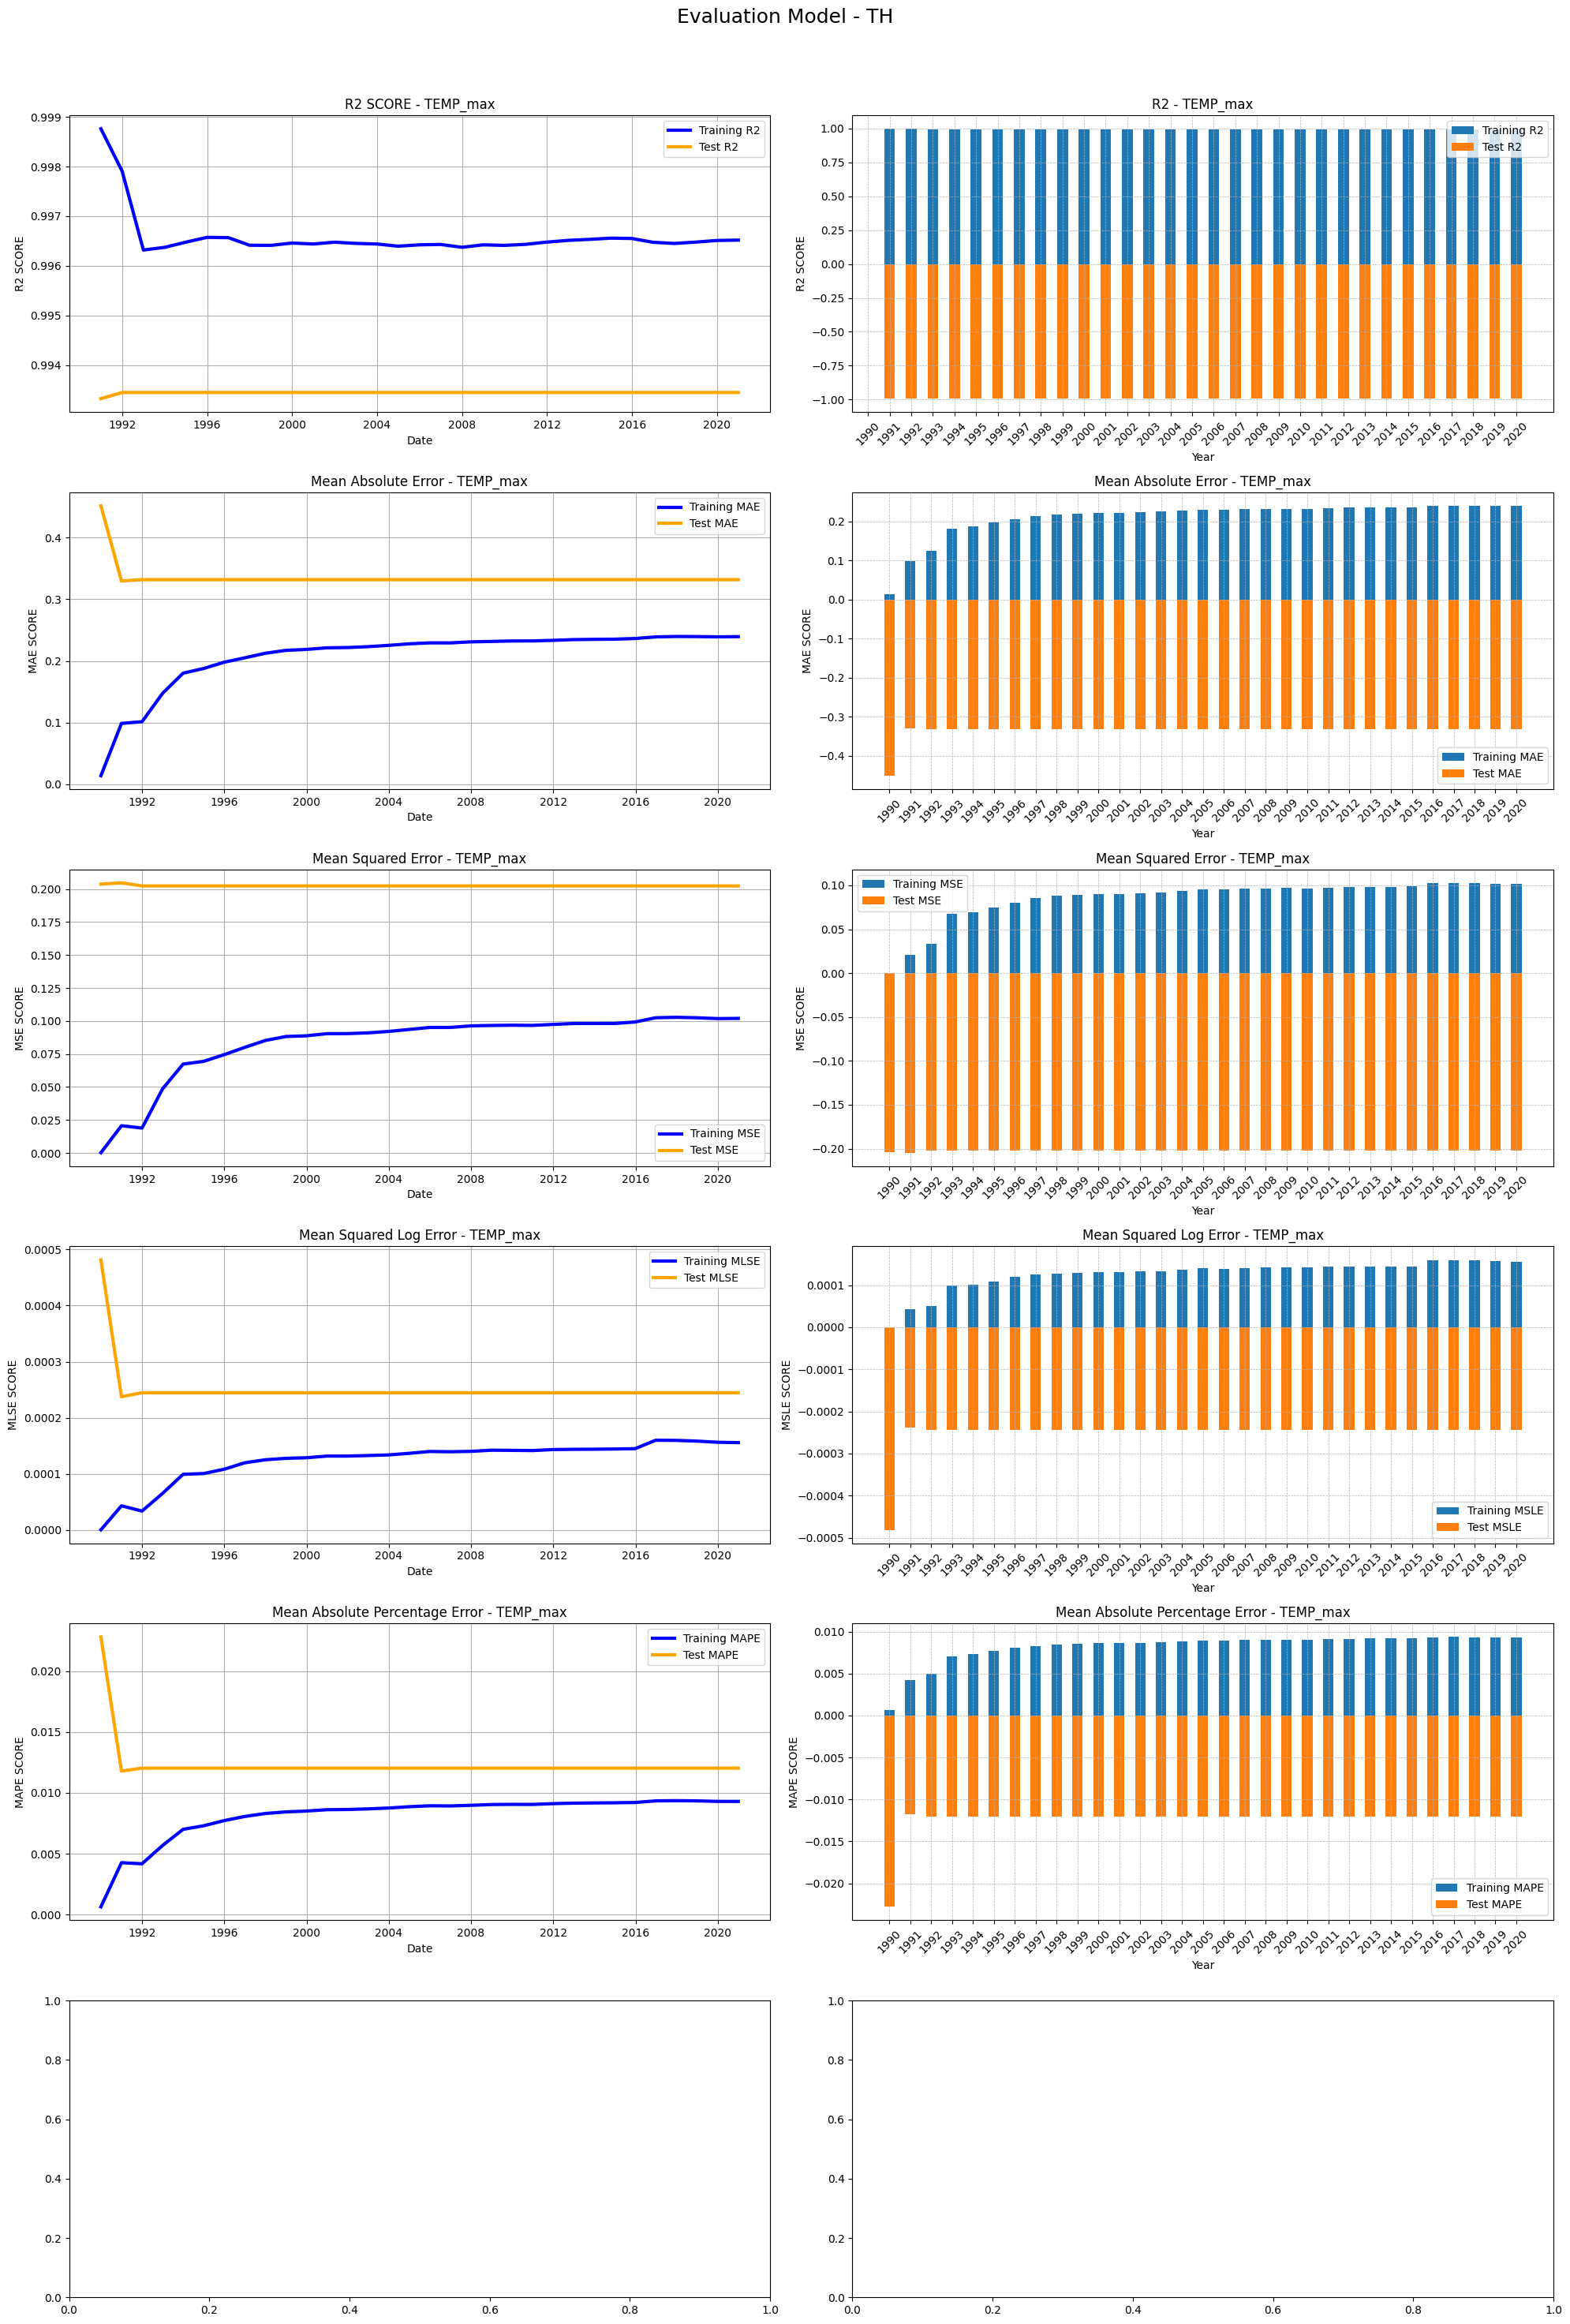

🔸 Trạm: TSN


f:\NCKH\.venv\lib\site-packages\sklearn\metrics\_regression.py:1283: UndefinedMetricWarning: R^2 score is not well-defined with less than two samples.
  warnings.warn(msg, UndefinedMetricWarning)
f:\NCKH\.venv\lib\site-packages\sklearn\metrics\_regression.py:1283: UndefinedMetricWarning: R^2 score is not well-defined with less than two samples.
  warnings.warn(msg, UndefinedMetricWarning)
f:\NCKH\TSF_Github\Drafts\Temp Prediction\notebooks\3.1. ML_model\../..\scripts\evaluate_model.py:128: FutureWarning: 'Y' is deprecated and will be removed in a future version, please use 'YE' instead.
  years = idx_series.to_series().resample('Y').mean().interpolate().dt.year
f:\NCKH\TSF_Github\Drafts\Temp Prediction\notebooks\3.1. ML_model\../..\scripts\evaluate_model.py:129: FutureWarning: 'Y' is deprecated and will be removed in a future version, please use 'YE' instead.
  train_scores_yearly = pd.Series(train_scores, index=idx_series).resample('Y').mean().interpolate()
f:\NCKH\TSF_Github\Drafts\T

🔹 TEMP_max_TSN (R2_train) : 0.9646341486763774
🔹 TEMP_max_TSN (R2_test)  : 0.9179242441395158

🔹 TEMP_max_TSN (MAE_train) : 0.27415673901838306
🔹 TEMP_max_TSN (MAE_test)  : 0.4338967418540193



f:\NCKH\TSF_Github\Drafts\Temp Prediction\notebooks\3.1. ML_model\../..\scripts\evaluate_model.py:229: FutureWarning: 'Y' is deprecated and will be removed in a future version, please use 'YE' instead.
  years = idx_series.to_series().resample('Y').mean().interpolate().dt.year
f:\NCKH\TSF_Github\Drafts\Temp Prediction\notebooks\3.1. ML_model\../..\scripts\evaluate_model.py:230: FutureWarning: 'Y' is deprecated and will be removed in a future version, please use 'YE' instead.
  train_scores_yearly = pd.Series(train_scores, index=idx_series).resample('Y').mean().interpolate()
f:\NCKH\TSF_Github\Drafts\Temp Prediction\notebooks\3.1. ML_model\../..\scripts\evaluate_model.py:231: FutureWarning: 'Y' is deprecated and will be removed in a future version, please use 'YE' instead.
  test_scores_yearly  = pd.Series(test_scores, index=idx_series).resample('Y').mean().interpolate()
f:\NCKH\TSF_Github\Drafts\Temp Prediction\notebooks\3.1. ML_model\../..\scripts\evaluate_model.py:329: FutureWarning:

🔹 TEMP_max_TSN (MSE_train) : 0.12930171540267132
🔹 TEMP_max_TSN (MSE_test)  : 0.3351725774807026

🔹 TEMP_max_TSN (MSLE_train) : 0.00011420848738340709
🔹 TEMP_max_TSN (MSLE_test)  : 0.0002738457672485012



f:\NCKH\TSF_Github\Drafts\Temp Prediction\notebooks\3.1. ML_model\../..\scripts\evaluate_model.py:429: FutureWarning: 'Y' is deprecated and will be removed in a future version, please use 'YE' instead.
  years = idx_series.to_series().resample('Y').mean().interpolate().dt.year
f:\NCKH\TSF_Github\Drafts\Temp Prediction\notebooks\3.1. ML_model\../..\scripts\evaluate_model.py:430: FutureWarning: 'Y' is deprecated and will be removed in a future version, please use 'YE' instead.
  train_scores_yearly = pd.Series(train_scores, index=idx_series).resample('Y').mean().interpolate()
f:\NCKH\TSF_Github\Drafts\Temp Prediction\notebooks\3.1. ML_model\../..\scripts\evaluate_model.py:431: FutureWarning: 'Y' is deprecated and will be removed in a future version, please use 'YE' instead.
  test_scores_yearly  = pd.Series(test_scores, index=idx_series).resample('Y').mean().interpolate()
f:\NCKH\TSF_Github\Drafts\Temp Prediction\notebooks\3.1. ML_model\../..\scripts\evaluate_model.py:528: FutureWarning:

🔹 TEMP_max_TSN (MAPE_train) : 0.008396349017875225
🔹 TEMP_max_TSN (MAPE_test)  : 0.012808691820164



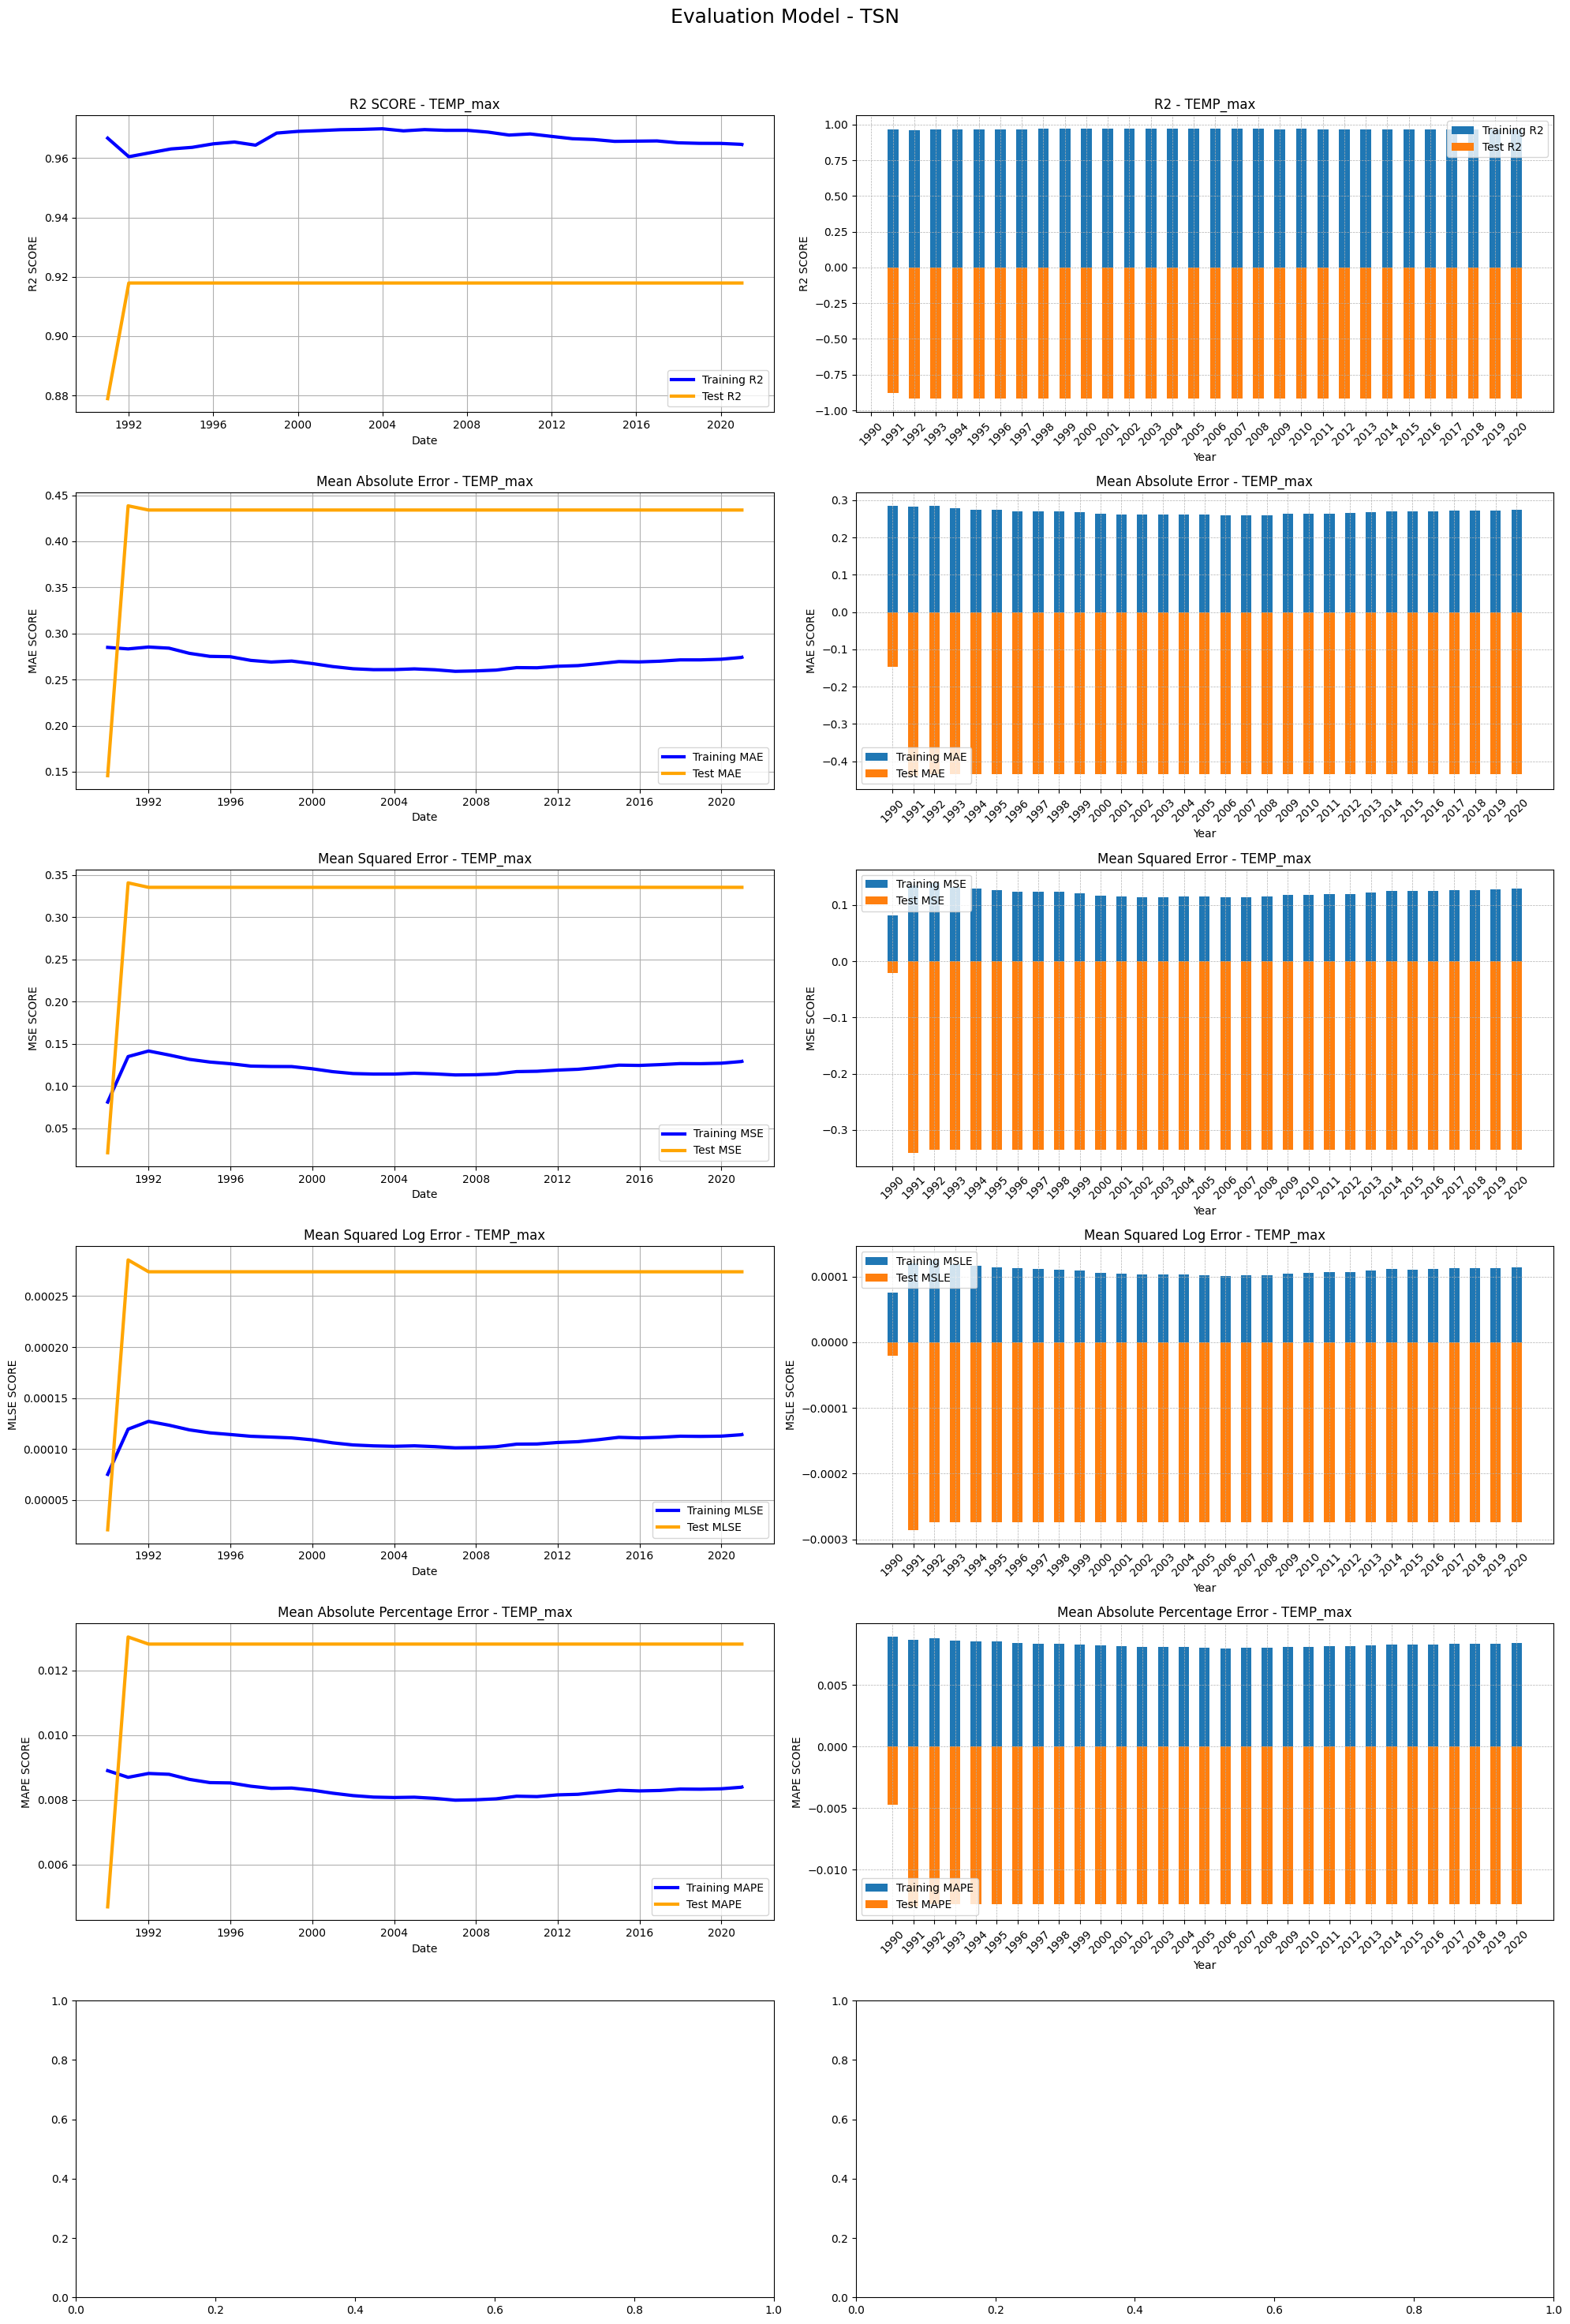

In [83]:
import importlib
importlib.reload(plots)
importlib.reload(evaluate_model)

# from joblib import Memory
for name in station.keys():
    plots.plot_evaluate_model_over_time(
                                        # data             = df.reset_index(), 
                                        target_cols_name = "TEMP_max", 
                                        station_name     = name, 
                                        y_true           = list([y_train_encoded.loc[y_train_encoded["NAME"] == src_name[name]]["TEMP_max"], 
                                                                 y_test_encoded.loc[y_test_encoded["NAME"] == src_name[name]]["TEMP_max"]]), 
                                        y_pred           = list([station_fit[name],
                                                                 station_pred[name]]),
                                        method           = "full",
                                        metrics          = list([
                                                                 "R2",   
                                                                 "MAE",
                                                                 "MSE",
                                                                 "MSLE",
                                                                 "MAPE"
                                                                 ]),
                                        display          = True,
                                        step_size        = 365,
                                        # start_time       = "1990-01-01 00:00:00+07:00",
                                        # end_time         = "2023-01-01 00:00:00+07:00",
                                        # freq             = "1H"
                                        )

##### <span style="color:tomato">Feature Importance</span>

<a href="https://www.youtube.com/watch?v=WbH-XZjCq8k">Find Most Important Features For Machine Learning in Python</a>

In [ ]:
reg_model.feature_importances_

Text(0.5, 1.0, 'Feature Importance')

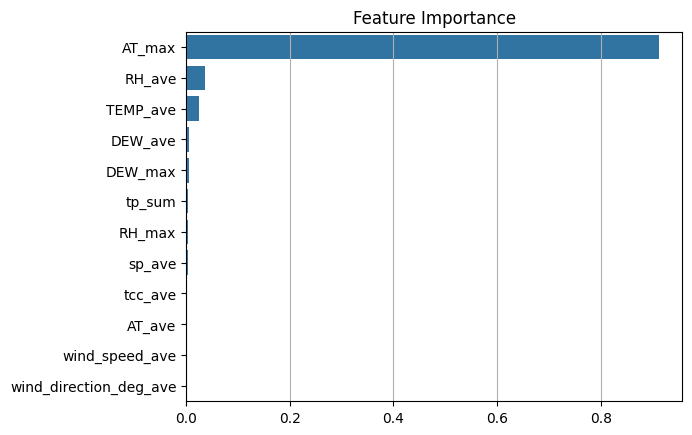

In [84]:
# num_cols = len(station_fit.keys())

# # Xác định số hàng và số cột hợp lý
# ncols = 3  # Số biểu đồ trên mỗi hàng
# nrows = int(np.ceil(num_cols / ncols))  # Tính số hàng cần thiết

# fig, ax = plt.subplots(ncols                = ncols, 
#                          nrows              = nrows, 
#                          figsize            = (5*ncols, 4*nrows),
#                          constrained_layout = True)  # auto căn chỉnh
# ax = ax.flatten()  # chuyển mảng 2 chiều thành 1 chiều để dễ duyệt

train_data = pd.concat([X_train_encoded,X_test_encoded],
                        axis=0)
# for i, name in enumerate(station.keys(), 0):
fi = dict({k: v for k,v in sorted(zip(train_data[feature_col],
                                      reg_model.feature_importances_),
                                  key     = lambda x : x[1],
                                  reverse = True
                                  )})
sns.barplot(fi, 
            orient = 'h')
plt.grid(True, axis='x')
plt.title(f"Feature Importance")

#### <span style="color:green">6.4. Interpretation of performance</span>

Technical

<a href="https://www.markovml.com/blog/lime-vs-shap#">LIME vs SHAP: A Comparative Analysis of Interpretability Tools</a>

<a href="https://www.youtube.com/watch?v=Vfnv1_bBqNg&t=570s">SHAP Values: An Overview
</a>

Code

<a href="https://www.youtube.com/watch?v=zyXapWWWGG4&list=WL&index=31">Explain Machine Learning Models with SHAP in Python</a>

<a href="https://www.youtube.com/watch?v=CV9FTCvQ32Q&list=WL&index=17">Data Visualization with Python: Lime and SHAP Libraries</a>

<a href="https://machinelearningmastery.com/a-gentle-introduction-to-shap-for-tree-based-models/">A Gentle Introduction to SHAP for Tree-Based Models</a>

<a href="https://apxml.com/posts/lime-vs-shap-difference-interpretability?ref=labelvisor.com">LIME vs SHAP: What's the Difference for Model Interpretability?</a>

<a href="https://www.datacamp.com/tutorial/explainable-ai-understanding-and-trusting-machine-learning-models">Explainable AI - Understanding and Trusting Machine Learning Models</a>

<a href="https://arxiv.org/html/2305.02012v3">A Perspective on Explainable Artificial Intelligence Methods: SHAP and LIME</a>

<a href="https://www.mdpi.com/2076-3417/15/13/7329">Explainable AI for Forensic Analysis: A Comparative Study of SHAP and LIME in Intrusion Detection Models</a>

##### <span style="color:tomato">SHAP <~> SHapley Additive exPlanations</span>

In [85]:
explainer = dict()
for name in station.keys():
    print(f"🔸 Trạm: {name}")
    explainer[name] = shap.KernelExplainer(model = lambda x: reg_model.predict(x),
                                           data  = shap.kmeans(X_train_encoded.loc[X_train_encoded["NAME"] == src_name[name]][feature_col],6))

🔸 Trạm: CaMau
🔸 Trạm: DH
🔸 Trạm: NB
🔸 Trạm: QN
🔸 Trạm: TH
🔸 Trạm: TSN


true_fit vs fit

In [ ]:
shap_values_fit = dict()
for name in station.keys():
    print(f"🔸 Trạm: {name}")
    shap_values_fit[name] = explainer[name].shap_values(X_train_encoded.loc[X_train_encoded["NAME"] == src_name[name]][feature_col])

In [ ]:
for name in station.keys():
    print(f"🔸 Trạm: {name}")
    plt.title(f"SHAP Summary Plot - {name}")
    shap.summary_plot(shap_values_fit[name], 
                      X_train_encoded.loc[X_train_encoded["NAME"] == src_name[name]][feature_col])

In [ ]:
# Tạo thư mục nếu chưa tồn tại
os.makedirs(os.path.dirname(model_path), exist_ok=True)

# Lưu model
joblib.dump(value    = shap_values_fit, 
            filename = f'{model_path.replace("trained_models","checkpoints") + "shap_values_fit.pkl"}',
            # compress = True
            )
print(f"Object đã được lưu tại: {model_path}")

true_pred vs pred

In [ ]:
shap_values_pred = dict()
for name in station.keys():
    print(f"🔸 Trạm: {name}")
    shap_values_pred[name] = explainer[name].shap_values(X_test_encoded.loc[X_test_encoded["NAME"] == src_name[name]][feature_col])

In [ ]:
for name in station.keys():
    print(f"🔸 Trạm: {name}")
    plt.title(f"SHAP Summary Plot - {name}")
    shap.summary_plot(shap_values_pred[name], 
                      X_test_encoded.loc[X_test_encoded["NAME"] == src_name[name]][feature_col])

In [ ]:
# Tạo thư mục nếu chưa tồn tại
os.makedirs(os.path.dirname(model_path), exist_ok=True)

# Lưu model
joblib.dump(value    = shap_values_pred, 
            filename = f'{model_path.replace("trained_models","checkpoints") + "shap_values_pred.pkl"}',
            # compress = True
            )
print(f"Object đã được lưu tại: {model_path}")

testing

In [ ]:
scaler           = joblib.load(model_path.replace("trained_models","checkpoints") + "scaler.pkl")
shap_values_fit  = joblib.load(model_path.replace("trained_models","checkpoints") + "shap_values_fit.pkl")
shap_values_pred = joblib.load(model_path.replace("trained_models","checkpoints") + "shap_values_pred.pkl")

In [ ]:
def plot_shap_explaination(x_train_test, y_train_test, feature_col, shap_values, scaler, explainer, station, station_fit):
    for name in station.keys():
        # PLOT 1
        print(f"🔸 Trạm: {name}")
        sample_idx = random.randint(0,len(x_train_test.loc[x_train_test["NAME"] == src_name[name]]))
        x_data     = x_train_test.loc[x_train_test["NAME"] == src_name[name]].iloc[[sample_idx]]
        x          = scaler.inverse_transform(x_data[feature_col])
        y_data     = y_train_test.loc[y_train_test["NAME"] == src_name[name]].iloc[[sample_idx]]
        y          = y_data["TEMP_max"][0]

        # Select an interesting prediction to explain
        sample_prediction = station_fit[name].iloc[sample_idx][0]
        actual_value      = y

        print(f"Analyzing prediction for {name} index {x_data.index[0]}:")
        print(f"Predicted values  : {sample_prediction:,.2f}°C")
        print(f"Actual values     : {actual_value:,.2f}°C")
        print(f"Prediction error  : {abs(sample_prediction - actual_value):,.2f}°C")

        # Create SHAP waterfall plot
        plt.figure(figsize=(15, 6))
        shap.waterfall_plot(
            shap.Explanation(
                values        = shap_values[name][sample_idx], 
                base_values   = explainer[name].expected_value, 
                data          = x[0],
                feature_names = x_data[feature_col].columns.tolist()
            ),
            max_display = 15,  # Show top 15 contributing features
            show        = False
        )
        plt.title(f'How Our Model Predicts {sample_prediction:,.0f}°C for {name} index {x_data.index[0]}', 
                  fontsize   = 14, 
                  fontweight = 'bold', 
                  pad        = 20)
        plt.tight_layout()
        plt.show()

        # PLOT 2
        # Analyze the feature contributions for our sample house
        feature_values = x[0]
        shap_contributions = shap_values[name][sample_idx]

        # Create a detailed breakdown of contributions
        feature_breakdown = pd.DataFrame({
            'Feature'           : x_data[feature_col].columns,
            'Feature_Value'     : feature_values,
            'SHAP_Contribution' : shap_contributions,
            'Impact'            : ['Increases Price' if x > 0 else 'Decreases Price' for x in shap_contributions]
        }).sort_values('SHAP_Contribution', key=abs, ascending=False)

        print(f"Top {len(feature_breakdown)} Feature Contributions to This Prediction:")
        print("=" * 60)
        for idx, row in feature_breakdown.iterrows():
            impact_symbol = "↑" if row['SHAP_Contribution'] > 0 else "↓"
            print(f"{row['Feature']:23} {impact_symbol} {row['SHAP_Contribution']:8,.2f}°C "
                  f"(Value: {row['Feature_Value']:.2f})")

        print(f"\nBase prediction    : {explainer[name].expected_value:,.2f}°C")
        print(f"Sum of contributions : {shap_contributions.sum():+,.2f}°C")
        print(f"Final prediction     : {explainer[name].expected_value + shap_contributions.sum():,.2f}°C")
        print()
        
        
plot_shap_explaination(x_train_test = X_train_encoded,
                       y_train_test = y_train_encoded,
                       feature_col  = feature_col,
                       station      = {"CaMau": 1},
                       station_fit  = station_fit,
                       shap_values  = shap_values_fit,
                       explainer    = explainer,
                       scaler       = scaler)

### Vì sao KernelExplainer cho kết quả khác với `model.predict`

Khi sử dụng **`KernelExplainer`** của SHAP với mô hình như **RandomForestRegressor**, kết quả giải thích có thể **lệch** so với giá trị thực tế mà `model.predict` trả về. Nguyên nhân chính bao gồm:

1. **Bản chất xấp xỉ (approximation) của Kernel SHAP**  
   - Kernel SHAP là một phương pháp "mô phỏng" giá trị Shapley bằng cách sinh ra các mẫu dữ liệu giả (coalitions) rồi huấn luyện một mô hình tuyến tính xấp xỉ để tính độ quan trọng đặc trưng.  
   - Do dùng sampling + approximation nên kết quả giải thích thường không khớp tuyệt đối với `model.predict`, mà chỉ gần đúng.

2. **Tính chất ngẫu nhiên (randomness) trong quá trình lấy mẫu**  
   - Kernel SHAP không duyệt toàn bộ không gian tập con đặc trưng (2^n subsets) mà chỉ chọn một số lượng hữu hạn mẫu.  
   - Nếu số lượng mẫu ít, sai số xấp xỉ càng lớn, dẫn đến lệch nhiều so với `model.predict`.

3. **Khác biệt giữa expectation baseline và output thực tế**  
   - SHAP tính toán giá trị dựa trên **chênh lệch so với kỳ vọng của mô hình** (expected value), không phải trực tiếp bằng output raw của mô hình.  
   - Do đó, tổng (expected value + tổng SHAP values) có thể hơi lệch với `model.predict` do sai số tính toán.

4. **Mô hình phi tuyến (RandomForest, XGBoost, Neural Net, …)**  
   - Với các mô hình phi tuyến mạnh, việc xấp xỉ bằng một mô hình tuyến tính cục bộ như Kernel SHAP sẽ khó chính xác tuyệt đối, nên kết quả giải thích khác so với dự đoán thực tế.

👉 Tóm lại:  
KernelExplainer không đảm bảo **giải thích khớp 100%** với `model.predict`, vì nó là phương pháp **xấp xỉ dựa trên sampling và baseline expectation**. Để giảm sai số, cần:
- Tăng số lượng mẫu (`nsamples`).
- Sử dụng explainer chuyên biệt (ví dụ `TreeExplainer` cho RandomForest, XGBoost).


##### <span style="color:tomato">LIME</span>

<a href="https://www.youtube.com/watch?v=ZMB6TwQ6Vuo&list=WL&index=32">Machine Learning Model Explainability with LIME in Python</a>

### <span style="color:orange">7. Conclusion</span>